# mCREAM Graph Module Ensemble Analysis

Architecture: M Concept-Concept blocks (one per expert graph), shared backbone/side-channel/task-head.
Aggregation at **concept level** `c = mean(c_0..c_M)`, not prediction level.

## Three experiment types:
1. **Noisy DAGs** â€” same action/level, different random seeds per expert
2. **Single-edge perturbation** â€” each expert missing/adding exactly 1 edge
3. **Mixed noise levels** â€” experts from low/medium/high, Î» can learn


In [1]:
import pandas as pd, numpy as np, ast, torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ACTION_COLOR  = {'deletion':'#e74c3c','addition':'#2ecc71','reversal':'#3498db'}
LEVEL_ALPHA   = {'low':0.45,'medium':0.70,'high':1.0}
LEVEL_COLOR   = {'low':'#3498db','medium':'#e67e22','high':'#e74c3c'}

EXPERIMENTS_ROOT = Path('/home/dani00003/mCREAM/experiments')
GRAPHS_ROOT      = Path('/home/dani00003/mCREAM/data/FashionMNIST')
DAG_CFMNIST      = GRAPHS_ROOT / 'Complete_Concept_FMNIST_DAG.csv'

# â”€â”€ Dataset registry â€” add CUB here once data is ready â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
DATASET_CONFIG = {
    'Complete_Concept_FMNIST': {
        'dag':         DAG_CFMNIST,
        'num_concepts': 11,
        'graphs_root':  GRAPHS_ROOT,
    },
    'CelebA': {
        'dag':         Path('/home/dani00003/mCREAM/data/CelebA/final_DAG_unfair.csv'),
        'num_concepts': 7,
        'graphs_root':  Path('/home/dani00003/mCREAM/data/CelebA'),
    },
    'CUB': {
        'dag':         Path('/home/dani00003/mCREAM/data/CUB/CUB_DAG_only_Gc.csv'),
        'num_concepts': 112,
        'graphs_root':  Path('/home/dani00003/mCREAM/data/CUB'),
    },
}

DATASETS = ['Complete_Concept_FMNIST', 'CelebA']
ACTIONS  = ['deletion','addition','reversal']
LEVELS   = ['low','medium','high']
N_EXPERTS = 5

# â”€â”€ Shared helpers â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def load_gt_cream(root):
    rows=[]
    for ds,model,exp in [('Complete_Concept_FMNIST','Standard_FashionMNIST','CREAM_best_cfmnist')]:
        md=root/ds/'train_cbm'/model/exp/'last_metrics'
        if not md.exists(): continue
        for f in sorted(md.glob('*.csv')):
            df=pd.read_csv(f); df['dataset']=ds; rows.append(df)
    gt=pd.concat(rows,ignore_index=True) if rows else pd.DataFrame()
    if len(gt)>0:
        r=gt.iloc[0]
        print(f'GT CREAM: acc={r.get("test_task_accuracy",float("nan")):.4f}  '
              f'concept={r.get("test_concept_accuracy",float("nan")):.4f}  '
              f'CCI={r.get("CCI","N/A")}  '
              f'PFI_c={r.get("PFI_concept_importance","N/A")}  '
              f'PFI_s={r.get("PFI_side_importance","N/A")}')
    return gt

def load_interventions(root, exp_name_filter=None, datasets=None):
    rows=[]
    search_ds = datasets or DATASETS
    for ds in search_ds:
        ens_dir=root/ds/'train_cbm'/'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for csv_f in ens_dir.rglob('intervention_results.csv'):
            try:
                df=pd.read_csv(csv_f)
                parts=csv_f.parts
                exp_name=seed=None
                for i,p in enumerate(parts):
                    if p=='mCREAM_GraphEnsemble' and i+1<len(parts): exp_name=parts[i+1]
                    if p.startswith('seed_'): seed=int(p.split('_')[1])
                if exp_name is None: continue
                if exp_name_filter and not any(f in exp_name for f in exp_name_filter): continue
                df['dataset']=ds; df['exp_name']=exp_name; df['seed']=seed
                rows.append(df)
            except: pass
    return pd.concat(rows,ignore_index=True) if rows else pd.DataFrame()

def show_expert_dags(dirs_and_indices, title, K=11, dag_path=None):
    """Show expert graphs. dag_path overrides default cfmnist GT."""
    gt_path = dag_path or DAG_CFMNIST
    gt_df = pd.read_csv(gt_path, index_col=0)
    gt_vals = (gt_df.values!=0).astype(int)
    gt_u2c  = gt_vals[:K, :K]

    M=len(dirs_and_indices)
    fig,axes=plt.subplots(1,M+1,figsize=(2.5*(M+1),3))
    fig.suptitle(title,fontsize=10,fontweight='bold')

    def make_rgb(p):
        rgb=np.zeros((*p.shape,3))
        for r in range(p.shape[0]):
            for c in range(p.shape[1]):
                if   gt_u2c[r,c]==1 and p[r,c]==1: rgb[r,c]=[0.2,0.4,0.8]
                elif gt_u2c[r,c]==0 and p[r,c]==1: rgb[r,c]=[0.2,0.8,0.2]
                elif gt_u2c[r,c]==1 and p[r,c]==0: rgb[r,c]=[0.9,0.2,0.2]
                else: rgb[r,c]=[0.93,0.93,0.93]
        return rgb

    gt_rgb=np.zeros((*gt_u2c.shape,3))
    for r in range(K):
        for c in range(K):
            gt_rgb[r,c]=[0.2,0.4,0.8] if gt_u2c[r,c]==1 else [0.93,0.93,0.93]
    axes[0].imshow(gt_rgb,aspect='auto',interpolation='nearest')
    axes[0].set_title('GT',fontweight='bold',fontsize=8)
    for sp in axes[0].spines.values(): sp.set_edgecolor('gold'); sp.set_linewidth(3)
    axes[0].set_xticks([]); axes[0].set_yticks([])

    for m,(graph_dir,idx,label) in enumerate(dirs_and_indices):
        f=Path(graph_dir)/'u2c'/f'expert_{idx}.pt'
        ax=axes[m+1]
        if not f.exists(): ax.text(0.5,0.5,'N/A',ha='center',va='center',transform=ax.transAxes,fontsize=8); ax.axis('off'); continue
        p=torch.load(f,weights_only=True).float().numpy()
        # clip to KÃ—K in case graph is larger
        p=p[:K,:K]
        ax.imshow(make_rgb(p),aspect='auto',interpolation='nearest')
        ax.set_title(label,fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])

    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(facecolor=[0.2,0.4,0.8],label='kept'),
                         Patch(facecolor=[0.9,0.2,0.2],label='deleted'),
                         Patch(facecolor=[0.2,0.8,0.2],label='added')],
               loc='lower center',ncol=3,fontsize=7,bbox_to_anchor=(0.5,-0.05))
    plt.tight_layout(rect=[0,0.05,1,1])
    plt.show()

gt_df = load_gt_cream(EXPERIMENTS_ROOT)
print(f'Root exists: {EXPERIMENTS_ROOT.exists()}')

Root exists: True


---
# Experiment 1 â€” Noisy DAGs (same level, different seeds)

M=5 experts, each with same noise type+level but different random seed â†’ different specific edges.

## Two intervention modes (shown separately below)

**Individual concept interventions** (`group_interventions=False`):
- Replace one concept at a time, randomly chosen
- x-axis goes 0 â†’ 11 (one per concept)
- Answers: *how much does each extra concept fix help?*

**Group interventions** (`group_interventions=True`):
- Replace all concepts in one mutex group at once (cfmnist has 3 groups)
- x-axis goes 0 â†’ 3 (one per mutex group)
- One step = revealing a full mutually-exclusive set (e.g. all Season concepts together)
- Answers: *how much does fixing a whole semantic group help?*
- Steeper curve = model relies more on that semantic group for prediction

In [2]:
def load_noisy_dag_results(root):
    rows=[]
    for ds in DATASETS:
        ens_dir=root/ds/'train_cbm'/'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for exp_dir in sorted(ens_dir.iterdir()):
            if not exp_dir.is_dir(): continue
            name=exp_dir.name
            if not name.startswith('graph_ensemble_') or 'mixed' in name or 'gensemble' in name: continue
            p=name.split('_')
            try: action=p[2]; level=p[3]
            except: continue
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed=int(seed_dir.parent.parent.name.split('_')[1])
                for csv_f in sorted(seed_dir.glob('*.csv')):
                    if any(x in csv_f.name for x in ['perc_','_set_','intervention','exogenous']): continue
                    try:
                        df=pd.read_csv(csv_f)
                        df['dataset']=ds;df['action']=action;df['noise_level']=level;df['seed']=seed
                        rows.append(df)
                    except: pass
    if not rows: print('No noisy DAG results'); return pd.DataFrame()
    df=pd.concat(rows,ignore_index=True)
    print(f'Exp1 loaded: {len(df)} rows | actions={sorted(df.action.unique())} | levels={sorted(df.noise_level.unique())}')
    return df

exp1_df    = load_noisy_dag_results(EXPERIMENTS_ROOT)
exp1_interv= load_interventions(EXPERIMENTS_ROOT, exp_name_filter=['graph_ensemble_deletion','graph_ensemble_addition','graph_ensemble_reversal'])


Exp1 loaded: 180 rows | actions=['consensus'] | levels=['high', 'low', 'medium']


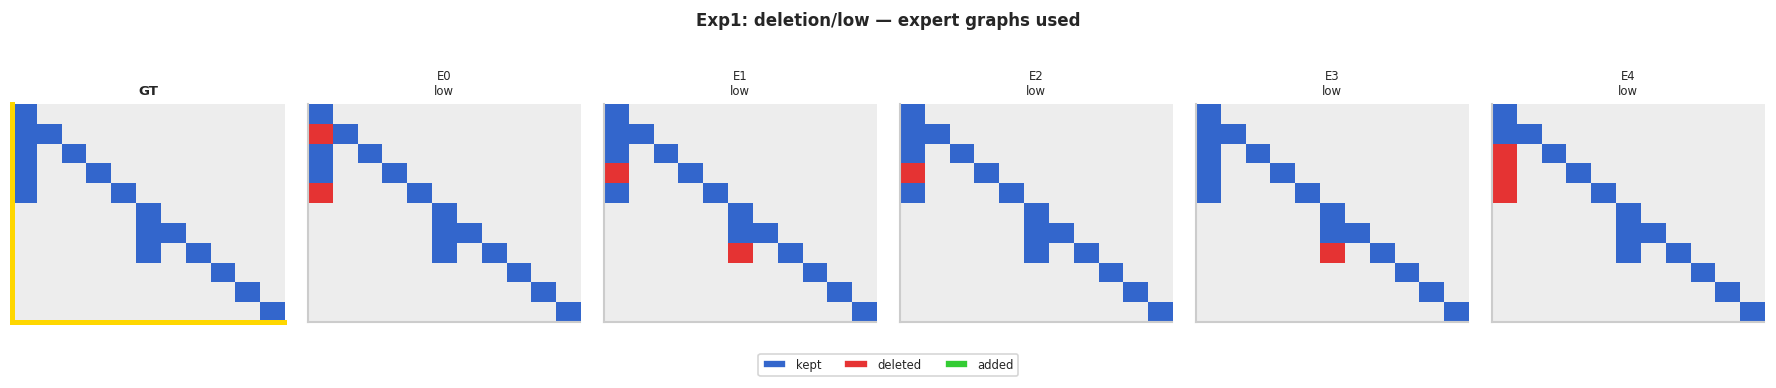

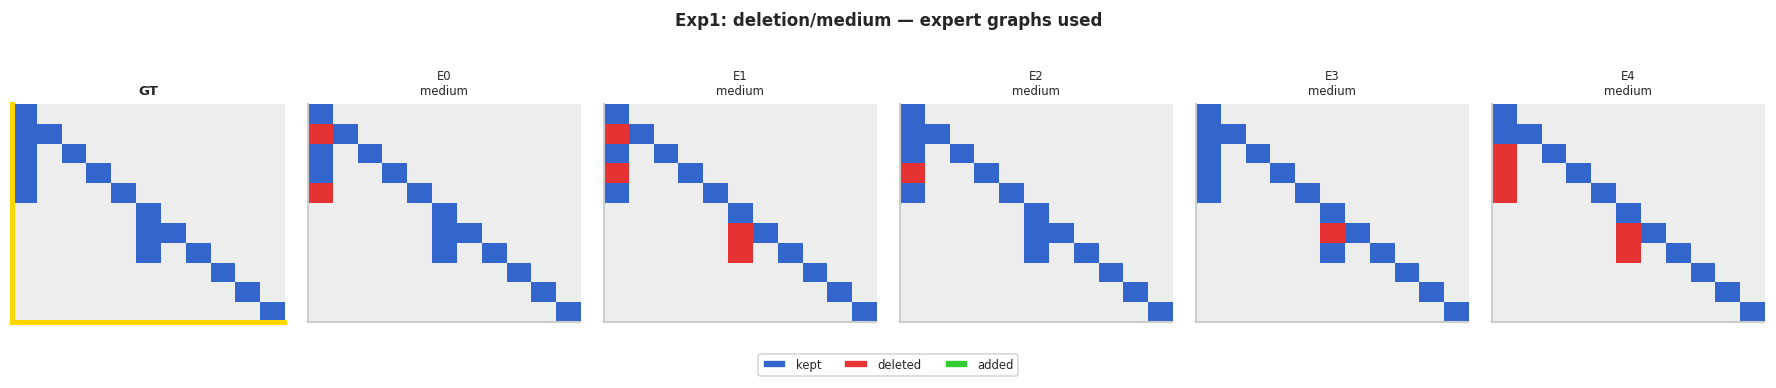

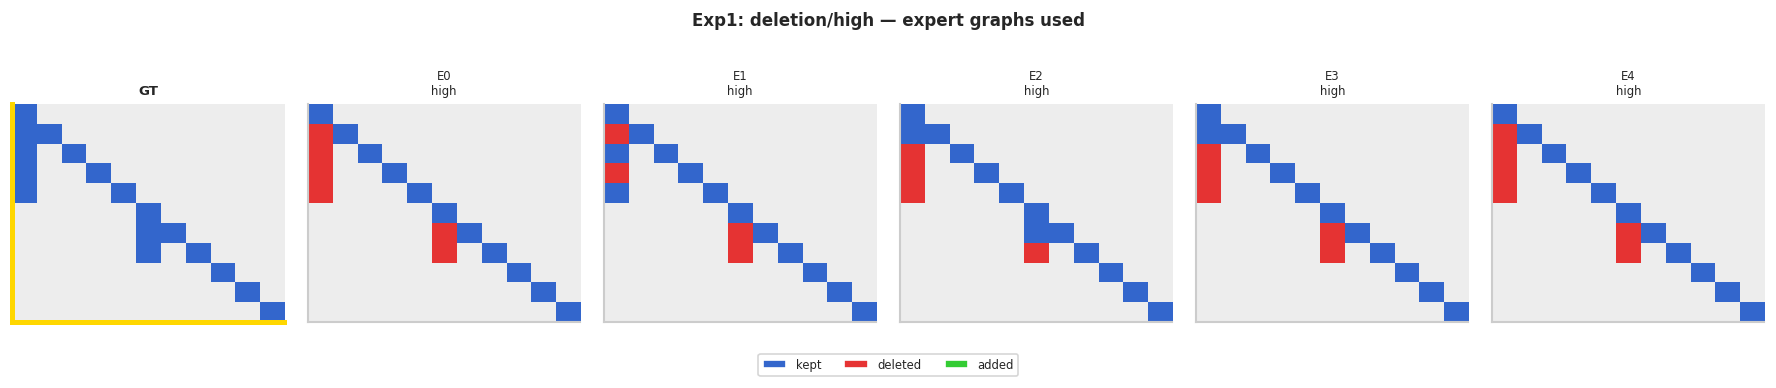

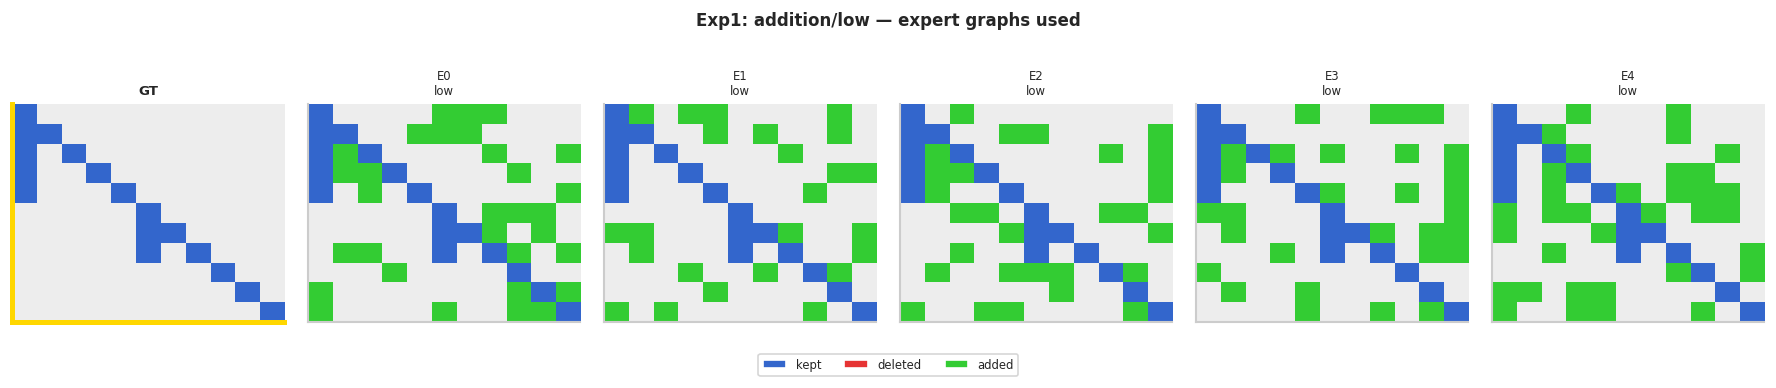

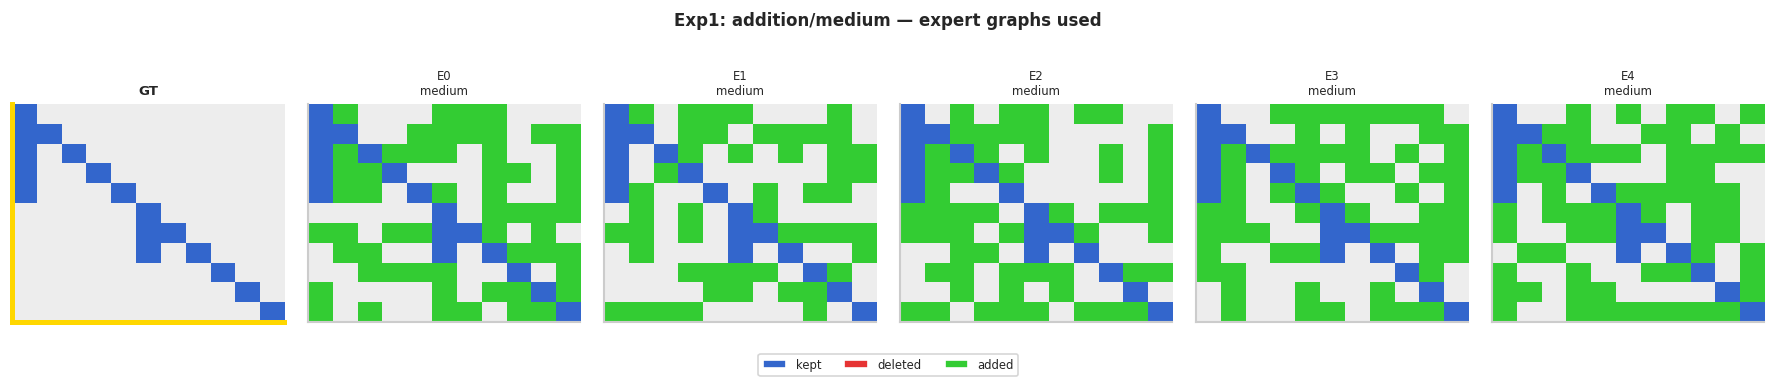

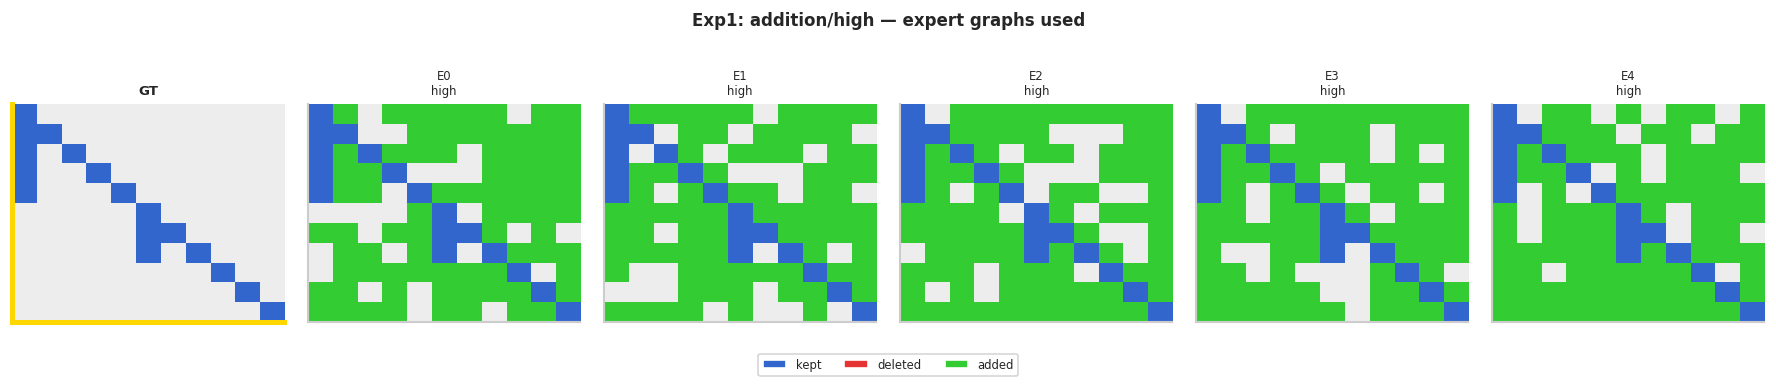

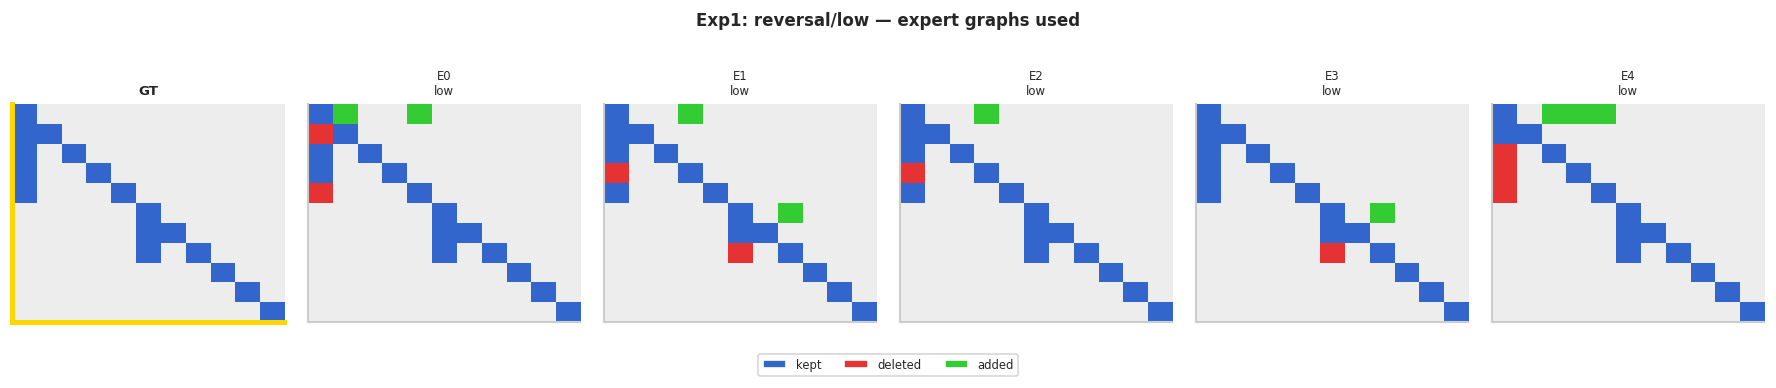

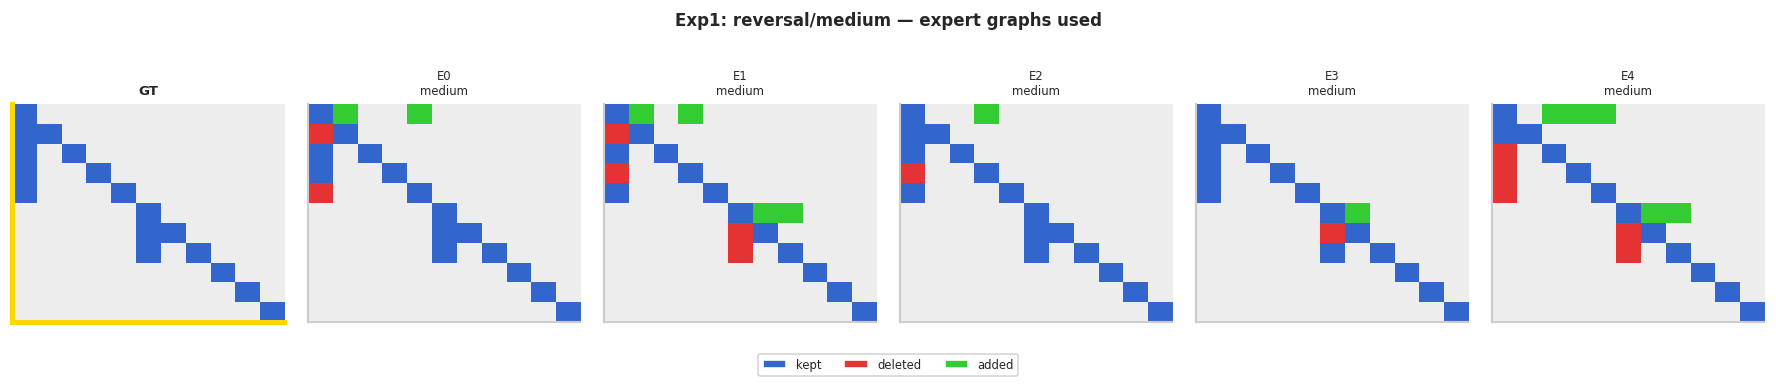

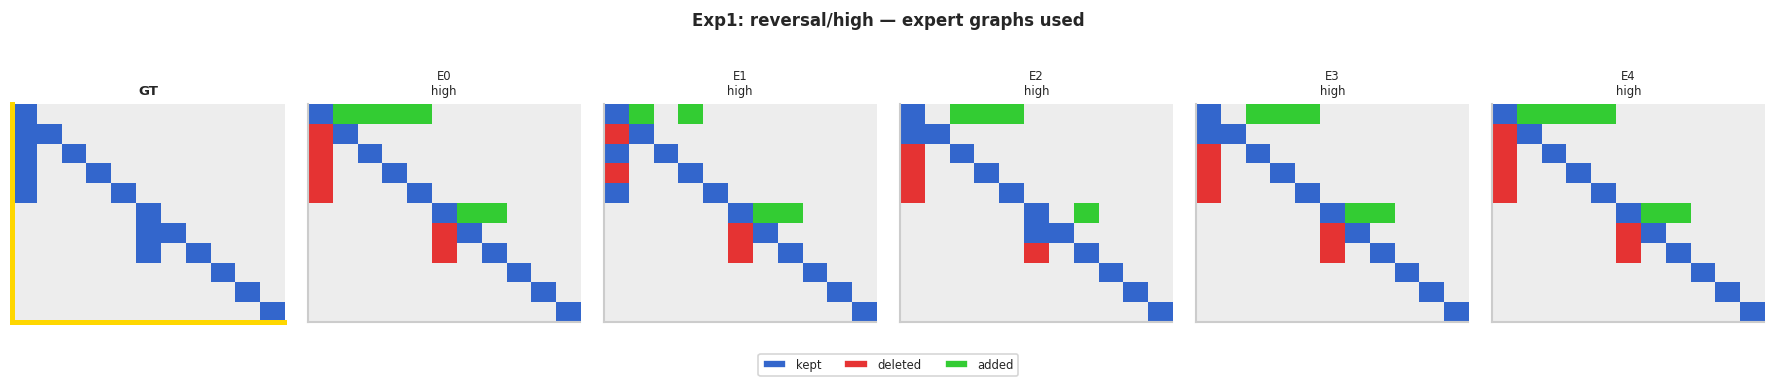

In [4]:
# Show expert graphs for each action/level
graphs_base = GRAPHS_ROOT / 'expert_graphs' / 'ensemble'
for action in ACTIONS:
    for level in LEVELS:
        d = graphs_base / f'{action}_{level}'
        if not d.exists(): continue
        dirs_and_indices = [(d, m, f'E{m}\n{level}') for m in range(N_EXPERTS)]
        show_expert_dags(dirs_and_indices, f'Exp1: {action}/{level} â€” expert graphs used')


In [ ]:
if len(exp1_df)==0: print('No Exp1 data')
else:
    lnum={'low':0.25,'medium':0.50,'high':0.75}
    KEY=['test_task_accuracy','test_concept_accuracy','CCI','PFI_concept_importance','PFI_side_importance']
    av=[c for c in KEY if c in exp1_df.columns]
    means=exp1_df.groupby(['action','noise_level'])[av].mean()
    stds =exp1_df.groupby(['action','noise_level'])[av].std()
    sm=pd.DataFrame(index=means.index)
    for c in av: sm[c]=means[c].map('{:.4f}'.format)+' +/- '+stds[c].map('{:.4f}'.format)
    if len(gt_df)>0:
        print('GT CREAM baseline:')
        for c in av:
            if c in gt_df.columns: print(f'  {c:30s} {gt_df[c].mean():.4f}')
    print('\n--- Experiment 1: Noisy DAGs ---')
    display(sm)

    # Accuracy vs noise level
    fig,axes=plt.subplots(1,2,figsize=(12,4.5))
    fig.suptitle('Exp1: Noisy DAGs â€” accuracy vs noise level',fontsize=12,fontweight='bold')
    for ax,metric,ylabel in [(axes[0],'test_task_accuracy','Task Accuracy'),(axes[1],'test_concept_accuracy','Concept Accuracy')]:
        if metric not in exp1_df.columns: continue
        d=exp1_df.copy(); d['noise_prob']=d['noise_level'].map(lnum)
        agg=d.groupby(['action','noise_prob'])[metric].agg(['mean','std']).reset_index()
        for action in ACTIONS:
            sub=agg[agg['action']==action]
            if sub.empty: continue
            col=ACTION_COLOR[action]
            ax.plot(sub['noise_prob'],sub['mean'],color=col,marker='o',markersize=8,lw=2,label=action)
            ax.fill_between(sub['noise_prob'],sub['mean']-sub['std'],sub['mean']+sub['std'],alpha=0.12,color=col)
        if len(gt_df)>0 and metric in gt_df.columns:
            v=gt_df[metric].mean()
            ax.axhline(v,color='black',lw=2,ls='--',label=f'GT CREAM: {v:.4f}')
        ax.set_xlabel('Noise probability'); ax.set_ylabel(ylabel)
        ax.set_xticks([0.25,0.50,0.75]); ax.set_xticklabels(['low','medium','high'])
        ax.legend(title='Noise type',fontsize=8)
    plt.tight_layout(); plt.savefig('exp1_accuracy.png',dpi=150,bbox_inches='tight'); plt.show()

    # â”€â”€ Intervention curves: TWO plots side by side per action â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    if len(exp1_interv)>0:
        for action in ACTIONS:
            sub_all = exp1_interv[exp1_interv['exp_name'].str.contains(action)]
            if sub_all.empty: continue

            # Split into individual and group
            has_group_col = 'group_interventions' in sub_all.columns
            sub_indiv = sub_all[sub_all['group_interventions']==False] if has_group_col else sub_all
            sub_group = sub_all[sub_all['group_interventions']==True]  if has_group_col else pd.DataFrame()

            fig, axes = plt.subplots(2, len(LEVELS), figsize=(5*len(LEVELS), 9), sharey='row')
            fig.suptitle(
                f'Exp1: {action} â€” Intervention curves\n'
                f'TOP: individual concept (0â†’11)   BOTTOM: group/mutex (0â†’3)',
                fontsize=11, fontweight='bold'
            )

            for col_idx, level in enumerate(LEVELS):
                # â”€â”€ TOP ROW: individual interventions â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
                ax_top = axes[0][col_idx]
                lv = sub_indiv[sub_indiv['exp_name'].str.contains(level)]
                if not lv.empty:
                    agg = lv.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                    ax_top.plot(agg['num_interventions'], agg['mean'],
                                color=ACTION_COLOR[action], lw=2.5, marker='o', markersize=5)
                    ax_top.fill_between(agg['num_interventions'],
                                        agg['mean']-agg['std'], agg['mean']+agg['std'],
                                        alpha=0.15, color=ACTION_COLOR[action])
                ax_top.set_title(f'{level} â€” individual', fontsize=10)
                ax_top.set_xlabel('Concepts replaced (0â†’11)')
                ax_top.set_ylabel('Task Accuracy' if col_idx==0 else '')
                ax_top.tick_params(labelsize=8)

                # â”€â”€ BOTTOM ROW: group interventions â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
                ax_bot = axes[1][col_idx]
                lv_g = sub_group[sub_group['exp_name'].str.contains(level)]
                if not lv_g.empty:
                    agg_g = lv_g.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                    ax_bot.plot(agg_g['num_interventions'], agg_g['mean'],
                                color=ACTION_COLOR[action], lw=2.5, marker='s', markersize=6,
                                ls='--')
                    ax_bot.fill_between(agg_g['num_interventions'],
                                        agg_g['mean']-agg_g['std'], agg_g['mean']+agg_g['std'],
                                        alpha=0.15, color=ACTION_COLOR[action])
                ax_bot.set_title(f'{level} â€” group (mutex)', fontsize=10)
                ax_bot.set_xlabel('Mutex groups replaced (0â†’3)')
                ax_bot.set_ylabel('Task Accuracy' if col_idx==0 else '')
                ax_bot.tick_params(labelsize=8)

            plt.tight_layout()
            plt.savefig(f'exp1_interv_{action}.png', dpi=150, bbox_inches='tight')
            plt.show()

---
# Experiment 2 â€” Edge Count Â±5 from GT

M=5 experts, each with different seed's graph of same u2c edge count.
x-axis: edge count (12..17GT..22), y-axis: accuracy/CCI.
Compare: how does the graph ensemble perform as u2c edge count varies?


In [5]:
def load_edge_count_results(root):
    """Load Exp2: edge count experiments.
    Folder names: gensemble_edge_count_u2c_12edges, ..._17edges (GT), ..._22edges
    """
    rows=[]
    for ds in DATASETS:
        ens_dir=root/ds/'train_cbm'/'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): print(f'  [SKIP] {ens_dir}'); continue
        for exp_dir in sorted(ens_dir.iterdir()):
            if not exp_dir.is_dir(): continue
            name=exp_dir.name
            if not name.startswith('gensemble_edge_count_u2c_'): continue
            # Parse edge count: gensemble_edge_count_u2c_12edges
            import re
            m=re.match(r'gensemble_edge_count_(u2c|c2y)_(\d+)edges', name)
            if not m: continue
            graph_type=m.group(1); n_edges=int(m.group(2))
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed=int(seed_dir.parent.parent.name.split('_')[1])
                for csv_f in sorted(seed_dir.glob('*.csv')):
                    if any(x in csv_f.name for x in ['perc_','_set_','intervention','exogenous']): continue
                    try:
                        df=pd.read_csv(csv_f)
                        df['dataset']=ds;df['graph_type']=graph_type
                        df['edge_count']=n_edges;df['seed']=seed
                        rows.append(df)
                    except: pass
    if not rows: print('No Exp2 edge count data'); return pd.DataFrame()
    df=pd.concat(rows,ignore_index=True)
    print(f'Exp2 loaded: {len(df)} rows')
    print(f'  edge counts: {sorted(df.edge_count.unique())}')
    print(f'  GT=17 is at x=17 (red dotted line)')
    return df

exp2_df = load_edge_count_results(EXPERIMENTS_ROOT)


Exp2 loaded: 55 rows
  edge counts: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
  GT=17 is at x=17 (red dotted line)


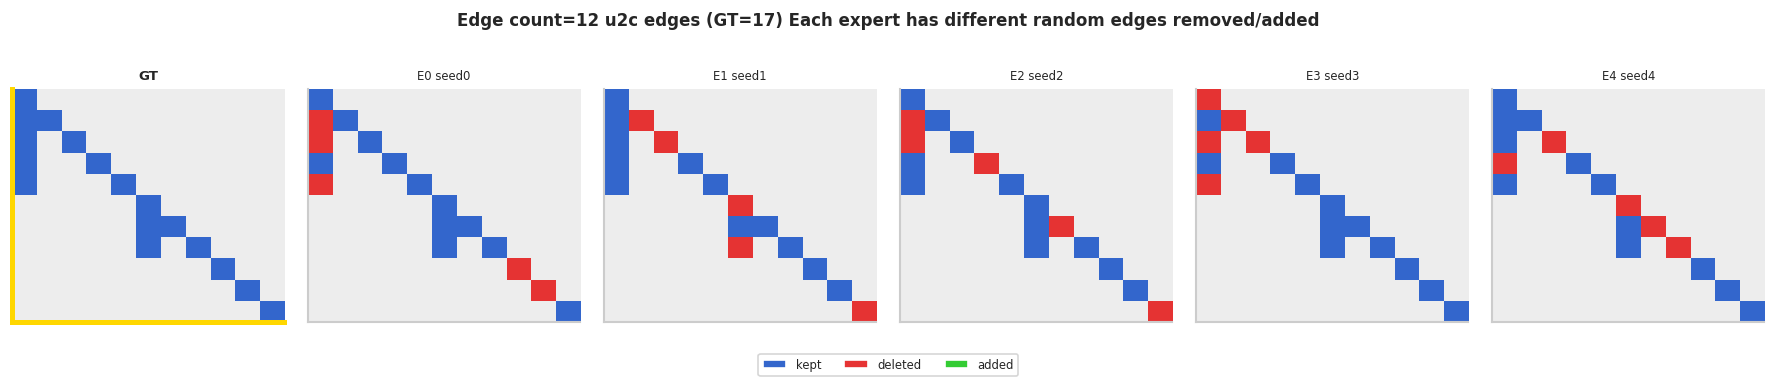

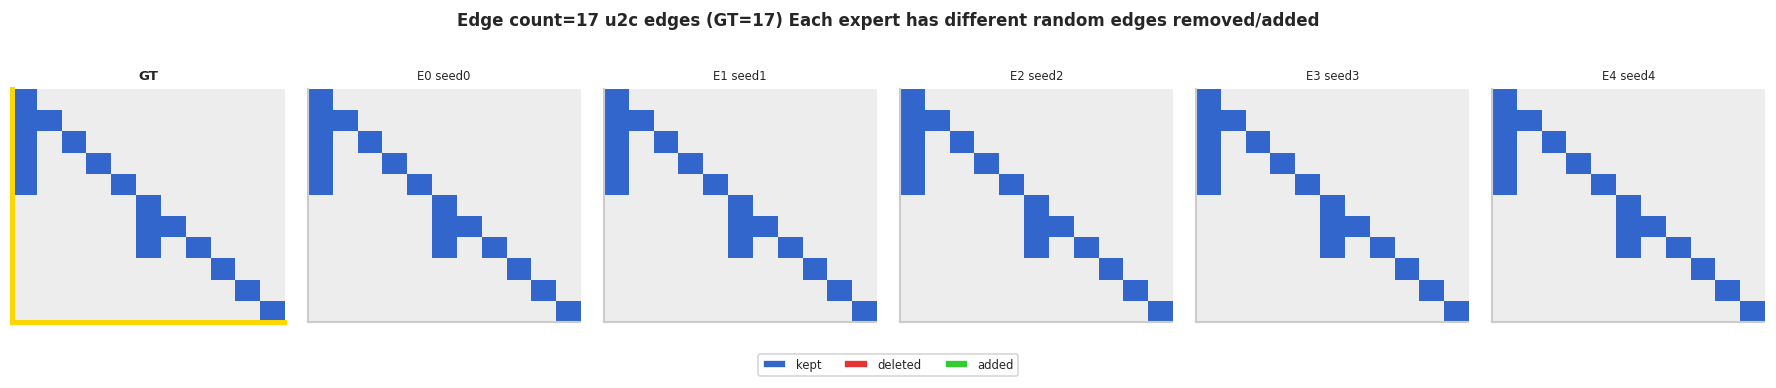

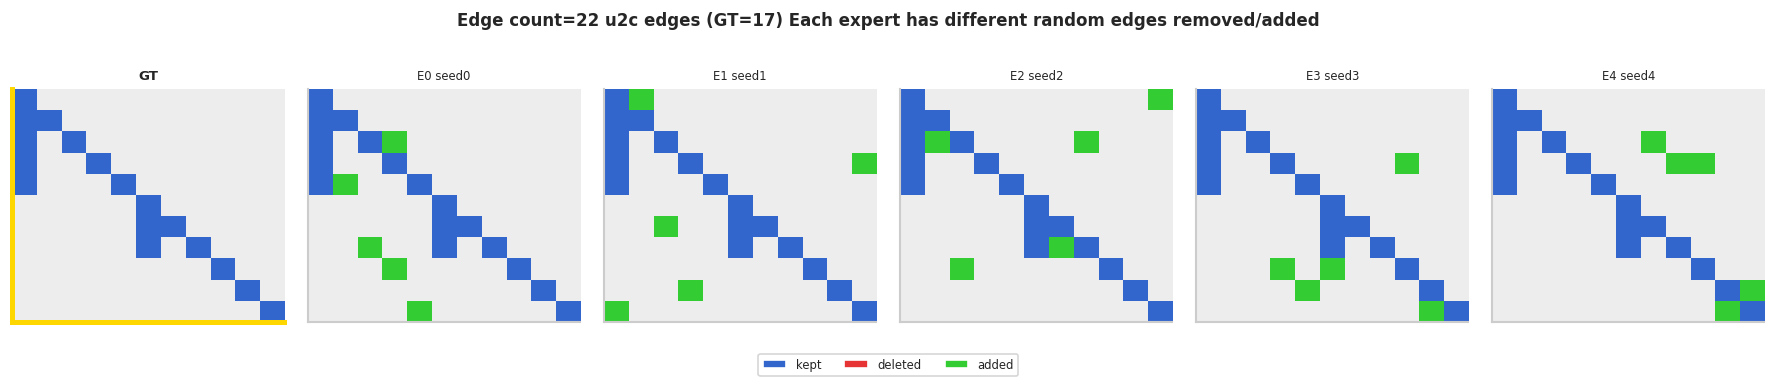

In [6]:
# Show expert graphs for a specific edge count
# Each expert has different random edges removed/added at the same total count
edge_counts_to_show = [12, 17, 22]  # GT-5, GT, GT+5
graphs_base = GRAPHS_ROOT / 'expert_graphs' / 'graph_ensemble_edge_count'

for count in edge_counts_to_show:
    d = graphs_base / f'u2c_{count}edges'
    if not d.exists(): print(f'Graphs not found: {d}'); continue
    dirs_and_indices = [(d, m, f'E{m} seed{m}') for m in range(N_EXPERTS)]
    show_expert_dags(dirs_and_indices, f'Edge count={count} u2c edges (GT=17) Each expert has different random edges removed/added')


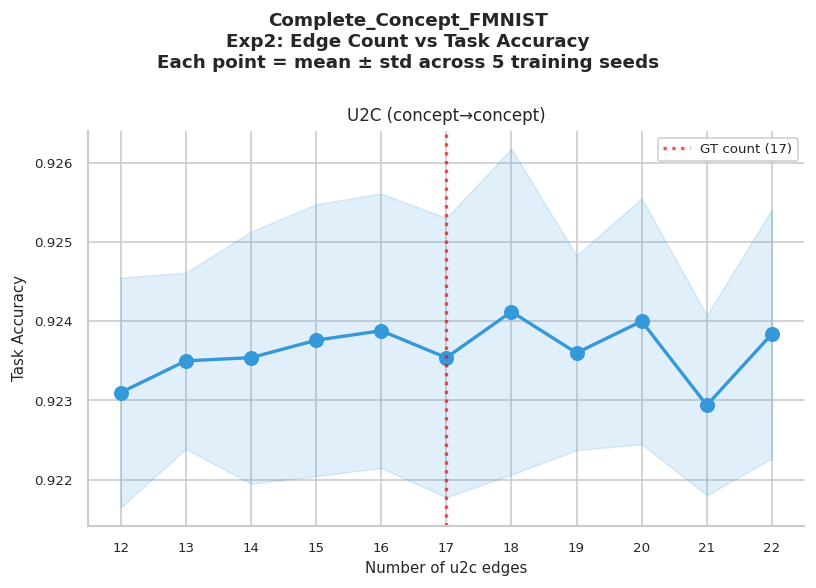

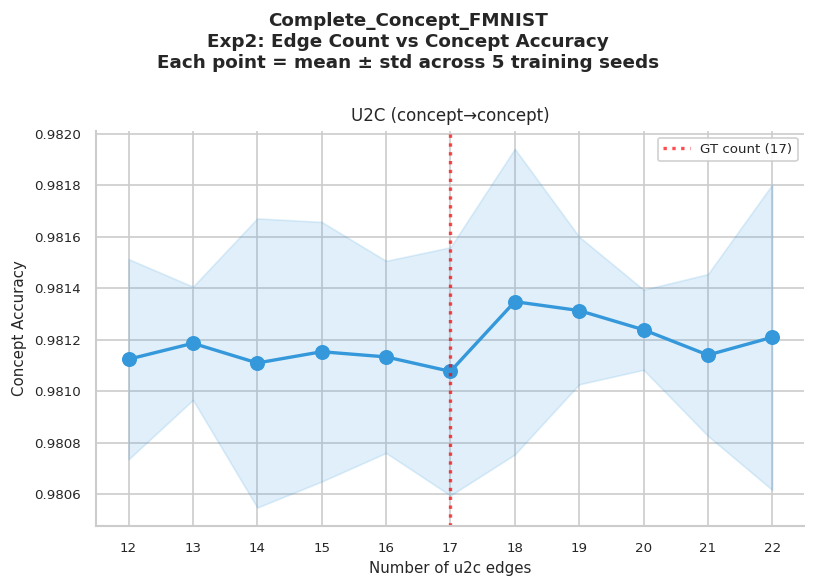

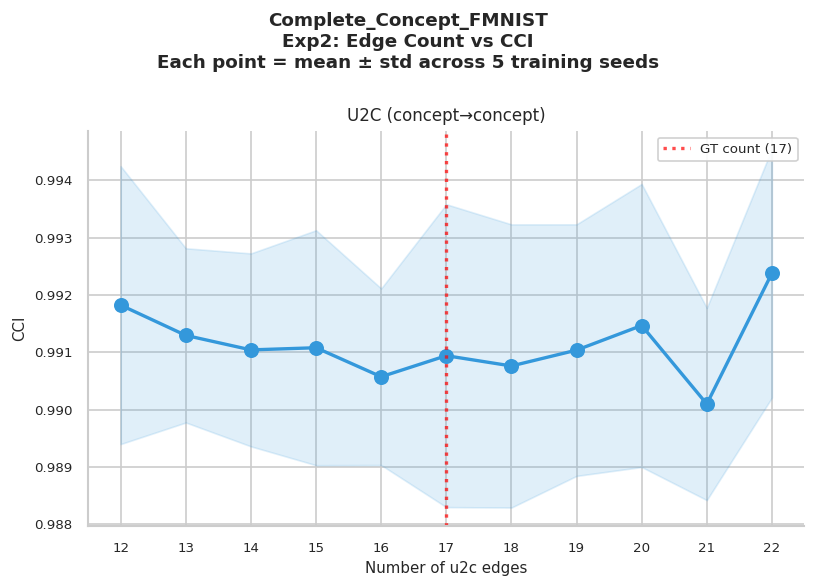

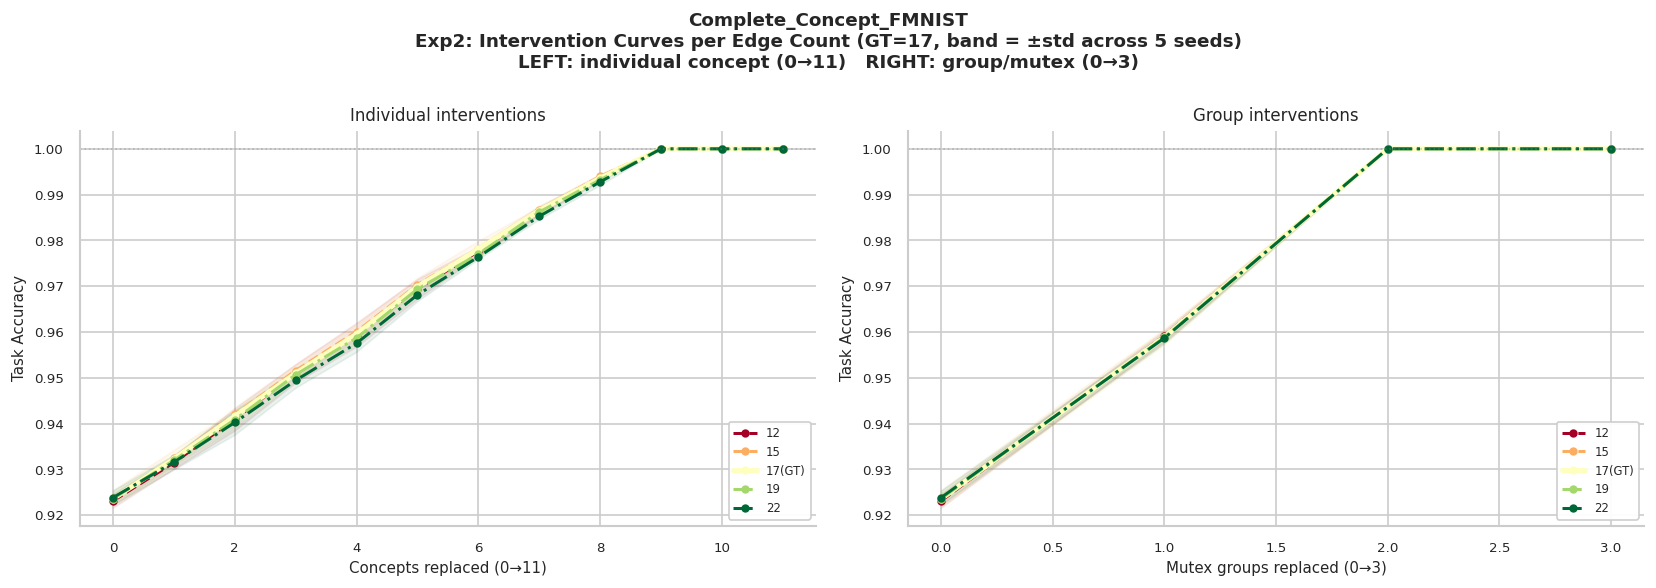

In [7]:
if len(exp2_df)==0:
    print('No Exp2 data yet.')
    print('Submit: bash server_scripts/mcream_experiment/submit_graph_ensemble_edge_count.sh --u2c-only')
else:
    GT_COUNT = 17
    TYPE_COLOR = {'u2c':'#3498db','c2y':'#e74c3c'}

    for metric, ylabel in [('test_task_accuracy','Task Accuracy'),
                            ('test_concept_accuracy','Concept Accuracy'),
                            ('CCI','CCI'),
                            ('PFI_concept_importance','PFI Concept Importance'),
                            ('PFI_side_importance','PFI Side Importance')]:
        if metric not in exp2_df.columns: continue
        for ds in DATASETS:
            ds_df=exp2_df[exp2_df['dataset']==ds].dropna(subset=[metric])
            if ds_df.empty: continue
            graph_types=sorted(ds_df['graph_type'].unique())
            fig,axes=plt.subplots(1,len(graph_types),figsize=(7*len(graph_types),5),sharey=False)
            if len(graph_types)==1: axes=[axes]
            fig.suptitle(f'{ds}\nExp2: Edge Count vs {ylabel}\n'
                         f'Each point = mean Â± std across 5 training seeds',
                         fontsize=11,fontweight='bold')
            for ax,gtype in zip(axes,graph_types):
                sub=ds_df[ds_df['graph_type']==gtype]
                edge_counts=sorted(sub['edge_count'].unique())
                color=TYPE_COLOR.get(gtype,'#3498db')
                agg=sub.groupby('edge_count')[metric].agg(['mean','std']).reset_index()
                ax.plot(agg['edge_count'],agg['mean'],color=color,marker='o',markersize=8,lw=2)
                ax.fill_between(agg['edge_count'],agg['mean']-agg['std'],agg['mean']+agg['std'],alpha=0.15,color=color)
                ax.axvline(x=GT_COUNT,color='red',ls=':',lw=2,alpha=0.7,label=f'GT count ({GT_COUNT})')
                if len(gt_df)>0 and metric in gt_df.columns:
                    sub2=gt_df[gt_df['dataset']==ds]
                    if not sub2.empty and pd.notna(sub2[metric].mean()):
                        v=sub2[metric].mean()
                        ax.axhline(v,color='black',lw=2,ls='--',label=f'GT CREAM: {v:.4f}')
                ax.set_title(f'{gtype.upper()} ({"conceptâ†’concept" if gtype=="u2c" else "conceptâ†’task"})',fontsize=10)
                ax.set_xlabel('Number of u2c edges',fontsize=9)
                ax.set_ylabel(ylabel,fontsize=9)
                ax.set_xticks(edge_counts); ax.tick_params(labelsize=8)
                ax.legend(fontsize=8,framealpha=0.9)
            plt.tight_layout()
            plt.savefig(f'exp2_edge_count_{metric}_{ds}.png',dpi=150,bbox_inches='tight')
            plt.show()

    # â”€â”€ Intervention curves: individual and group shown separately â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    exp2_interv = load_interventions(EXPERIMENTS_ROOT, exp_name_filter=['gensemble_edge_count_u2c'])

    if len(exp2_interv) > 0:
        import re
        exp2_interv['edge_count'] = exp2_interv['exp_name'].apply(
            lambda x: int(re.search(r'(\d+)edges', x).group(1))
            if re.search(r'(\d+)edges', x) else None)
        exp2_interv = exp2_interv.dropna(subset=['edge_count'])
        exp2_interv['edge_count'] = exp2_interv['edge_count'].astype(int)

        has_group_col = 'group_interventions' in exp2_interv.columns
        sub_indiv = exp2_interv[exp2_interv['group_interventions']==False] if has_group_col else exp2_interv
        sub_group = exp2_interv[exp2_interv['group_interventions']==True]  if has_group_col else pd.DataFrame()

        cmap = plt.cm.RdYlGn
        for ds in DATASETS:
            show_counts = [c for c in [12, 15, 17, 19, 22] if c in sub_indiv['edge_count'].unique()]
            if not show_counts: show_counts = sorted(sub_indiv['edge_count'].unique())
            all_counts = sorted(sub_indiv['edge_count'].unique())

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(
                f'{ds}\nExp2: Intervention Curves per Edge Count (GT=17, band = Â±std across 5 seeds)\n'
                f'LEFT: individual concept (0â†’11)   RIGHT: group/mutex (0â†’3)',
                fontsize=11, fontweight='bold'
            )

            for ax, src, xlabel, title_suffix in [
                (axes[0], sub_indiv, 'Concepts replaced (0â†’11)',  'Individual interventions'),
                (axes[1], sub_group, 'Mutex groups replaced (0â†’3)', 'Group interventions'),
            ]:
                ds_src = src[src['dataset']==ds] if 'dataset' in src.columns else src
                if ds_src.empty:
                    ax.set_title(f'{title_suffix} â€” no data'); ax.axis('off'); continue
                sc = [c for c in show_counts if c in ds_src['edge_count'].unique()]
                for count in sc:
                    lv  = ds_src[ds_src['edge_count']==count]
                    agg = lv.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                    norm  = all_counts.index(count) / max(len(all_counts)-1, 1)
                    color = cmap(norm)
                    style = '--' if count < GT_COUNT else ('-' if count==GT_COUNT else '-.')
                    lw    = 3 if count==GT_COUNT else 1.8
                    ax.plot(agg['num_interventions'], agg['mean'],
                            color=color, lw=lw, ls=style, marker='o', markersize=4,
                            label=f'{count}{"(GT)" if count==GT_COUNT else ""}')
                    ax.fill_between(agg['num_interventions'],
                                    agg['mean']-agg['std'], agg['mean']+agg['std'],
                                    alpha=0.08, color=color)
                ax.axhline(1.0, color='gray', ls=':', alpha=0.4, lw=1)
                ax.set_title(title_suffix, fontsize=10)
                ax.set_xlabel(xlabel, fontsize=9)
                ax.set_ylabel('Task Accuracy', fontsize=9)
                ax.legend(fontsize=7, loc='lower right', framealpha=0.95)
                ax.tick_params(labelsize=8)

            plt.tight_layout()
            plt.savefig(f'exp2_interventions_{ds}.png', dpi=150, bbox_inches='tight')
            plt.show()
    else:
        print('No intervention results for Exp2 yet.')

---
# Experiment 3 â€” Mixed Noise Levels

Experts from different noise levels (low/medium/high) in ONE model.
Î»_m should learn: high-noise experts get higher weight (harder to train).


In [ ]:
def load_mixed_level_results(root):
    """Load Exp3: mixed noise levels.
    Folder names: graph_ensemble_mixed_deletion, graph_ensemble_mixed_addition, etc.
    """
    rows=[]
    for ds in DATASETS:
        ens_dir=root/ds/'train_cbm'/'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for exp_dir in sorted(ens_dir.iterdir()):
            if not exp_dir.is_dir(): continue
            name=exp_dir.name
            if 'mixed' not in name or not name.startswith('graph_ensemble_mixed'): continue
            # Extract action: graph_ensemble_mixed_{action}
            action=name.replace('graph_ensemble_mixed_','')
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed=int(seed_dir.parent.parent.name.split('_')[1])
                for csv_f in sorted(seed_dir.glob('*.csv')):
                    if any(x in csv_f.name for x in ['perc_','_set_','intervention','exogenous']): continue
                    try:
                        df=pd.read_csv(csv_f)
                        df['dataset']=ds;df['action']=action;df['seed']=seed
                        rows.append(df)
                    except: pass
    if not rows: print('No Exp3 data yet'); return pd.DataFrame()
    df=pd.concat(rows,ignore_index=True)
    print(f'Exp3 loaded: {len(df)} rows | actions={sorted(df.action.unique())}')
    return df

exp3_df     = load_mixed_level_results(EXPERIMENTS_ROOT)
exp3_interv = load_interventions(EXPERIMENTS_ROOT, exp_name_filter=['graph_ensemble_mixed'])


In [ ]:
# Show which expert graphs are used in mixed experiment
graphs_base = GRAPHS_ROOT / 'expert_graphs' / 'ensemble'
for action in ACTIONS:
    # Mixed assignment: low/0, medium/0, high/0, low/1, high/1
    dirs_and_indices = [
        (graphs_base/f'{action}_low',    0, f'E0\nlow'),
        (graphs_base/f'{action}_medium', 0, f'E1\nmedium'),
        (graphs_base/f'{action}_high',   0, f'E2\nhigh'),
        (graphs_base/f'{action}_low',    1, f'E3\nlow'),
        (graphs_base/f'{action}_high',   1, f'E4\nhigh'),
    ]
    show_expert_dags(dirs_and_indices, f'Exp3 mixed {action}: expert graphs (different noise levels)')


In [ ]:
if len(exp3_df)==0: print('No Exp3 data yet. Submit: bash submit_graph_ensemble.sh then run mixed configs')
else:
    KEY=['test_task_accuracy','test_concept_accuracy','CCI','PFI_concept_importance','PFI_side_importance']
    av=[c for c in KEY if c in exp3_df.columns]
    print('--- Experiment 3: Mixed Noise Levels ---')
    display(exp3_df.groupby('action')[av].mean().round(4))
    # Lambda weights â€” the key result for Exp3
    lambda_cols=[c for c in exp3_df.columns if c.startswith('lambda_')]
    if lambda_cols:
        print('\nLearned lambda weights per expert (0=low noise, 2=high noise):')
        lam=exp3_df.groupby('action')[lambda_cols].mean().round(4)
        lam.columns=[f'E{c.replace("lambda_","")}' for c in lam.columns]
        display(lam)
        # Bar chart of lambdas
        fig,axes=plt.subplots(1,len(exp3_df['action'].unique()),figsize=(5*len(exp3_df['action'].unique()),4))
        if not hasattr(axes,'__len__'): axes=[axes]
        expert_labels=['E0\n(low)','E1\n(med)','E2\n(high)','E3\n(low)','E4\n(high)']
        for ax,action in zip(axes,sorted(exp3_df['action'].unique())):
            sub=exp3_df[exp3_df['action']==action][lambda_cols].mean()
            colors=['#3498db','#e67e22','#e74c3c','#3498db','#e74c3c']
            ax.bar(range(len(sub)),sub.values,color=colors,alpha=0.8)
            ax.axhline(0.2,color='black',ls='--',lw=1.5,alpha=0.5,label='uniform (0.2)')
            ax.set_xticks(range(len(sub))); ax.set_xticklabels(expert_labels,fontsize=8)
            ax.set_title(action,fontsize=10); ax.set_ylabel('Lambda weight')
            ax.legend(fontsize=7)
        fig.suptitle('Exp3: Learned lambda per expert\n(blue=low noise, red=high noise)',fontsize=11,fontweight='bold')
        plt.tight_layout(); plt.savefig('exp3_lambdas.png',dpi=150,bbox_inches='tight'); plt.show()
    # Intervention curves
    if len(exp3_interv)>0:
        fig,axes=plt.subplots(1,len(ACTIONS),figsize=(5*len(ACTIONS),4.5),sharey=True)
        fig.suptitle('Exp3: Mixed levels â€” intervention curves',fontsize=11,fontweight='bold')
        for ax,action in zip(axes,ACTIONS):
            sub=exp3_interv[exp3_interv['exp_name'].str.contains(f'mixed_{action}')]
            if sub.empty: ax.set_title(action); continue
            agg=sub.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
            ax.plot(agg['num_interventions'],agg['mean'],color=ACTION_COLOR[action],lw=2.5,marker='o',markersize=5)
            ax.fill_between(agg['num_interventions'],agg['mean']-agg['std'],agg['mean']+agg['std'],alpha=0.15,color=ACTION_COLOR[action])
            ax.set_title(action,fontsize=10); ax.set_xlabel('Interventions'); ax.tick_params(labelsize=8)
            ax.set_ylabel('Task Accuracy' if action==ACTIONS[0] else '')
        plt.tight_layout(); plt.savefig('exp3_interventions.png',dpi=150,bbox_inches='tight'); plt.show()


---
# Alpha Matrix Analysis (use_alpha=True experiments only)

`alpha_prob[i,j]` = learned importance of edge concept_i â†’ concept_j.

- **High value (near 1)** â†’ edge is important for task/concept accuracy
- **Low value (near 0)** â†’ edge was suppressed by L1 regularization
- Only edges present in the expert graph can have nonzero alpha (structural zeros enforced)

Saved per seed as `alpha_prob_seed{N}.csv` inside `lightning_logs/version_0/`.

---
# Experiment 4 â€” Consensus Experts + Shared Alpha Matrix

M=5 experts with 90% pairwise consensus (shared base noise + 5% private flips).
Shared learnable Î±[K,K] matrix gates edge importance across all experts.

**Three noise levels (updated):**
- `low`    â†’ base corruption 15% of GT edges
- `medium` â†’ base corruption 25%
- `high`   â†’ base corruption 50%

**What to look for:**
- Does Î± converge to high values on GT edges (diagonal) and low on corrupted edges?
- Does higher base noise â†’ lower task accuracy / higher alpha sparsity?
- Compare intervention curves vs Exp1 (single-action noise, no alpha)

**Datasets:** cfmnist + CelebA

In [ ]:
def load_alpha_matrices(root, exp_name_filter=None):
    """Load alpha_prob_seed*.csv for all seeds of matching experiments â€” both datasets."""
    result = {}
    search_datasets = ['Complete_Concept_FMNIST', 'CelebA','CUB']
    for ds in search_datasets:
        ens_dir = root / ds / 'train_cbm' / 'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for exp_dir in sorted(ens_dir.iterdir()):
            if not exp_dir.is_dir(): continue
            name = exp_dir.name
            if exp_name_filter and not any(f in name for f in exp_name_filter): continue
            seed_alphas = {}
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed = int(seed_dir.parent.parent.name.split('_')[1])
                for alpha_f in sorted(seed_dir.glob('alpha_prob_seed*.csv')):
                    try:
                        df = pd.read_csv(alpha_f, index_col=0)
                        seed_alphas[seed] = df
                    except: pass
            if seed_alphas:
                key = f'{ds}/{name}'
                result[key] = seed_alphas
    if not result:
        print('No alpha matrices found. Run with use_alpha=True in config.')
    else:
        print(f'Loaded alpha for {len(result)} experiments')
        for k, v in result.items():
            print(f'  {k}: {len(v)} seeds')
    return result


def plot_alpha(alpha_df, title, ax=None, vmin=0, vmax=1):
    """Plot alpha [K,K] heatmap â€” grey=low importance, green=high importance."""
    standalone = ax is None
    if standalone:
        K = alpha_df.shape[0]
        fig_size = max(7, K * 0.12)
        fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.9))
    from matplotlib.colors import LinearSegmentedColormap
    cmap_gg = LinearSegmentedColormap.from_list('grey_green',
        ['#e8e8e8', '#c8e6c9', '#66bb6a', '#2e7d32'])
    K = alpha_df.shape[0]
    do_annot   = K <= 20
    lw         = 0.3 if K <= 30 else 0.0   # no grid lines for large matrices
    tick_fs    = max(4, 8 - K // 15)
    sns.heatmap(alpha_df, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap_gg,
                annot=do_annot, fmt='.2f', linewidths=lw, square=True,
                annot_kws={'size': 7},
                cbar_kws={'label': 'Edge importance Î±[i,j]'})
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Target concept j', fontsize=8)
    ax.set_ylabel('Source concept i', fontsize=8)
    ax.tick_params(labelsize=tick_fs)
    if standalone:
        plt.tight_layout()
        plt.show()
    return ax


# â”€â”€ Load alpha for all experiments â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
all_alpha = load_alpha_matrices(EXPERIMENTS_ROOT)

if all_alpha:
    for exp_key, seed_alphas in all_alpha.items():
        seeds = sorted(seed_alphas.keys())
        stacked = np.stack([seed_alphas[s].values for s in seeds], axis=0)
        mean_alpha = pd.DataFrame(stacked.mean(axis=0),
                                  index=seed_alphas[seeds[0]].index,
                                  columns=seed_alphas[seeds[0]].columns)
        std_alpha  = pd.DataFrame(stacked.std(axis=0),
                                  index=seed_alphas[seeds[0]].index,
                                  columns=seed_alphas[seeds[0]].columns)

        K = mean_alpha.shape[0]
        n_show = min(len(seeds) + 1, 4)
        cell_size = max(6, K * 0.12)
        fig, axes = plt.subplots(1, n_show, figsize=(cell_size * n_show, cell_size * 0.9))
        if not hasattr(axes, '__len__'): axes = [axes]
        fig.suptitle(f'Alpha matrix â€” {exp_key}\n'
                     f'Grey=low importance, Green=high importance\n'
                     f'Row=source concept i, Col=target concept j',
                     fontsize=10, fontweight='bold')
        plot_alpha(mean_alpha, f'Mean (n={len(seeds)} seeds)', axes[0])
        for ax, seed in zip(axes[1:], seeds[:3]):
            plot_alpha(seed_alphas[seed], f'Seed {seed}', ax)
        plt.tight_layout()
        safe = exp_key.replace('/', '_')
        plt.savefig(f'alpha_{safe}.png', dpi=150, bbox_inches='tight')
        plt.show()

        print(f'\n--- {exp_key}: Top 5 most important edges (mean Î±) ---')
        flat = mean_alpha.stack().sort_values(ascending=False)
        for (src, tgt), val in flat.head(5).items():
            print(f'  {src} â†’ {tgt}: Î±={val:.3f} Â± {std_alpha.loc[src,tgt]:.3f}')
        print(f'--- Bottom 5 ---')
        for (src, tgt), val in flat[flat > 0].tail(5).items():
            print(f'  {src} â†’ {tgt}: Î±={val:.3f}')

Exp4 loaded: 45 rows | datasets=['CUB', 'CelebA', 'Complete_Concept_FMNIST'] | levels=['high', 'low', 'medium']
Loaded alpha for 18 experiments
  Complete_Concept_FMNIST/graph_ensemble_consensus_dynamic_high: 5 seeds
  Complete_Concept_FMNIST/graph_ensemble_consensus_dynamic_low: 5 seeds
  Complete_Concept_FMNIST/graph_ensemble_consensus_dynamic_medium: 5 seeds
  Complete_Concept_FMNIST/graph_ensemble_consensus_high: 5 seeds
  Complete_Concept_FMNIST/graph_ensemble_consensus_low: 5 seeds
  Complete_Concept_FMNIST/graph_ensemble_consensus_medium: 5 seeds
  CelebA/graph_ensemble_consensus_dynamic_high: 5 seeds
  CelebA/graph_ensemble_consensus_dynamic_low: 5 seeds
  CelebA/graph_ensemble_consensus_dynamic_medium: 5 seeds
  CelebA/graph_ensemble_consensus_high: 5 seeds
  CelebA/graph_ensemble_consensus_low: 5 seeds
  CelebA/graph_ensemble_consensus_medium: 5 seeds
  CUB/graph_ensemble_consensus_dynamic_high: 5 seeds
  CUB/graph_ensemble_consensus_dynamic_low: 5 seeds
  CUB/graph_ensemble_

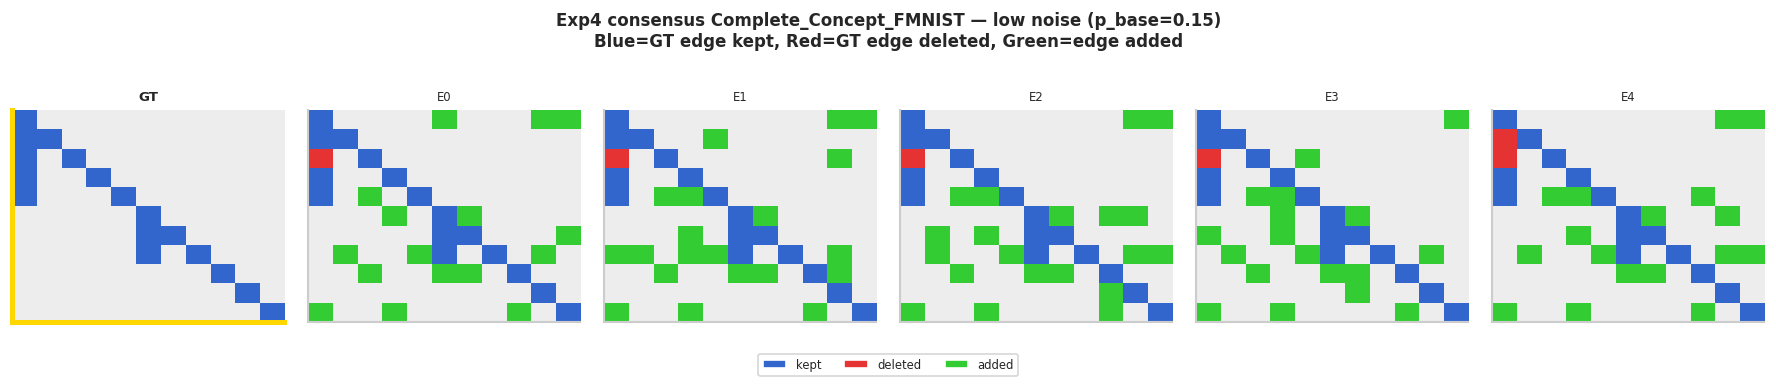

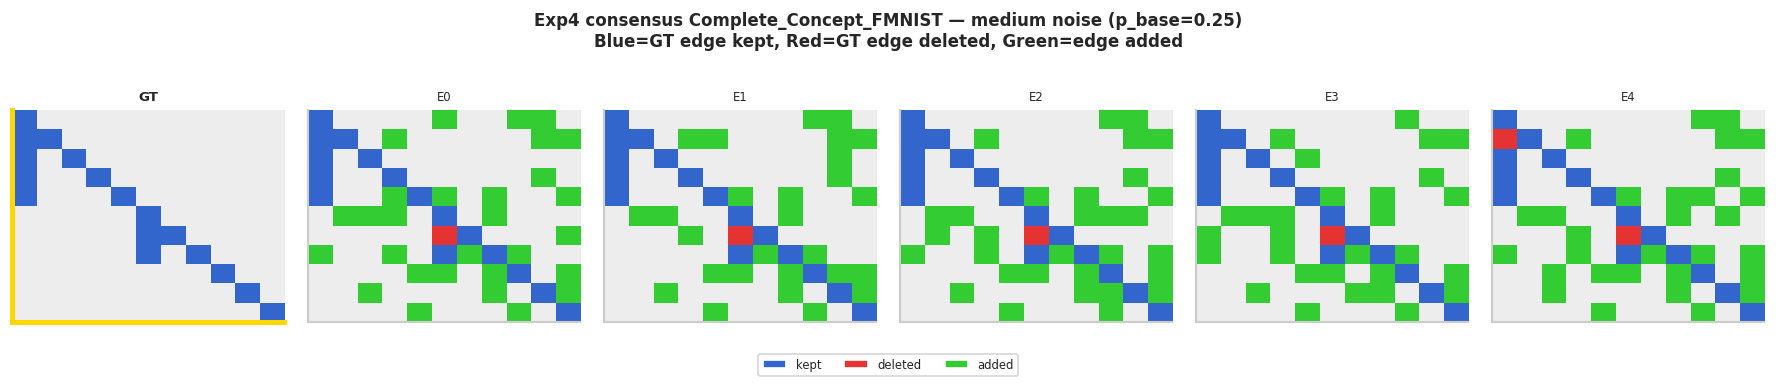

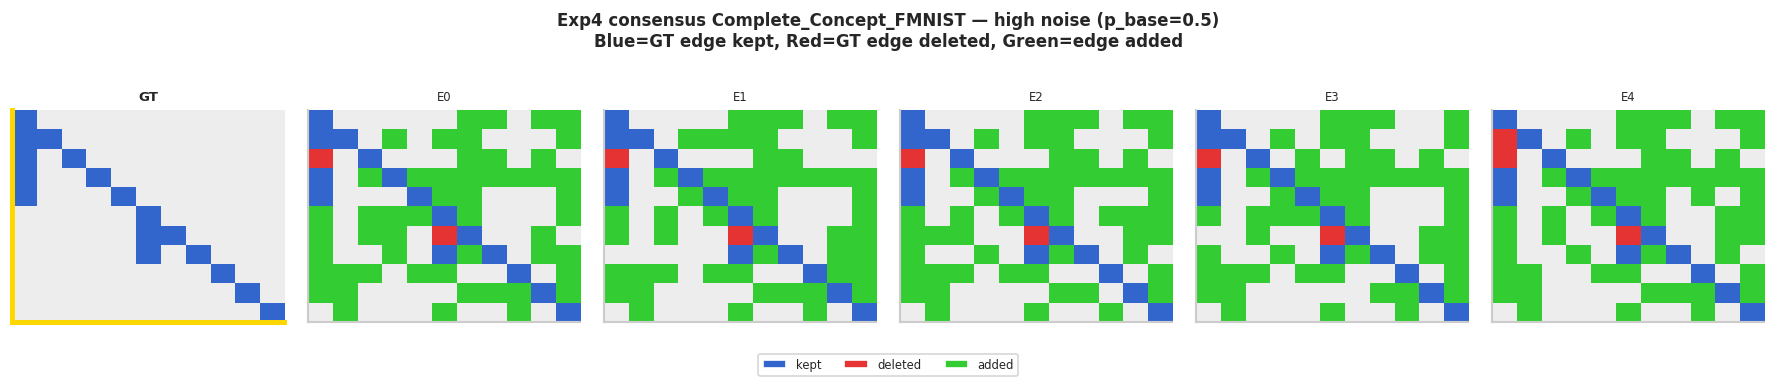

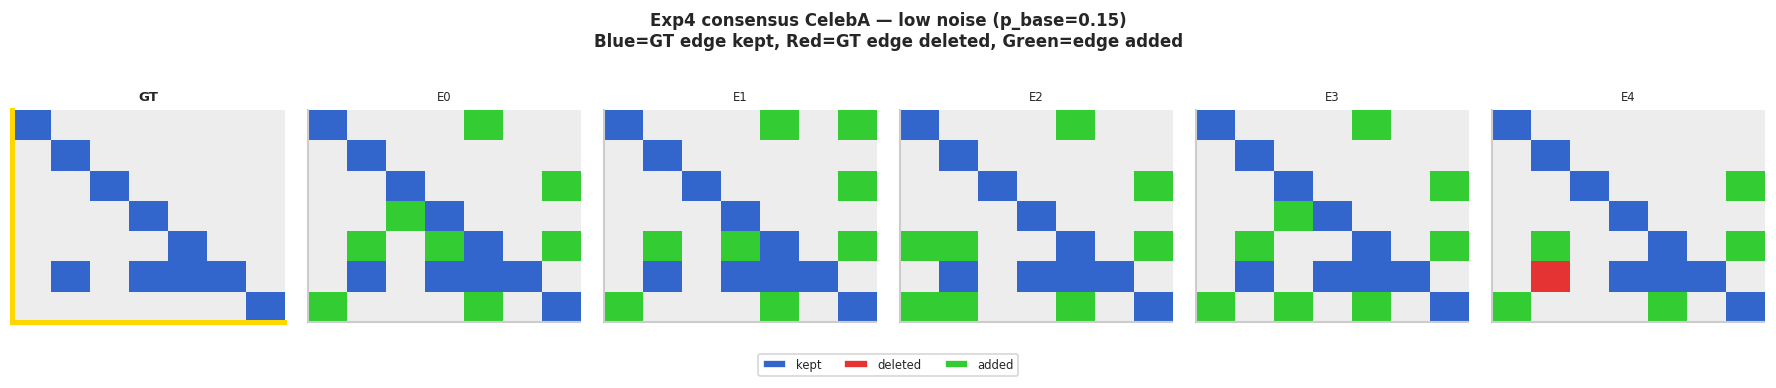

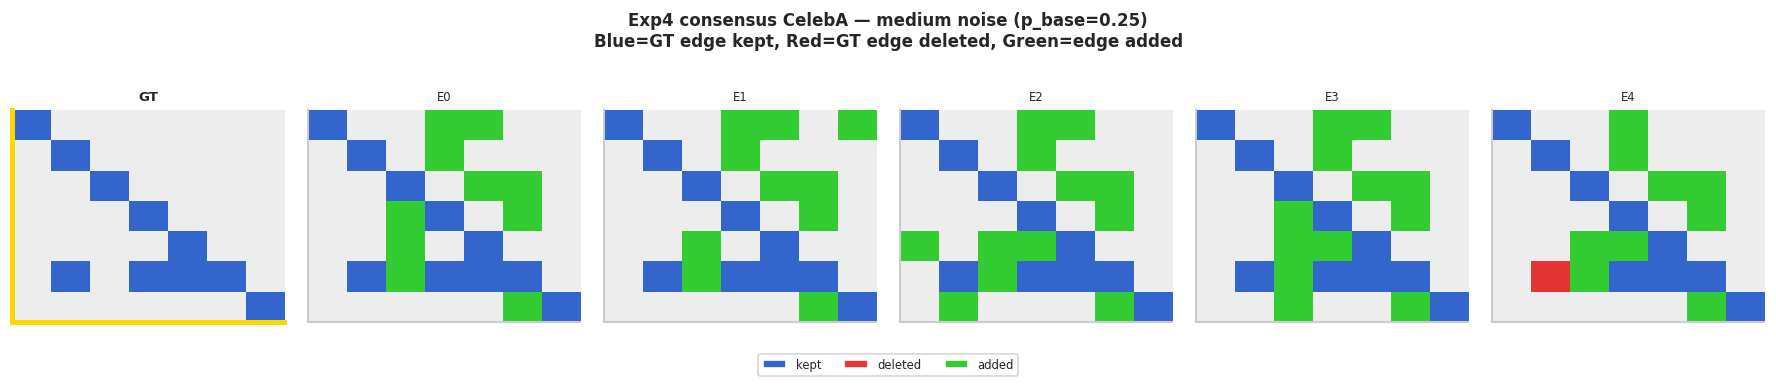

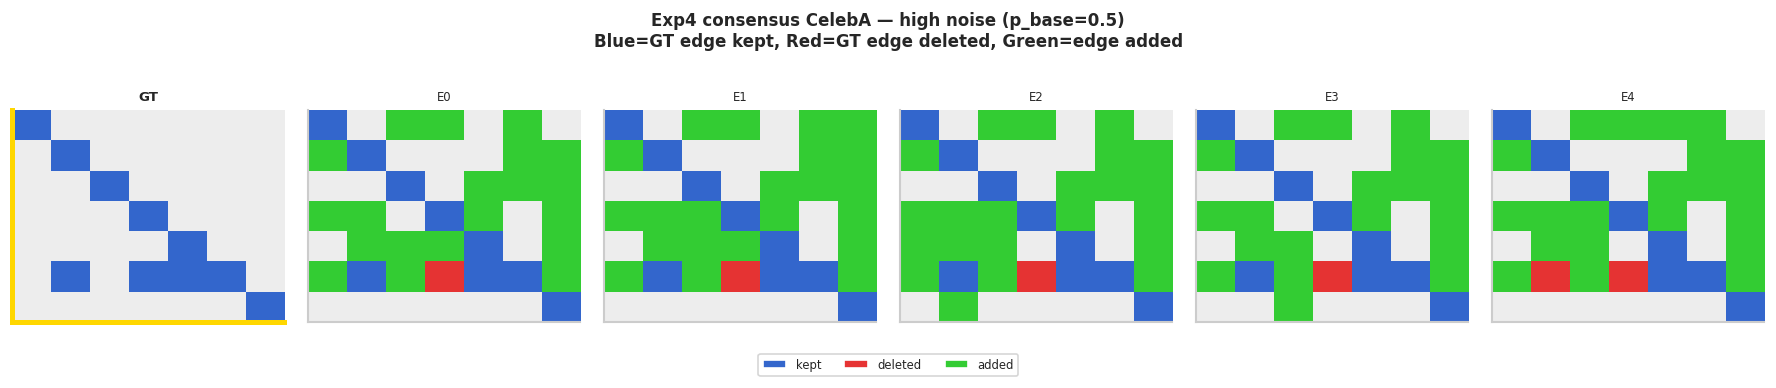

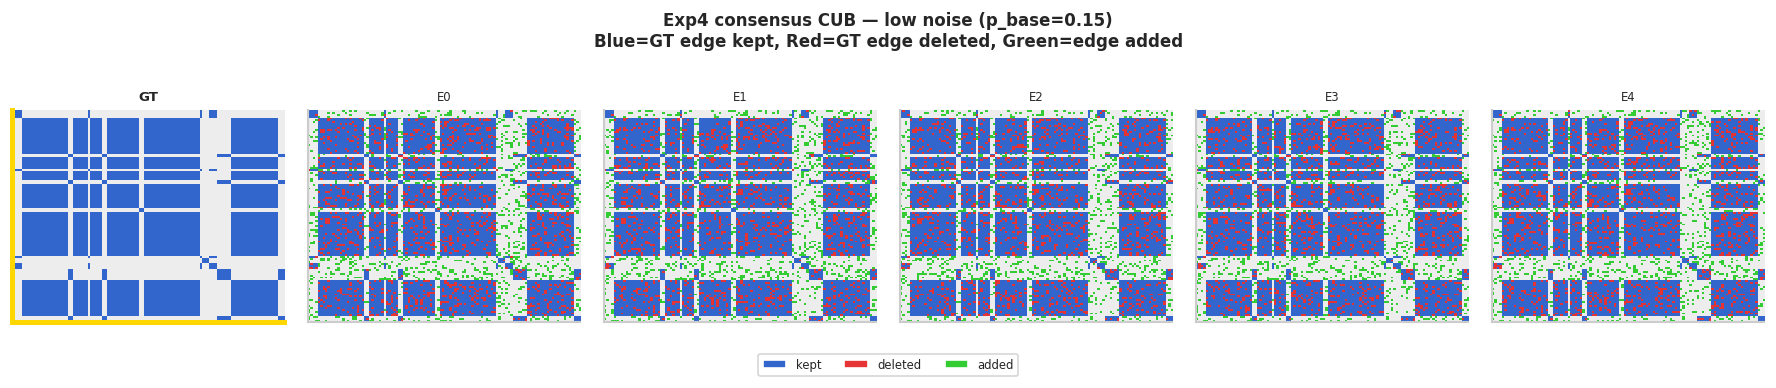

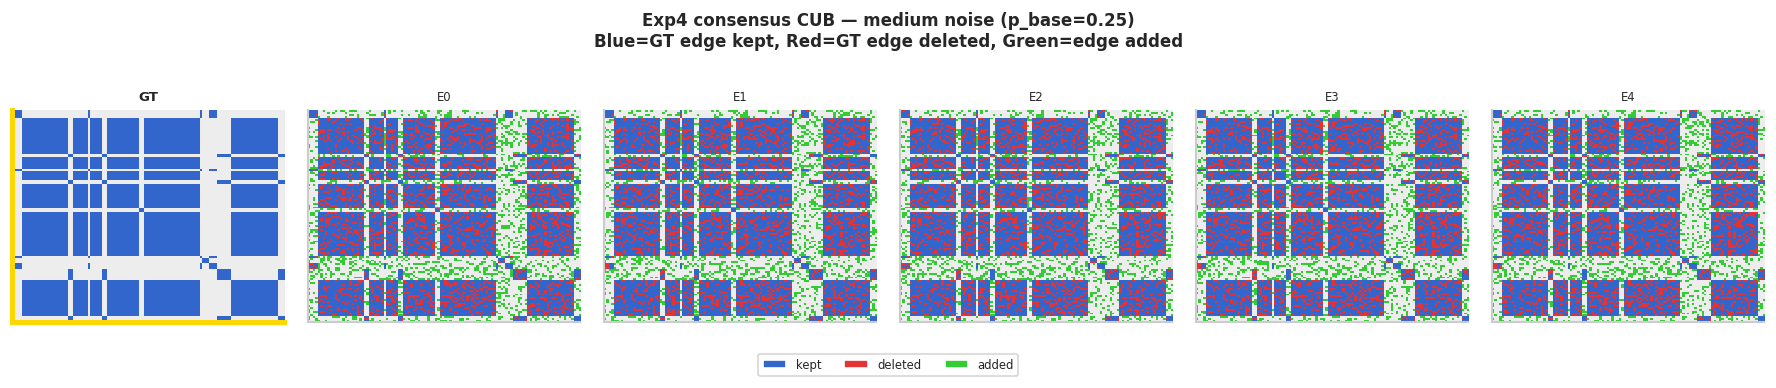

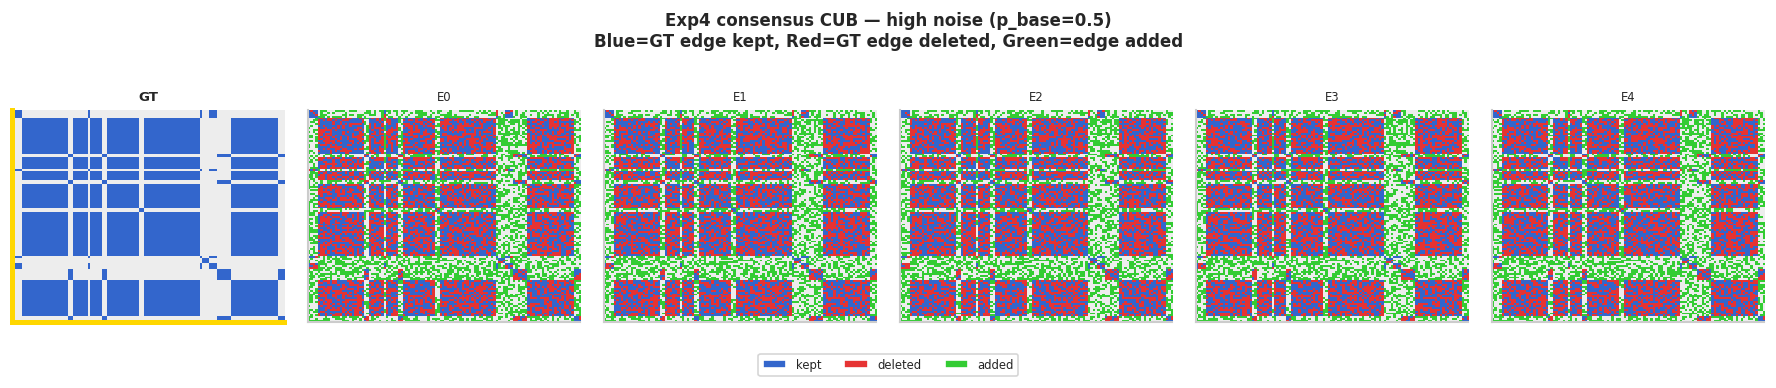

In [4]:
def load_consensus_results(root):
    """Load Exp4 results for cfmnist, CelebA, and CUB."""
    rows = []
    for ds in list(DATASET_CONFIG.keys()):
        ens_dir = root / ds / 'train_cbm' / 'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for exp_dir in sorted(ens_dir.iterdir()):
            name = exp_dir.name
            if not name.startswith('graph_ensemble_consensus_'): continue
            import re
            m = re.match(r'graph_ensemble_consensus_(low|medium|high)', name)
            if not m: continue
            level = m.group(1)
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed = int(seed_dir.parent.parent.name.split('_')[1])
                for csv_f in sorted(seed_dir.glob('*.csv')):
                    if any(x in csv_f.name for x in ['perc_','_set_','intervention','exogenous','alpha']): continue
                    try:
                        df = pd.read_csv(csv_f)
                        df['dataset'] = ds; df['noise_level'] = level; df['seed'] = seed
                        rows.append(df)
                    except: pass
    if not rows: print('No Exp4 consensus results yet.'); return pd.DataFrame()
    df = pd.concat(rows, ignore_index=True)
    print(f'Exp4 loaded: {len(df)} rows | datasets={sorted(df.dataset.unique())} | levels={sorted(df.noise_level.unique())}')
    return df

exp4_df     = load_consensus_results(EXPERIMENTS_ROOT)
exp4_interv = load_interventions(EXPERIMENTS_ROOT, exp_name_filter=['graph_ensemble_consensus'],
                                  datasets=list(DATASET_CONFIG.keys()))
exp4_alpha  = load_alpha_matrices(EXPERIMENTS_ROOT, exp_name_filter=['graph_ensemble_consensus'])

# â”€â”€ Show expert graphs for each dataset Ã— level â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
for ds, dscfg in DATASET_CONFIG.items():
    graphs_base = dscfg['graphs_root'] / 'expert_graphs' / 'consensus'
    K           = dscfg['num_concepts']
    dag_path    = dscfg['dag']
    if not dag_path.exists(): continue

    for level in LEVELS:
        level_dir = graphs_base / level
        if not level_dir.exists(): print(f'Graphs not found: {level_dir}'); continue
        dirs_and_indices = [(level_dir, m, f'E{m}') for m in range(N_EXPERTS)]
        p_base = {"low": 0.15, "medium": 0.25, "high": 0.50}[level]
        show_expert_dags(
            dirs_and_indices,
            f'Exp4 consensus {ds} â€” {level} noise (p_base={p_base})\n'
            f'Blue=GT edge kept, Red=GT edge deleted, Green=edge added',
            K=K, dag_path=dag_path
        )

=== Exp4: CUB â€” Consensus 90% + shared alpha ===


,test_task_accuracy,test_concept_accuracy,CCI
noise_level,,,
high,0.7353 Â± 0.0017,0.8479 Â± 0.0006,0.9518 Â± 0.0031
low,0.7354 Â± 0.0020,0.8483 Â± 0.0005,0.9516 Â± 0.0028
medium,0.7363 Â± 0.0018,0.8484 Â± 0.0008,0.9517 Â± 0.0029


=== Exp4: CelebA â€” Consensus 90% + shared alpha ===


,test_task_accuracy,test_concept_accuracy,CCI
noise_level,,,
high,0.7931 Â± 0.0108,0.8051 Â± 0.0054,0.9256 Â± 0.1495
low,0.8018 Â± 0.0118,0.8070 Â± 0.0086,0.9186 Â± 0.1395
medium,0.8018 Â± 0.0198,0.8015 Â± 0.0070,0.9181 Â± 0.1456


=== Exp4: Complete_Concept_FMNIST â€” Consensus 90% + shared alpha ===


,test_task_accuracy,test_concept_accuracy,CCI
noise_level,,,
high,0.9247 Â± 0.0007,0.9814 Â± 0.0004,0.9914 Â± 0.0018
low,0.9240 Â± 0.0010,0.9813 Â± 0.0003,0.9913 Â± 0.0011
medium,0.9246 Â± 0.0007,0.9815 Â± 0.0002,0.9904 Â± 0.0026


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


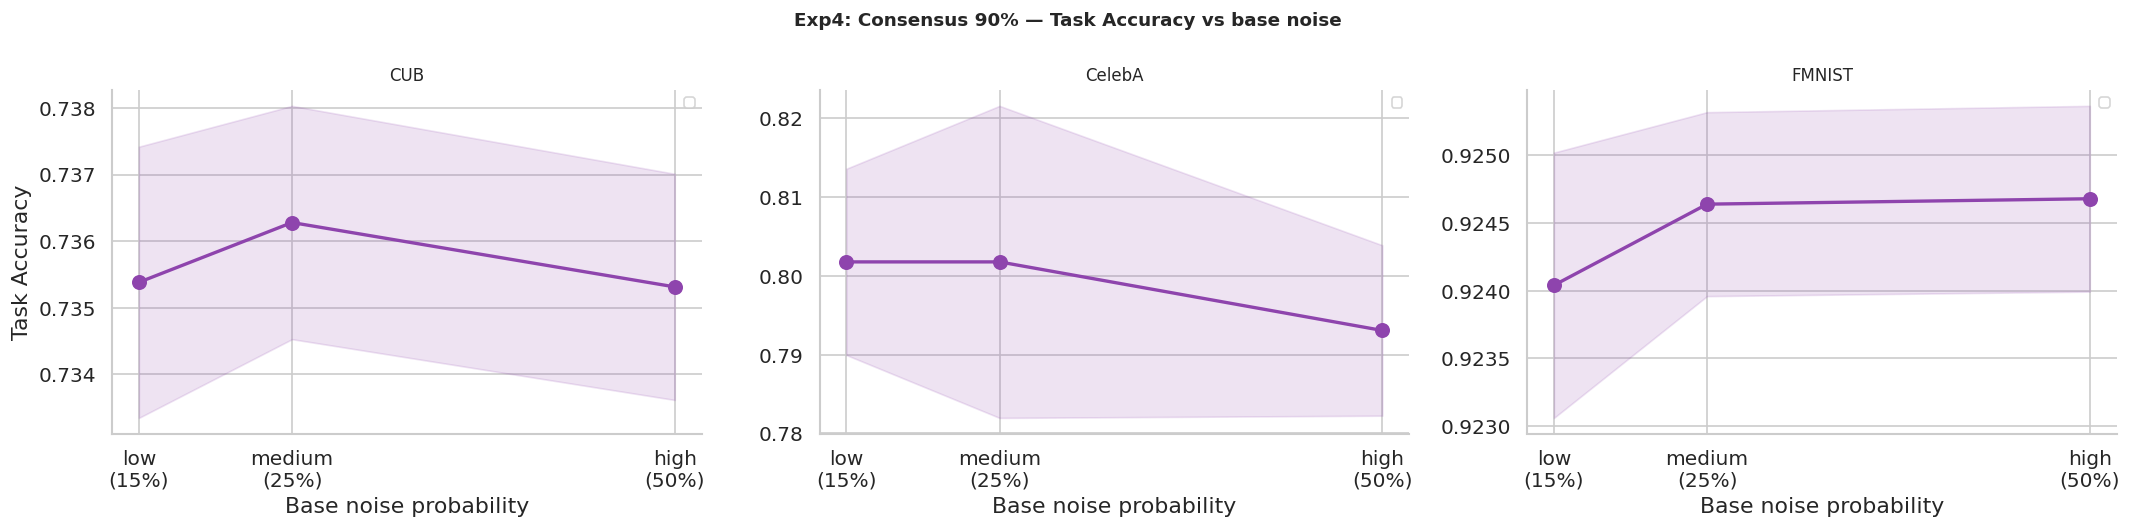

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


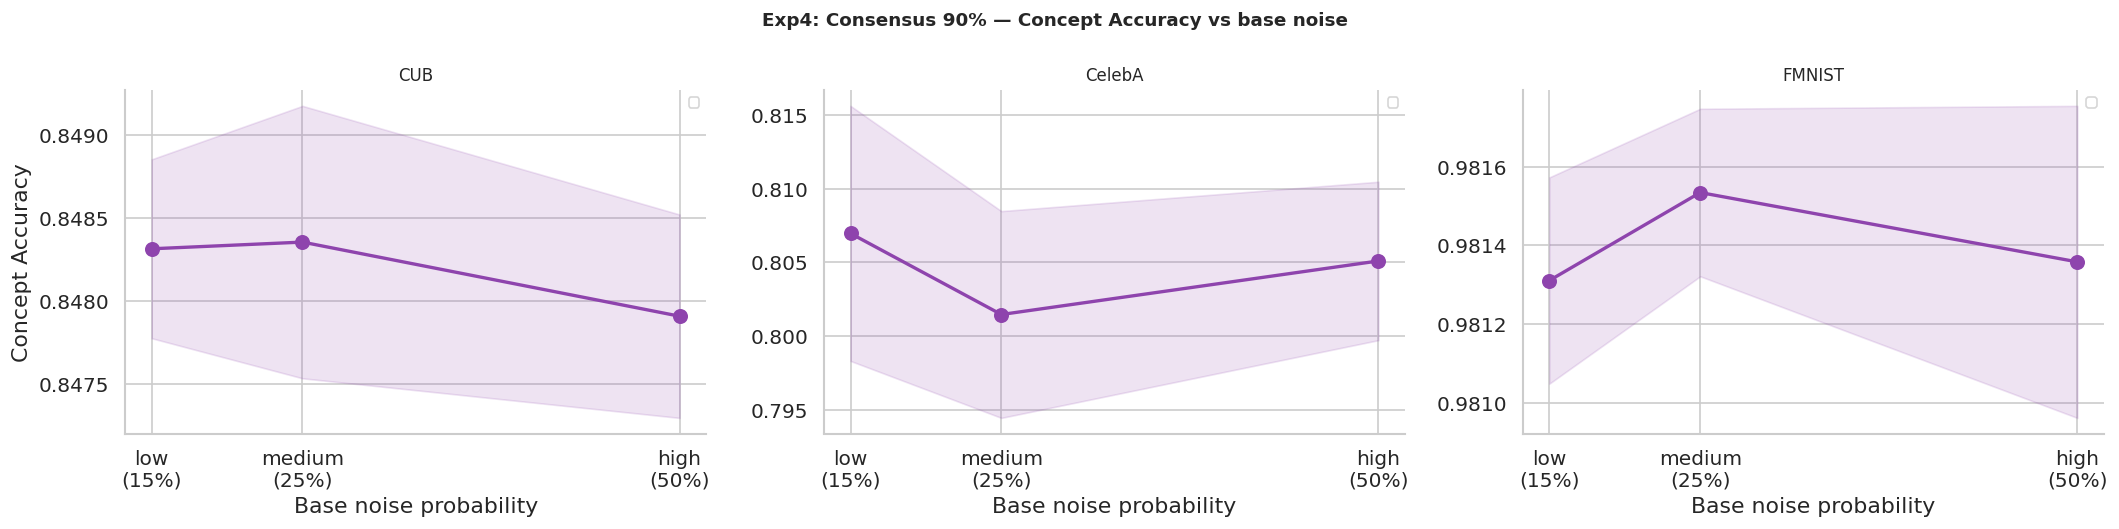

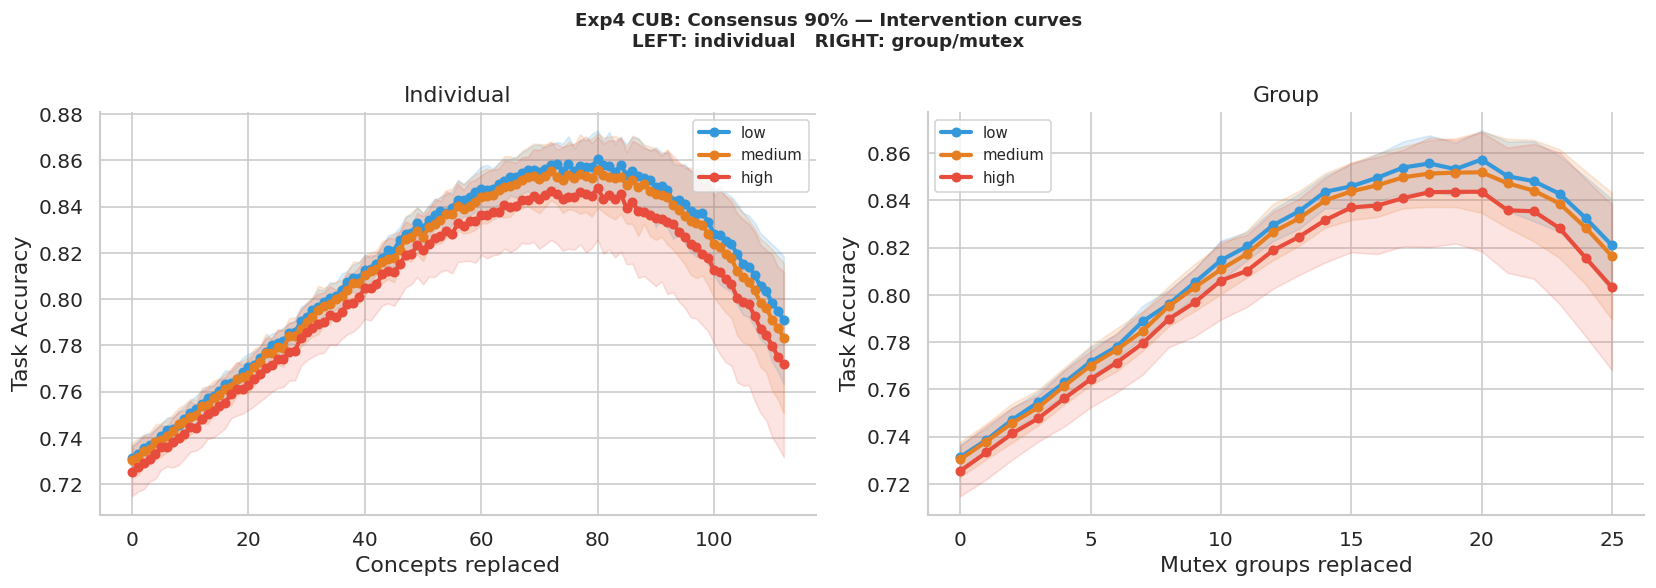

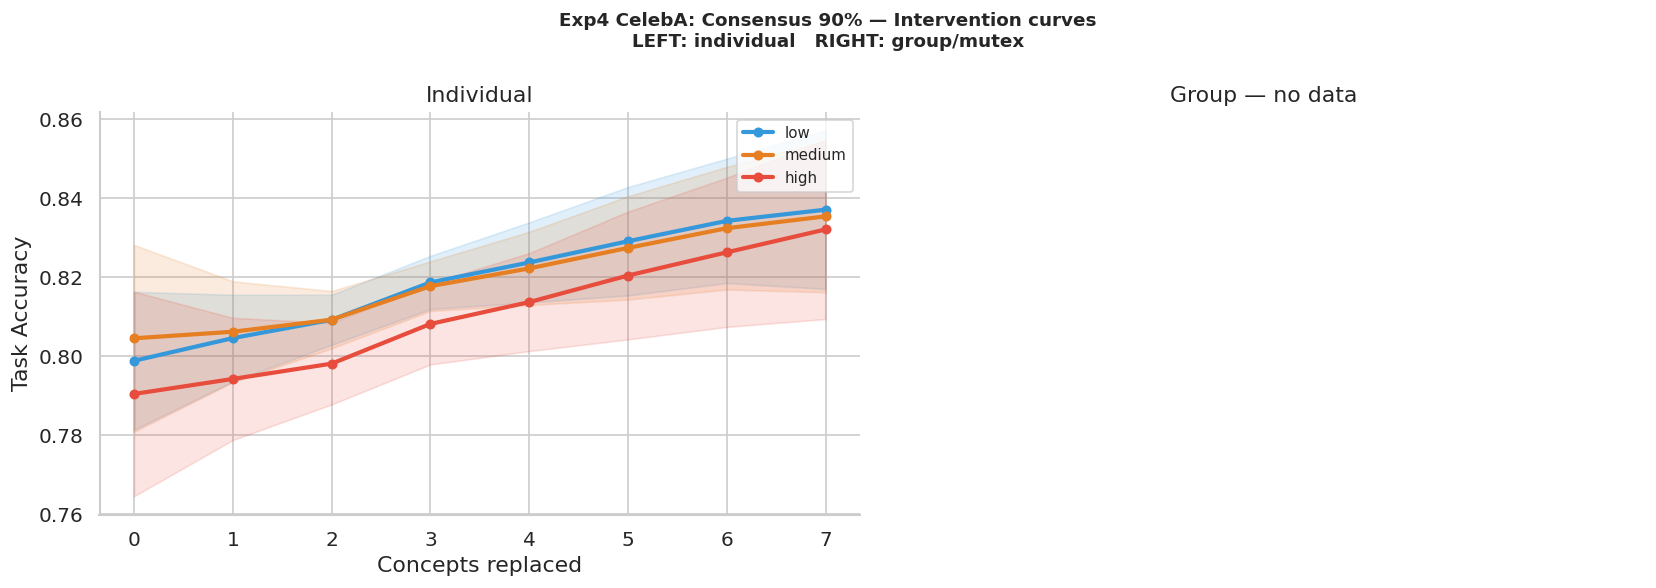

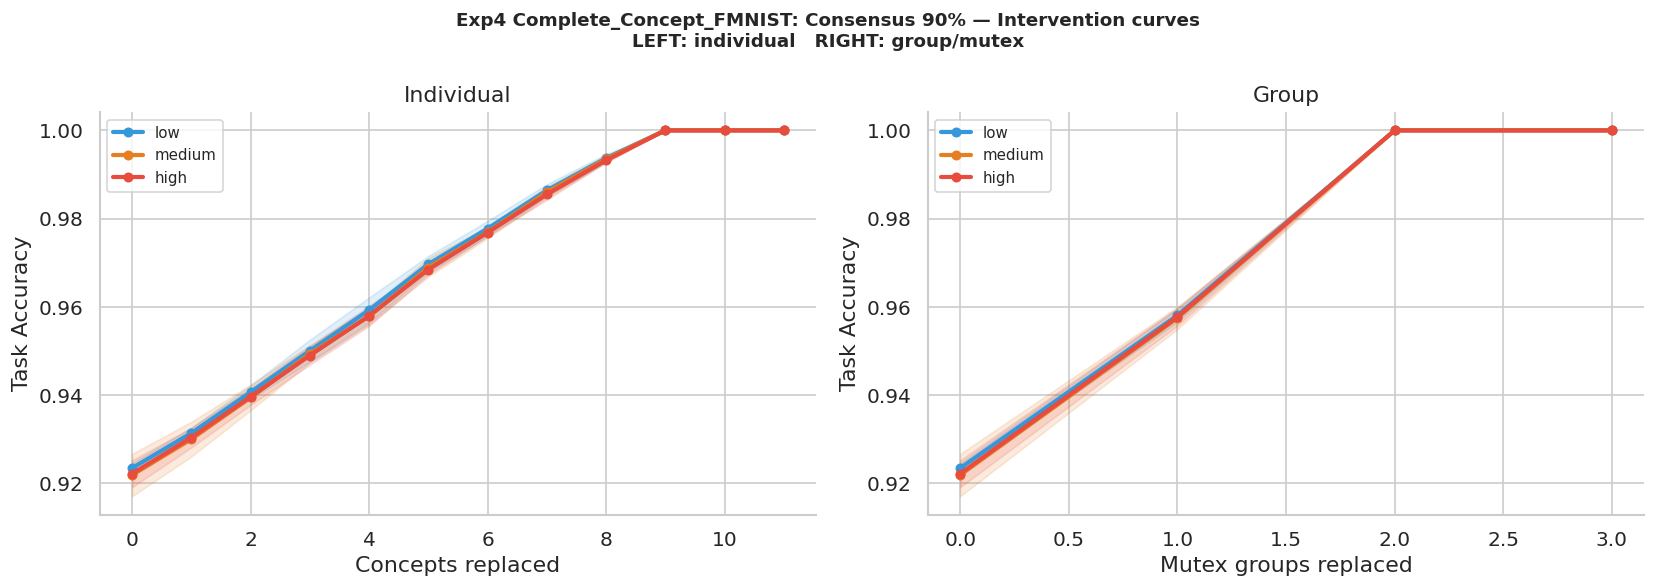

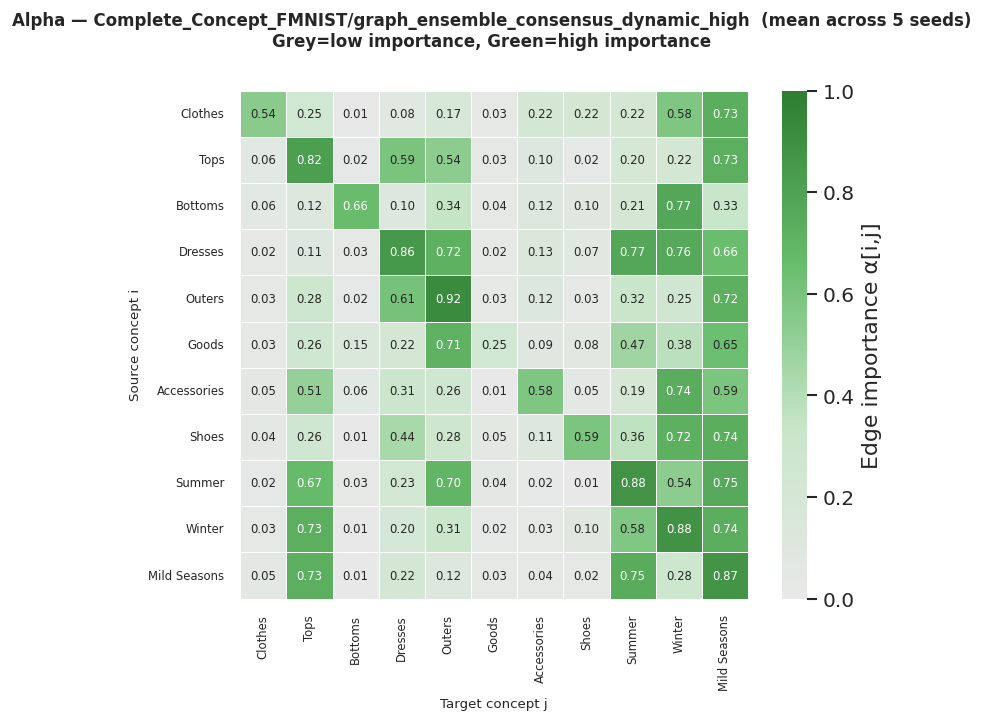

Complete_Concept_FMNIST/graph_ensemble_consensus_dynamic_high â€” top 5 important edges:
  Outers â†’ Outers: Î±=0.922
  Winter â†’ Winter: Î±=0.884
  Summer â†’ Summer: Î±=0.881
  Mild Seasons â†’ Mild Seasons: Î±=0.874
  Dresses â†’ Dresses: Î±=0.855


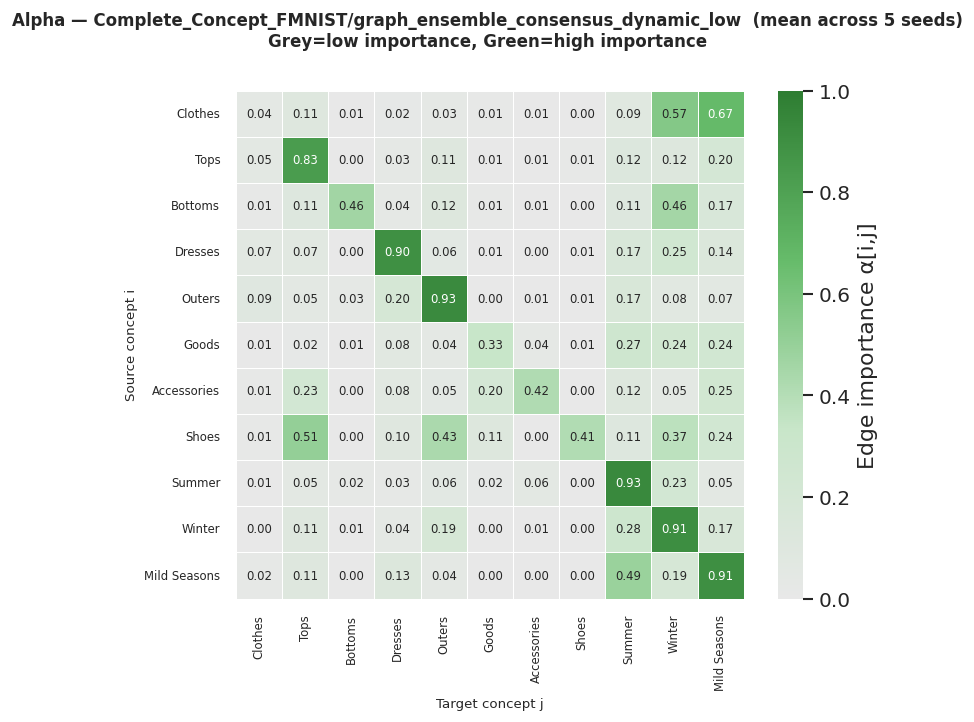

Complete_Concept_FMNIST/graph_ensemble_consensus_dynamic_low â€” top 5 important edges:
  Summer â†’ Summer: Î±=0.931
  Outers â†’ Outers: Î±=0.926
  Winter â†’ Winter: Î±=0.907
  Mild Seasons â†’ Mild Seasons: Î±=0.905
  Dresses â†’ Dresses: Î±=0.896


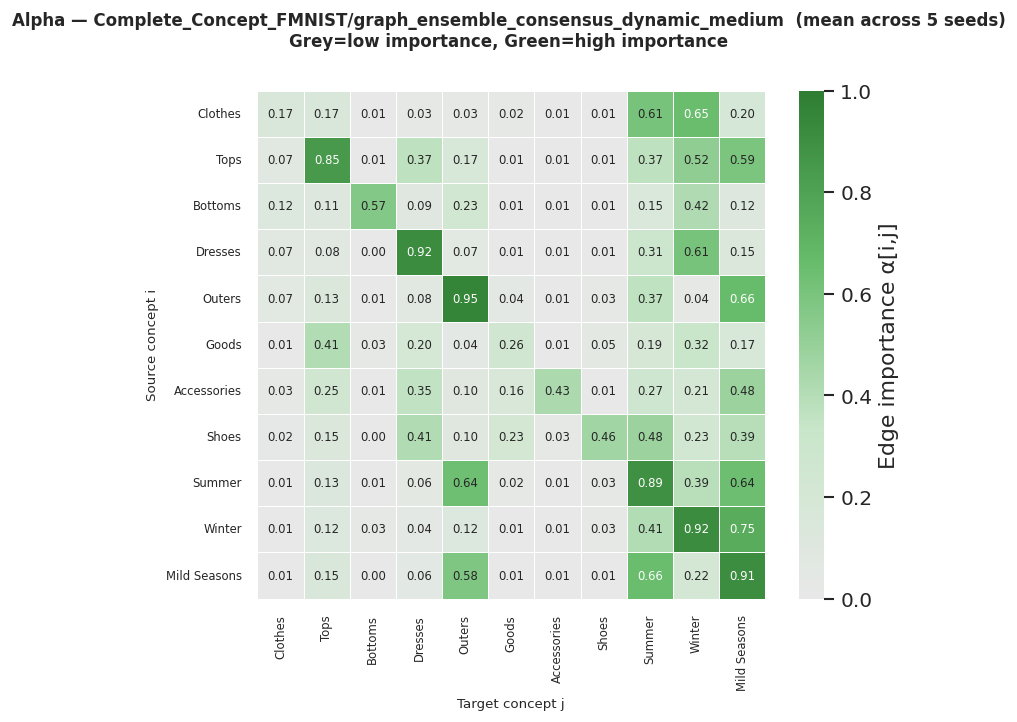

Complete_Concept_FMNIST/graph_ensemble_consensus_dynamic_medium â€” top 5 important edges:
  Outers â†’ Outers: Î±=0.953
  Winter â†’ Winter: Î±=0.921
  Dresses â†’ Dresses: Î±=0.918
  Mild Seasons â†’ Mild Seasons: Î±=0.911
  Summer â†’ Summer: Î±=0.895


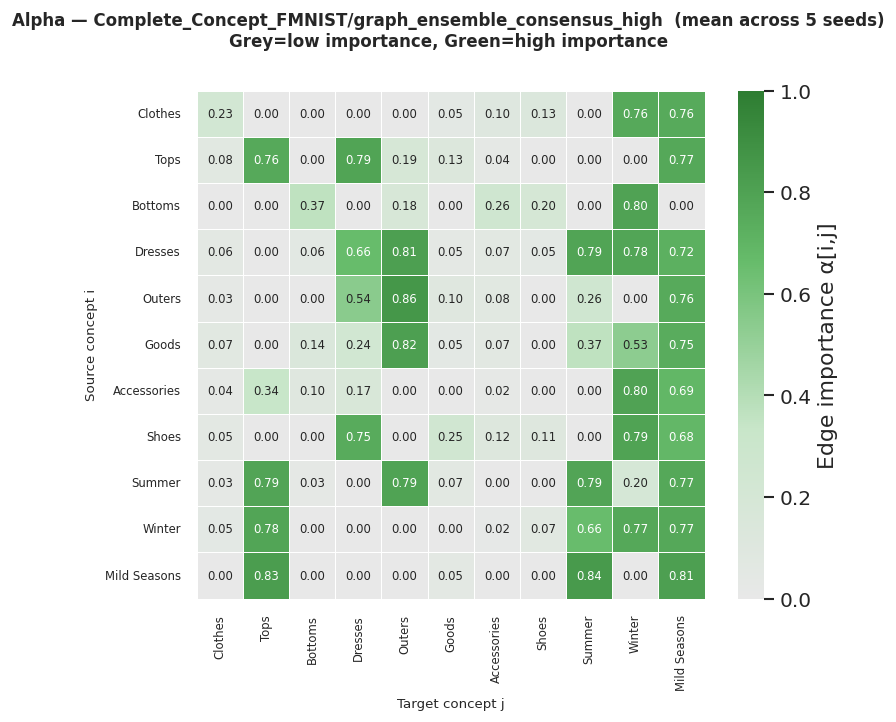

Complete_Concept_FMNIST/graph_ensemble_consensus_high â€” top 5 important edges:
  Outers â†’ Outers: Î±=0.861
  Mild Seasons â†’ Summer: Î±=0.842
  Mild Seasons â†’ Tops: Î±=0.828
  Goods â†’ Outers: Î±=0.816
  Mild Seasons â†’ Mild Seasons: Î±=0.813


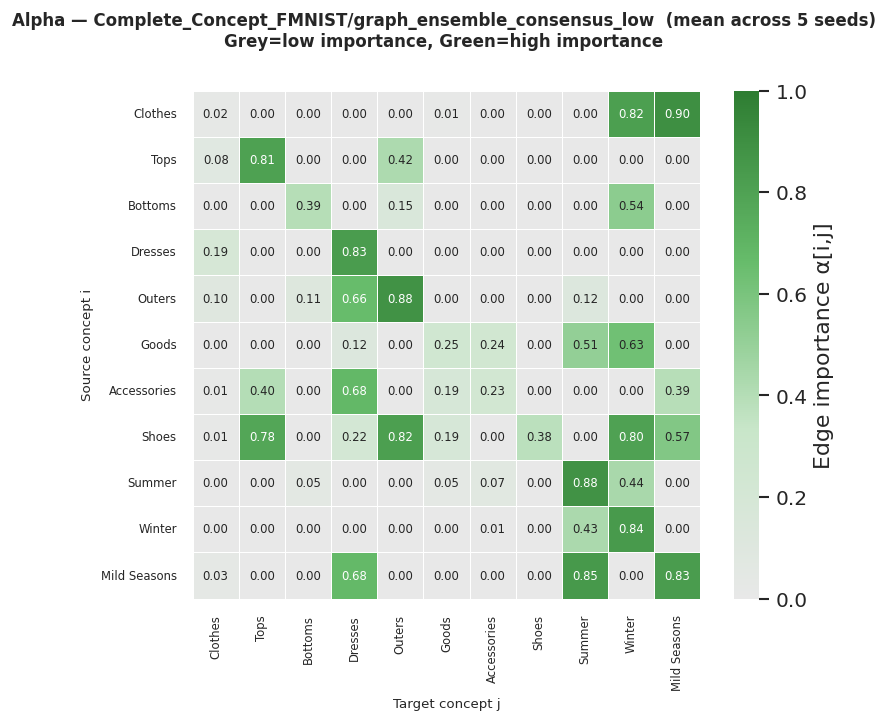

Complete_Concept_FMNIST/graph_ensemble_consensus_low â€” top 5 important edges:
  Clothes â†’ Mild Seasons: Î±=0.903
  Outers â†’ Outers: Î±=0.884
  Summer â†’ Summer: Î±=0.883
  Mild Seasons â†’ Summer: Î±=0.849
  Winter â†’ Winter: Î±=0.843


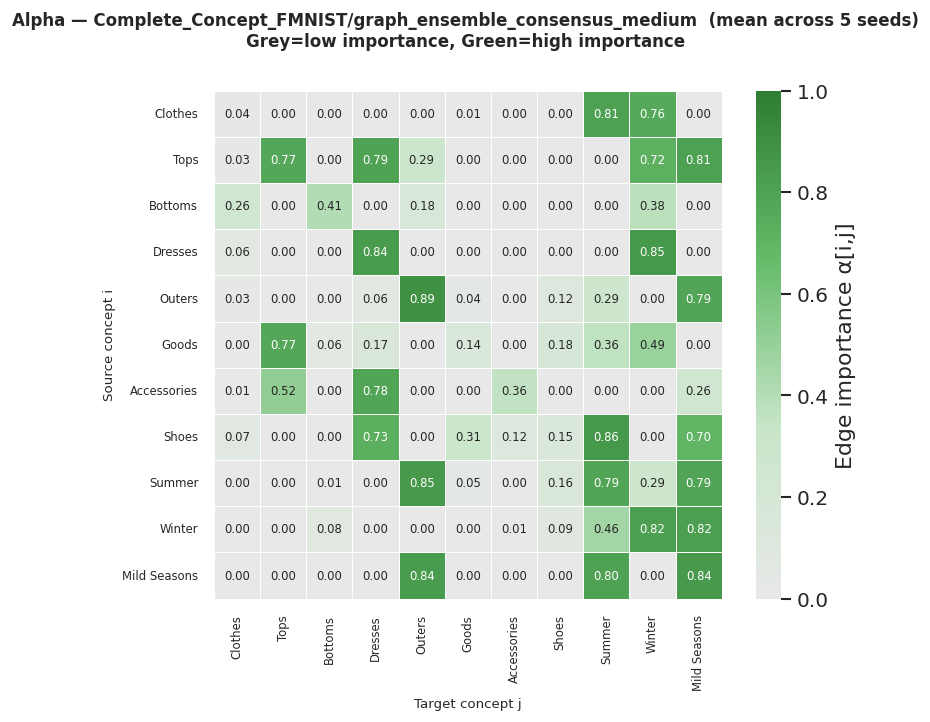

Complete_Concept_FMNIST/graph_ensemble_consensus_medium â€” top 5 important edges:
  Outers â†’ Outers: Î±=0.889
  Shoes â†’ Summer: Î±=0.855
  Dresses â†’ Winter: Î±=0.853
  Summer â†’ Outers: Î±=0.845
  Mild Seasons â†’ Mild Seasons: Î±=0.844


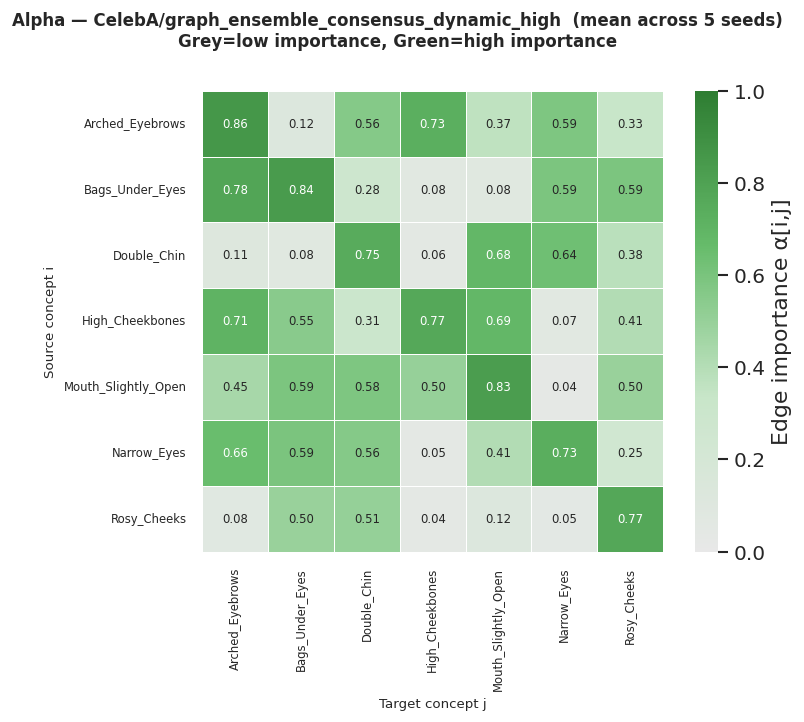

CelebA/graph_ensemble_consensus_dynamic_high â€” top 5 important edges:
  Arched_Eyebrows â†’ Arched_Eyebrows: Î±=0.861
  Bags_Under_Eyes â†’ Bags_Under_Eyes: Î±=0.839
  Mouth_Slightly_Open â†’ Mouth_Slightly_Open: Î±=0.826
  Bags_Under_Eyes â†’ Arched_Eyebrows: Î±=0.783
  Rosy_Cheeks â†’ Rosy_Cheeks: Î±=0.772


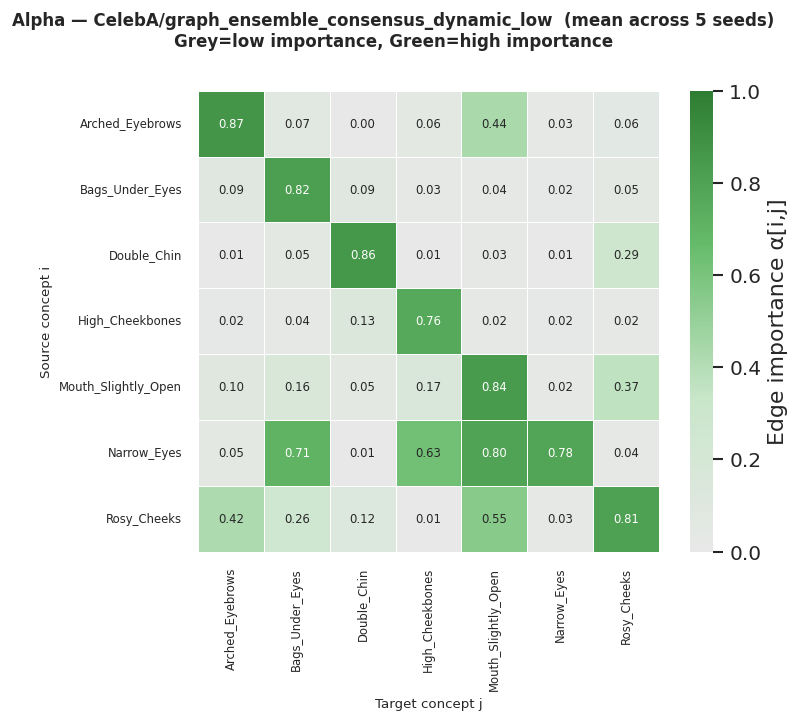

CelebA/graph_ensemble_consensus_dynamic_low â€” top 5 important edges:
  Arched_Eyebrows â†’ Arched_Eyebrows: Î±=0.870
  Double_Chin â†’ Double_Chin: Î±=0.860
  Mouth_Slightly_Open â†’ Mouth_Slightly_Open: Î±=0.841
  Bags_Under_Eyes â†’ Bags_Under_Eyes: Î±=0.824
  Rosy_Cheeks â†’ Rosy_Cheeks: Î±=0.809


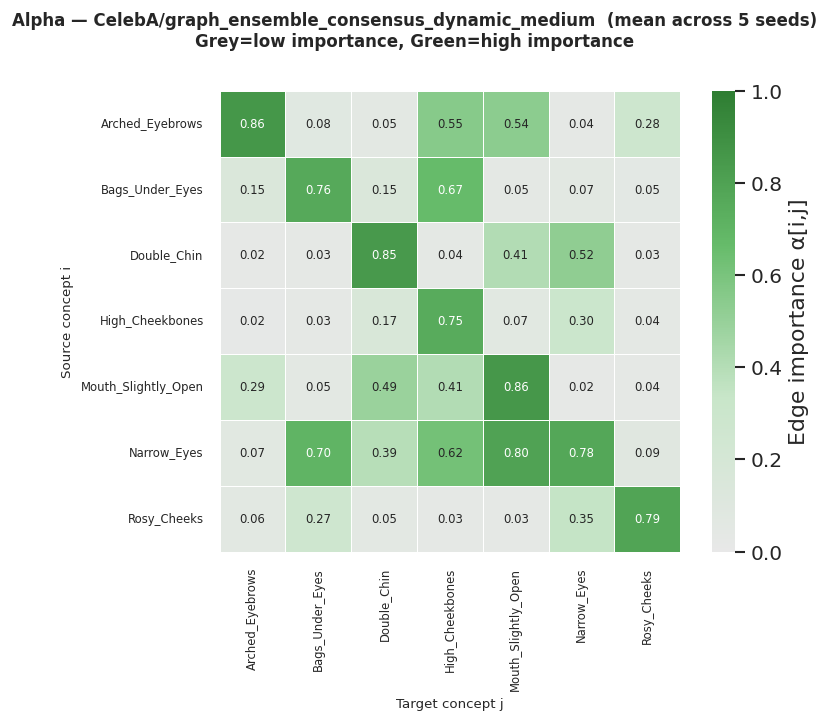

CelebA/graph_ensemble_consensus_dynamic_medium â€” top 5 important edges:
  Arched_Eyebrows â†’ Arched_Eyebrows: Î±=0.863
  Mouth_Slightly_Open â†’ Mouth_Slightly_Open: Î±=0.856
  Double_Chin â†’ Double_Chin: Î±=0.845
  Narrow_Eyes â†’ Mouth_Slightly_Open: Î±=0.799
  Rosy_Cheeks â†’ Rosy_Cheeks: Î±=0.790


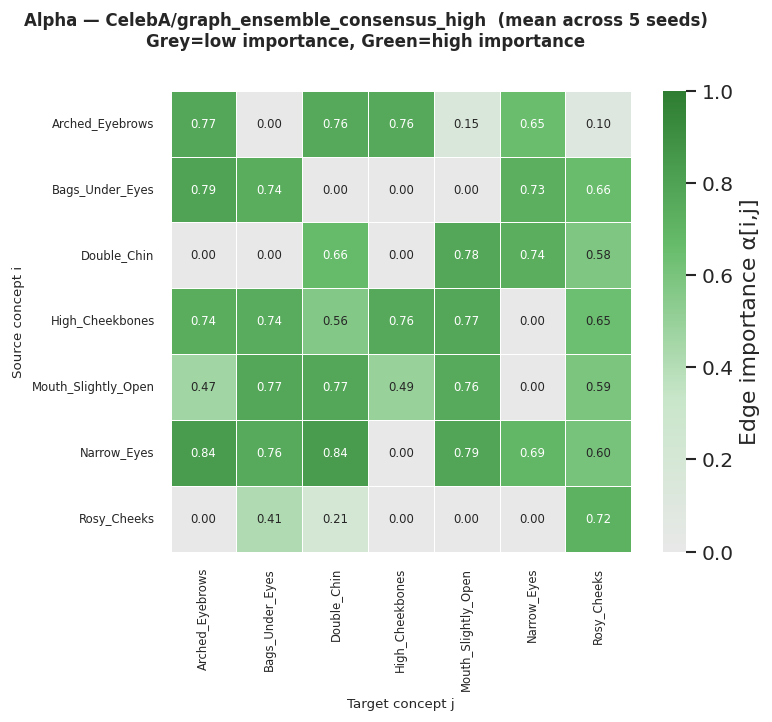

CelebA/graph_ensemble_consensus_high â€” top 5 important edges:
  Narrow_Eyes â†’ Arched_Eyebrows: Î±=0.839
  Narrow_Eyes â†’ Double_Chin: Î±=0.836
  Bags_Under_Eyes â†’ Arched_Eyebrows: Î±=0.794
  Narrow_Eyes â†’ Mouth_Slightly_Open: Î±=0.789
  Double_Chin â†’ Mouth_Slightly_Open: Î±=0.776


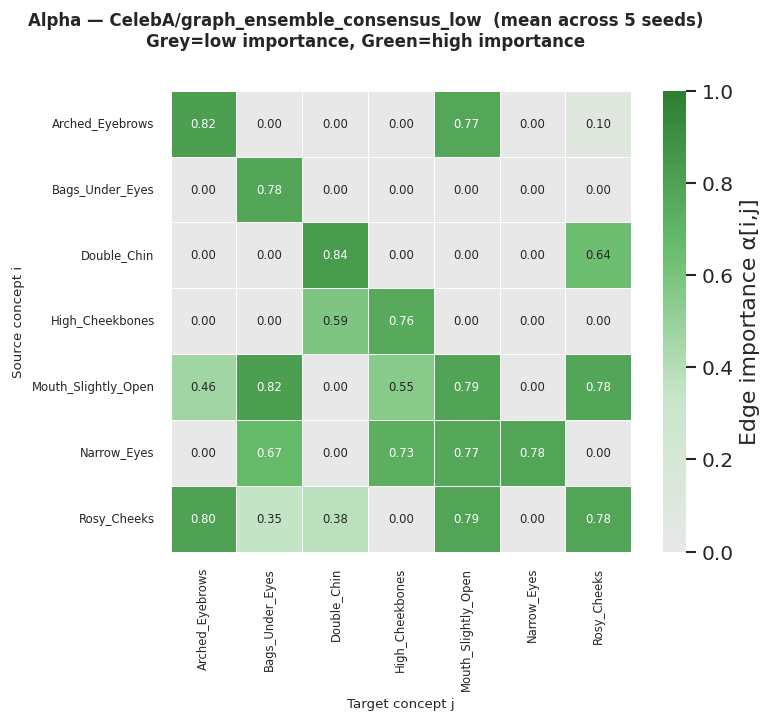

CelebA/graph_ensemble_consensus_low â€” top 5 important edges:
  Double_Chin â†’ Double_Chin: Î±=0.838
  Arched_Eyebrows â†’ Arched_Eyebrows: Î±=0.821
  Mouth_Slightly_Open â†’ Bags_Under_Eyes: Î±=0.820
  Rosy_Cheeks â†’ Arched_Eyebrows: Î±=0.802
  Mouth_Slightly_Open â†’ Mouth_Slightly_Open: Î±=0.791


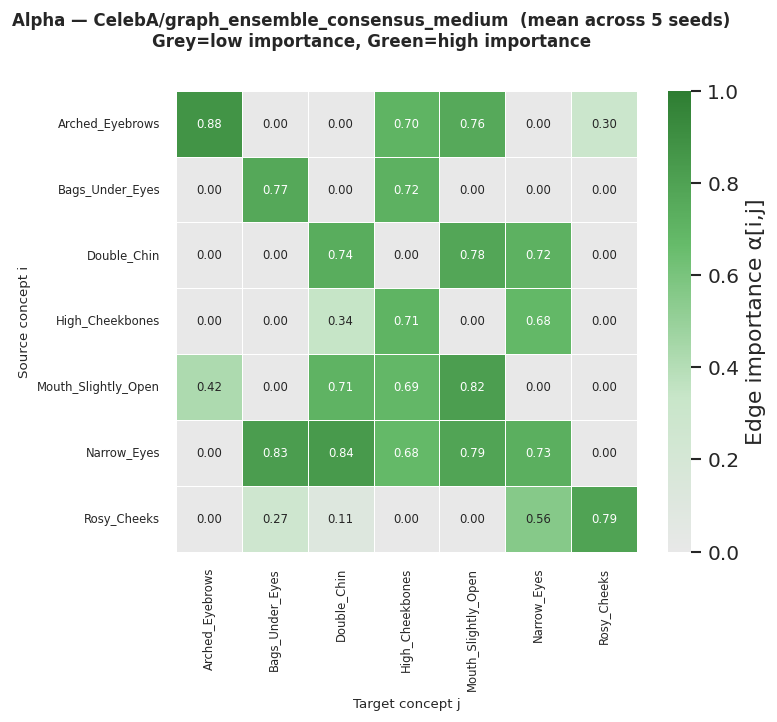

CelebA/graph_ensemble_consensus_medium â€” top 5 important edges:
  Arched_Eyebrows â†’ Arched_Eyebrows: Î±=0.876
  Narrow_Eyes â†’ Double_Chin: Î±=0.841
  Narrow_Eyes â†’ Bags_Under_Eyes: Î±=0.826
  Mouth_Slightly_Open â†’ Mouth_Slightly_Open: Î±=0.824
  Rosy_Cheeks â†’ Rosy_Cheeks: Î±=0.794


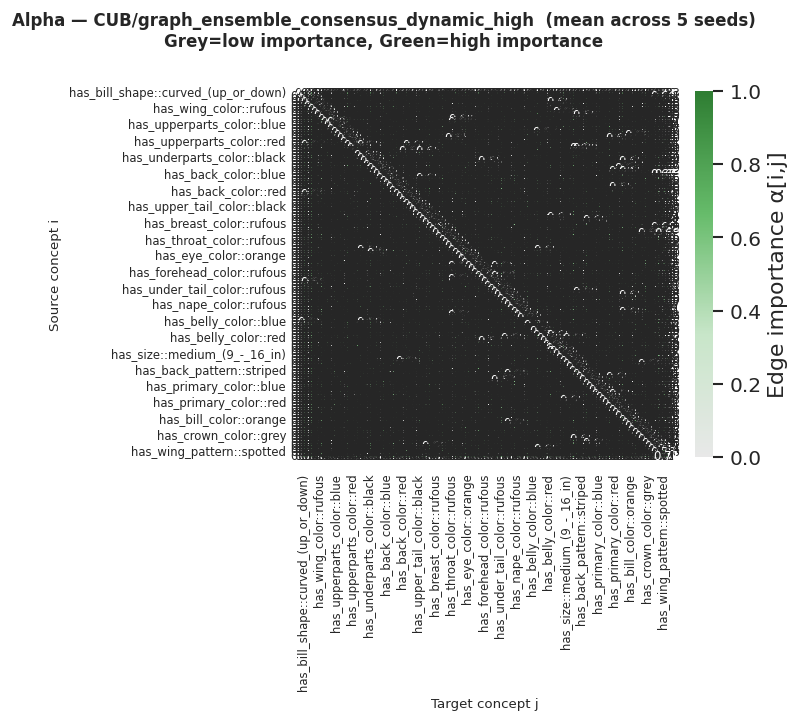

CUB/graph_ensemble_consensus_dynamic_high â€” top 5 important edges:
  has_wing_shape::rounded-wings â†’ has_wing_shape::rounded-wings: Î±=0.802
  has_upper_tail_color::black â†’ has_upper_tail_color::black: Î±=0.783
  has_tail_shape::rounded_tail â†’ has_tail_shape::rounded_tail: Î±=0.773
  has_breast_color::orange â†’ has_breast_color::orange: Î±=0.768
  has_throat_color::orange â†’ has_throat_color::orange: Î±=0.767


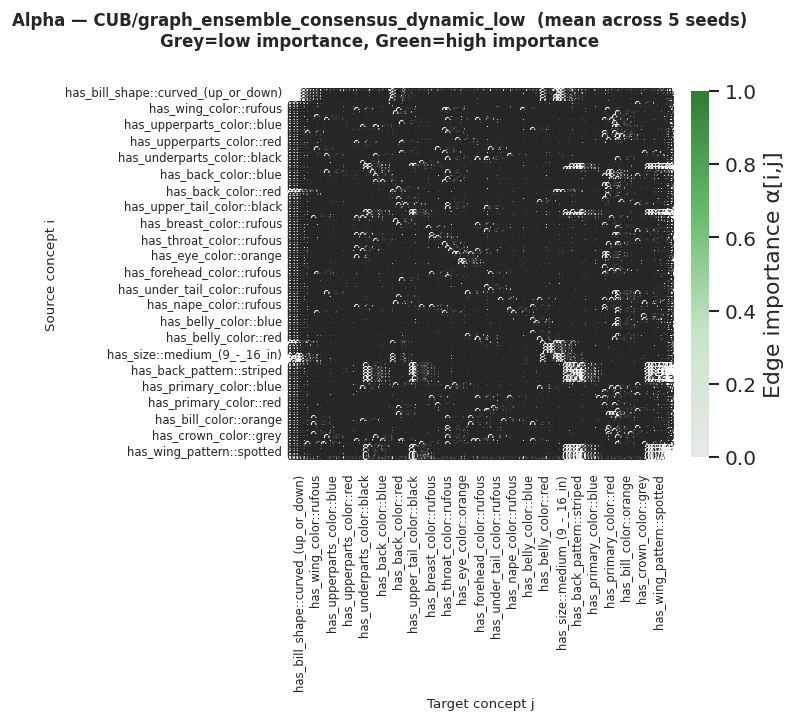

CUB/graph_ensemble_consensus_dynamic_low â€” top 5 important edges:
  has_size::very_large_(32_-_72_in) â†’ has_size::very_large_(32_-_72_in): Î±=0.840
  has_wing_shape::rounded-wings â†’ has_wing_shape::rounded-wings: Î±=0.829
  has_size::medium_(9_-_16_in) â†’ has_size::medium_(9_-_16_in): Î±=0.822
  has_tail_shape::rounded_tail â†’ has_tail_shape::rounded_tail: Î±=0.813
  has_bill_length::shorter_than_head â†’ has_bill_length::shorter_than_head: Î±=0.802


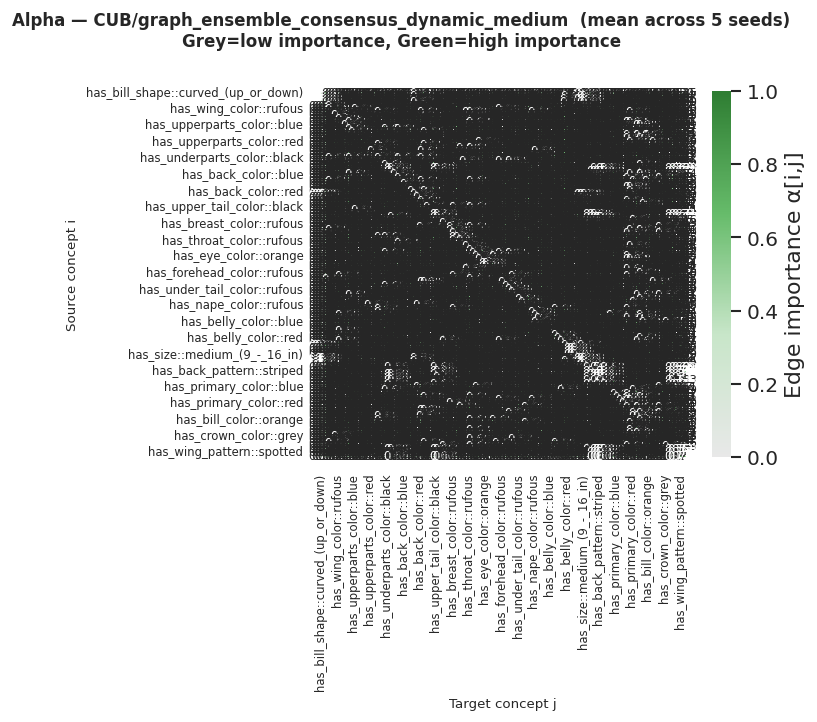

CUB/graph_ensemble_consensus_dynamic_medium â€” top 5 important edges:
  has_size::very_large_(32_-_72_in) â†’ has_size::very_large_(32_-_72_in): Î±=0.847
  has_wing_shape::rounded-wings â†’ has_wing_shape::rounded-wings: Î±=0.841
  has_tail_shape::rounded_tail â†’ has_tail_shape::rounded_tail: Î±=0.840
  has_size::medium_(9_-_16_in) â†’ has_size::medium_(9_-_16_in): Î±=0.834
  has_size::large_(16_-_32_in) â†’ has_size::large_(16_-_32_in): Î±=0.808


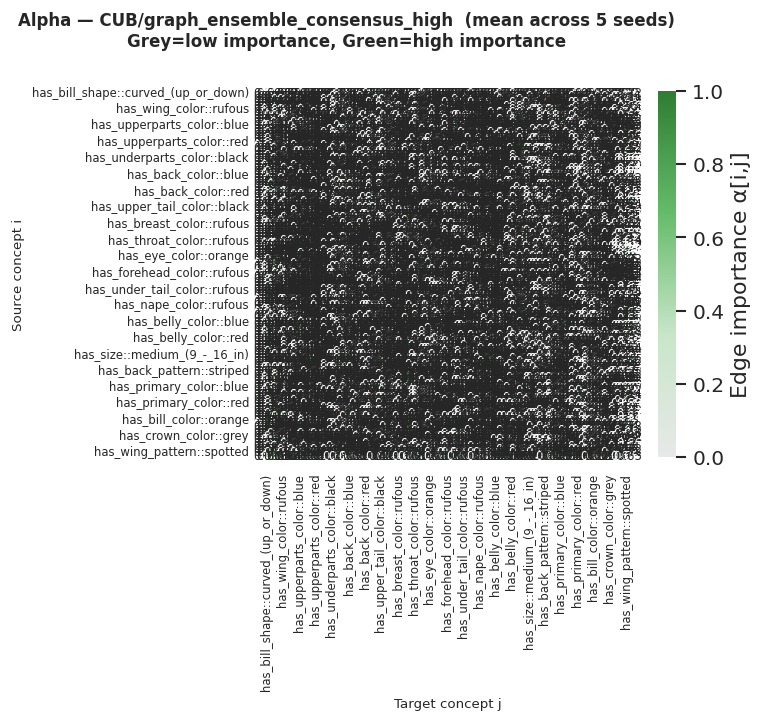

CUB/graph_ensemble_consensus_high â€” top 5 important edges:
  has_breast_color::rufous â†’ has_bill_shape::spatulate: Î±=0.710
  has_back_color::blue â†’ has_wing_pattern::spotted: Î±=0.708
  has_under_tail_color::rufous â†’ has_back_pattern::striped: Î±=0.707
  has_breast_color::blue â†’ has_tail_pattern::multi-colored: Î±=0.702
  has_breast_pattern::striped â†’ has_leg_color::orange: Î±=0.701


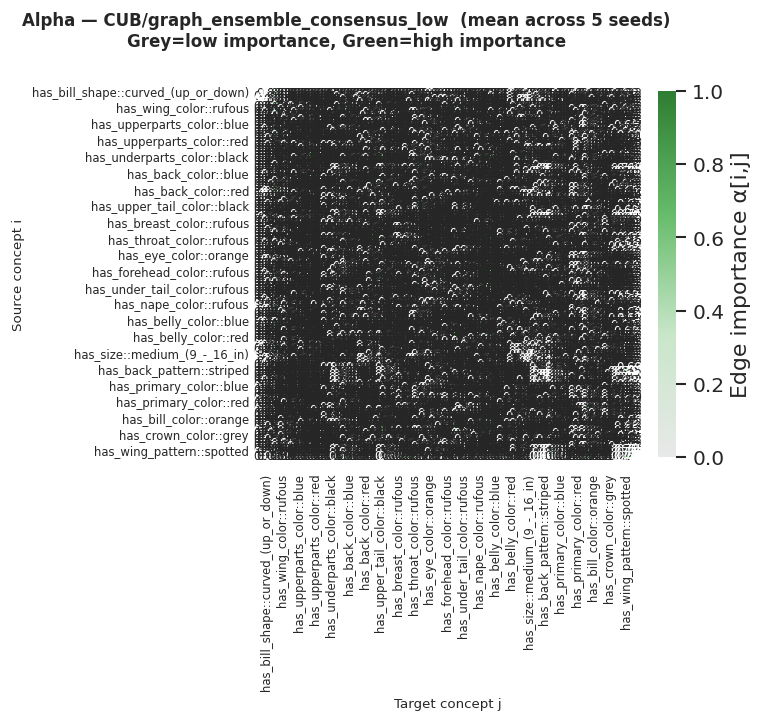

CUB/graph_ensemble_consensus_low â€” top 5 important edges:
  has_size::very_large_(32_-_72_in) â†’ has_size::large_(16_-_32_in): Î±=0.763
  has_bill_shape::spatulate â†’ has_wing_shape::rounded-wings: Î±=0.750
  has_bill_shape::all-purpose â†’ has_wing_shape::rounded-wings: Î±=0.745
  has_size::medium_(9_-_16_in) â†’ has_size::medium_(9_-_16_in): Î±=0.743
  has_breast_pattern::striped â†’ has_wing_pattern::spotted: Î±=0.742


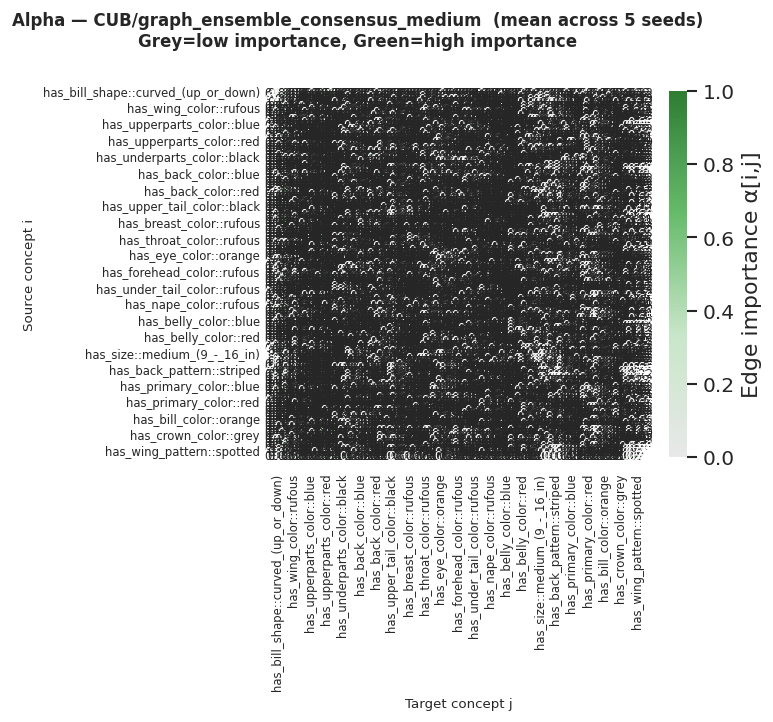

CUB/graph_ensemble_consensus_medium â€” top 5 important edges:
  has_wing_shape::rounded-wings â†’ has_wing_shape::rounded-wings: Î±=0.741
  has_bill_shape::all-purpose â†’ has_wing_shape::rounded-wings: Î±=0.740
  has_size::very_large_(32_-_72_in) â†’ has_size::large_(16_-_32_in): Î±=0.737
  has_breast_pattern::striped â†’ has_wing_pattern::spotted: Î±=0.727
  has_bill_shape::curved_(up_or_down) â†’ has_bill_shape::spatulate: Î±=0.725


In [5]:
if len(exp4_df) == 0:
    print('No Exp4 data yet.')
    print('Step 1: python generate_consensus_expert_graphs.py --dataset cfmnist --consensus 0.90')
    print('Step 2: bash server_scripts/mcream_experiment/submit_graph_ensemble_consensus.sh')
else:
    lnum = {'low': 0.15, 'medium': 0.25, 'high': 0.50}
    KEY  = ['test_task_accuracy', 'test_concept_accuracy', 'CCI', 'PFI_concept_importance', 'PFI_side_importance', 'alpha_mean', 'alpha_sparsity']
    av   = [c for c in KEY if c in exp4_df.columns]

    # â”€â”€ Summary table per dataset â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    for ds in sorted(exp4_df['dataset'].unique()):
        sub   = exp4_df[exp4_df['dataset']==ds]
        means = sub.groupby('noise_level')[av].mean()
        stds  = sub.groupby('noise_level')[av].std()
        sm    = pd.DataFrame({c: means[c].map('{:.4f}'.format)+' Â± '+stds[c].map('{:.4f}'.format) for c in av})
        print(f'=== Exp4: {ds} â€” Consensus 90% + shared alpha ===')
        display(sm)

    # â”€â”€ Accuracy vs noise level â€” one plot per dataset â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    datasets_exp4 = sorted(exp4_df['dataset'].unique())
    for metric, ylabel in [('test_task_accuracy','Task Accuracy'), ('test_concept_accuracy','Concept Accuracy')]:
        if metric not in exp4_df.columns: continue
        fig, axes = plt.subplots(1, len(datasets_exp4), figsize=(6*len(datasets_exp4), 4.5), sharey=False)
        if not hasattr(axes, '__len__'): axes = [axes]
        fig.suptitle(f'Exp4: Consensus 90% â€” {ylabel} vs base noise', fontsize=11, fontweight='bold')
        for ax, ds in zip(axes, datasets_exp4):
            d = exp4_df[exp4_df['dataset']==ds].copy()
            d['noise_prob'] = d['noise_level'].map(lnum)
            agg = d.groupby('noise_prob')[metric].agg(['mean','std']).reset_index()
            ax.plot(agg['noise_prob'], agg['mean'], color='#8e44ad', marker='o', markersize=8, lw=2)
            ax.fill_between(agg['noise_prob'], agg['mean']-agg['std'], agg['mean']+agg['std'], alpha=0.15, color='#8e44ad')
            if ds == 'Complete_Concept_FMNIST' and len(gt_df) > 0 and metric in gt_df.columns:
                v = gt_df[metric].mean()
                ax.axhline(v, color='black', lw=2, ls='--', label=f'GT CREAM: {v:.4f}')
            ax.set_title(ds.replace('Complete_Concept_',''), fontsize=10)
            ax.set_xlabel('Base noise probability')
            ax.set_ylabel(ylabel if ax is axes[0] else '')
            ax.set_xticks([0.15, 0.25, 0.50]); ax.set_xticklabels(['low\n(15%)', 'medium\n(25%)', 'high\n(50%)'])
            ax.legend(fontsize=8)
        plt.tight_layout(); plt.savefig(f'exp4_{metric}.png', dpi=150, bbox_inches='tight'); plt.show()

    # â”€â”€ Intervention curves â€” per dataset â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    if len(exp4_interv) > 0:
        has_group = 'group_interventions' in exp4_interv.columns
        for ds in sorted(exp4_interv['dataset'].unique()):
            ds_iv     = exp4_interv[exp4_interv['dataset']==ds]
            sub_indiv = ds_iv[ds_iv['group_interventions']==False] if has_group else ds_iv
            sub_group = ds_iv[ds_iv['group_interventions']==True]  if has_group else pd.DataFrame()

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(f'Exp4 {ds}: Consensus 90% â€” Intervention curves\n'
                         f'LEFT: individual   RIGHT: group/mutex',
                         fontsize=11, fontweight='bold')
            for ax, src, xlabel, title in [
                (axes[0], sub_indiv, 'Concepts replaced',   'Individual'),
                (axes[1], sub_group, 'Mutex groups replaced', 'Group'),
            ]:
                if src.empty: ax.set_title(f'{title} â€” no data'); ax.axis('off'); continue
                for level in LEVELS:
                    lv = src[src['exp_name'].str.contains(level)]
                    if lv.empty: continue
                    agg = lv.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                    col = LEVEL_COLOR[level]
                    ax.plot(agg['num_interventions'], agg['mean'], color=col, lw=2.5, marker='o', markersize=5, label=level)
                    ax.fill_between(agg['num_interventions'], agg['mean']-agg['std'], agg['mean']+agg['std'], alpha=0.15, color=col)
                ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel('Task Accuracy'); ax.legend(fontsize=9)
            plt.tight_layout()
            safe_ds = ds.replace(' ','_')
            plt.savefig(f'exp4_interventions_{safe_ds}.png', dpi=150, bbox_inches='tight'); plt.show()

    # â”€â”€ Alpha heatmaps â€” per dataset Ã— level â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    if exp4_alpha:
        for exp_key, seed_alphas in exp4_alpha.items():
            seeds   = sorted(seed_alphas.keys())
            stacked = np.stack([seed_alphas[s].values for s in seeds], axis=0)
            mean_df = pd.DataFrame(stacked.mean(0), index=seed_alphas[seeds[0]].index,
                                   columns=seed_alphas[seeds[0]].columns)
            fig, ax = plt.subplots(figsize=(7, 6))
            fig.suptitle(f'Alpha â€” {exp_key}  (mean across {len(seeds)} seeds)\n'
                         f'Grey=low importance, Green=high importance',
                         fontsize=10, fontweight='bold')
            plot_alpha(mean_df, '', ax)
            plt.tight_layout()
            plt.savefig(f'alpha_{exp_key.replace("/","_")}.png', dpi=150, bbox_inches='tight'); plt.show()
            flat = mean_df.stack().sort_values(ascending=False)
            print(f'{exp_key} â€” top 5 important edges:')
            for (src, tgt), val in flat.head(5).items():
                print(f'  {src} â†’ {tgt}: Î±={val:.3f}')

---
# Experiment 5 â€” Dynamic Consensus Graphs + Shared Alpha Matrix

Same setup as Exp4 but expert graphs are **regenerated every `refresh_every` epochs** during training.
Each refresh samples new consensus graphs with the same p_base but new random edge flips â†’ Î± must
learn which edges are *consistently* important across changing graph topologies.

**Key difference vs Exp4 (static):**
- Exp4: fixed noisy graphs â†’ Î± can overfit to one specific noise realisation
- Exp5: graphs refresh every 5 epochs â†’ Î± is forced to generalise across noise realisations

**Folder names:** `graph_ensemble_consensus_dynamic_{low|medium|high}`

**What to look for:**
- Does dynamic training improve task accuracy vs static Exp4 (especially at high noise)?
- Is Î± more aligned to GT edges (higher precision/recall)?
- Are intervention curves steeper (more useful concepts)?

In [ ]:
import re as _re5

def load_dynamic_consensus_results(root):
    """Load Exp5: dynamic consensus. Folder: graph_ensemble_consensus_dynamic_{level}"""
    rows = []
    for ds in list(DATASET_CONFIG.keys()):
        ens_dir = root / ds / 'train_cbm' / 'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for exp_dir in sorted(ens_dir.iterdir()):
            name = exp_dir.name
            m = _re5.match(r'graph_ensemble_consensus_dynamic_(low|medium|high)$', name)
            if not m: continue
            level = m.group(1)
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed = int(seed_dir.parent.parent.name.split('_')[1])
                for csv_f in sorted(seed_dir.glob('*.csv')):
                    if any(x in csv_f.name for x in ['perc_','_set_','intervention','exogenous','alpha']): continue
                    try:
                        df = pd.read_csv(csv_f)
                        df['dataset'] = ds; df['noise_level'] = level; df['seed'] = seed
                        rows.append(df)
                    except: pass
    if not rows: print('No Exp5 dynamic consensus results yet.'); return pd.DataFrame()
    df = pd.concat(rows, ignore_index=True)
    print(f'Exp5 loaded: {len(df)} rows | datasets={sorted(df.dataset.unique())} | levels={sorted(df.noise_level.unique())}')
    return df

exp5_df     = load_dynamic_consensus_results(EXPERIMENTS_ROOT)
exp5_interv = load_interventions(EXPERIMENTS_ROOT,
                                  exp_name_filter=['graph_ensemble_consensus_dynamic'],
                                  datasets=list(DATASET_CONFIG.keys()))
exp5_alpha  = load_alpha_matrices(EXPERIMENTS_ROOT,
                                   exp_name_filter=['graph_ensemble_consensus_dynamic'])

In [ ]:
if len(exp5_df) == 0:
    print('No Exp5 data yet.')
    print('Run: bash server_scripts/mcream_experiment/submit_graph_ensemble_consensus_dynamic.sh')
else:
    lnum = {'low': 0.15, 'medium': 0.25, 'high': 0.50}
    KEY  = ['test_task_accuracy', 'test_concept_accuracy', 'CCI', 'PFI_concept_importance', 'PFI_side_importance', 'alpha_mean', 'alpha_sparsity']
    av   = [c for c in KEY if c in exp5_df.columns]

    # â”€â”€ Summary table per dataset â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    for ds in sorted(exp5_df['dataset'].unique()):
        sub   = exp5_df[exp5_df['dataset']==ds]
        means = sub.groupby('noise_level')[av].mean()
        stds  = sub.groupby('noise_level')[av].std()
        sm    = pd.DataFrame({c: means[c].map('{:.4f}'.format)+' Â± '+stds[c].map('{:.4f}'.format) for c in av})
        print(f'=== Exp5: {ds} â€” Dynamic Consensus (refresh every 5 epochs) ===')
        display(sm)

    # â”€â”€ Static vs Dynamic comparison table â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    if len(exp4_df) > 0:
        print('\n=== Exp4 (static) vs Exp5 (dynamic) â€” task accuracy ===')
        for ds in sorted(set(exp4_df['dataset'].unique()) & set(exp5_df['dataset'].unique())):
            cmp_rows = []
            for level in LEVELS:
                s4 = exp4_df[(exp4_df['dataset']==ds) & (exp4_df['noise_level']==level)]
                s5 = exp5_df[(exp5_df['dataset']==ds) & (exp5_df['noise_level']==level)]
                m4 = f"{s4['test_task_accuracy'].mean():.4f} Â± {s4['test_task_accuracy'].std():.4f}" if not s4.empty and 'test_task_accuracy' in s4.columns else 'â€”'
                m5 = f"{s5['test_task_accuracy'].mean():.4f} Â± {s5['test_task_accuracy'].std():.4f}" if not s5.empty and 'test_task_accuracy' in s5.columns else 'â€”'
                cmp_rows.append({'noise_level': level, 'static (Exp4)': m4, 'dynamic (Exp5)': m5})
            if cmp_rows:
                print(f'\n{ds}:')
                display(pd.DataFrame(cmp_rows).set_index('noise_level'))

    # â”€â”€ Accuracy vs noise level â€” dynamic + static overlay â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    datasets_exp5 = sorted(exp5_df['dataset'].unique())
    for metric, ylabel in [('test_task_accuracy','Task Accuracy'), ('test_concept_accuracy','Concept Accuracy')]:
        if metric not in exp5_df.columns: continue
        fig, axes = plt.subplots(1, len(datasets_exp5), figsize=(6*len(datasets_exp5), 4.5), sharey=False)
        if not hasattr(axes, '__len__'): axes = [axes]
        fig.suptitle(f'Exp5: Dynamic Consensus â€” {ylabel} vs base noise\n'
                     f'(dashed purple = Exp4 static for comparison)',
                     fontsize=11, fontweight='bold')
        for ax, ds in zip(axes, datasets_exp5):
            d5 = exp5_df[exp5_df['dataset']==ds].copy()
            d5['noise_prob'] = d5['noise_level'].map(lnum)
            agg5 = d5.groupby('noise_prob')[metric].agg(['mean','std']).reset_index()
            ax.plot(agg5['noise_prob'], agg5['mean'], color='#27ae60', marker='o', markersize=8, lw=2.5, label='dynamic (Exp5)')
            ax.fill_between(agg5['noise_prob'], agg5['mean']-agg5['std'], agg5['mean']+agg5['std'], alpha=0.15, color='#27ae60')
            if len(exp4_df) > 0 and metric in exp4_df.columns:
                d4 = exp4_df[exp4_df['dataset']==ds].copy()
                d4['noise_prob'] = d4['noise_level'].map(lnum)
                agg4 = d4.groupby('noise_prob')[metric].agg(['mean','std']).reset_index()
                ax.plot(agg4['noise_prob'], agg4['mean'], color='#8e44ad', marker='s', markersize=6, lw=2, ls='--', label='static (Exp4)')
            if ds == 'Complete_Concept_FMNIST' and len(gt_df) > 0 and metric in gt_df.columns:
                v = gt_df[metric].mean()
                ax.axhline(v, color='black', lw=2, ls=':', label=f'GT CREAM: {v:.4f}')
            ax.set_title(ds.replace('Complete_Concept_',''), fontsize=10)
            ax.set_xlabel('Base noise probability')
            ax.set_ylabel(ylabel if ax is axes[0] else '')
            ax.set_xticks([0.15, 0.25, 0.50]); ax.set_xticklabels(['low\n(15%)', 'medium\n(25%)', 'high\n(50%)'])
            ax.legend(fontsize=8)
        plt.tight_layout(); plt.savefig(f'exp5_{metric}.png', dpi=150, bbox_inches='tight'); plt.show()

    # â”€â”€ Intervention curves â€” per dataset, dynamic vs static overlaid â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    if len(exp5_interv) > 0:
        has_g5 = 'group_interventions' in exp5_interv.columns
        for ds in sorted(exp5_interv['dataset'].unique()):
            ds_iv5    = exp5_interv[exp5_interv['dataset']==ds]
            sub_indiv = ds_iv5[ds_iv5['group_interventions']==False] if has_g5 else ds_iv5
            sub_group = ds_iv5[ds_iv5['group_interventions']==True]  if has_g5 else pd.DataFrame()

            fig, axes = plt.subplots(2, len(LEVELS), figsize=(6*len(LEVELS), 9), sharey='row')
            fig.suptitle(f'Exp5 {ds}: Dynamic Consensus â€” Intervention curves\n'
                         f'TOP: individual   BOTTOM: group/mutex\n'
                         f'solid=dynamic(Exp5)  dashed=static(Exp4)',
                         fontsize=11, fontweight='bold')

            for col_idx, level in enumerate(LEVELS):
                col = LEVEL_COLOR[level]

                # TOP: individual
                ax_top = axes[0][col_idx]
                lv5 = sub_indiv[sub_indiv['exp_name'].str.contains(level)]
                if not lv5.empty:
                    agg = lv5.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                    ax_top.plot(agg['num_interventions'], agg['mean'], color=col, lw=2.5, marker='o', markersize=5, label='dynamic')
                    ax_top.fill_between(agg['num_interventions'], agg['mean']-agg['std'], agg['mean']+agg['std'], alpha=0.15, color=col)
                if len(exp4_interv) > 0:
                    has_g4 = 'group_interventions' in exp4_interv.columns
                    lv4 = exp4_interv[(exp4_interv['dataset']==ds) & exp4_interv['exp_name'].str.match(f'graph_ensemble_consensus_{level}$')]
                    if has_g4: lv4 = lv4[lv4['group_interventions']==False]
                    if not lv4.empty:
                        agg4 = lv4.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                        ax_top.plot(agg4['num_interventions'], agg4['mean'], color=col, lw=1.5, ls='--', marker='s', markersize=4, alpha=0.6, label='static')
                ax_top.set_title(f'{level} â€” individual', fontsize=10)
                ax_top.set_xlabel('Concepts replaced')
                ax_top.set_ylabel('Task Accuracy' if col_idx==0 else '')
                ax_top.legend(fontsize=7); ax_top.tick_params(labelsize=8)

                # BOTTOM: group/mutex
                ax_bot = axes[1][col_idx]
                lv5g = sub_group[sub_group['exp_name'].str.contains(level)] if not sub_group.empty else pd.DataFrame()
                if not lv5g.empty:
                    agg = lv5g.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                    ax_bot.plot(agg['num_interventions'], agg['mean'], color=col, lw=2.5, marker='s', markersize=6, label='dynamic')
                    ax_bot.fill_between(agg['num_interventions'], agg['mean']-agg['std'], agg['mean']+agg['std'], alpha=0.15, color=col)
                if len(exp4_interv) > 0:
                    lv4g = exp4_interv[(exp4_interv['dataset']==ds) & exp4_interv['exp_name'].str.match(f'graph_ensemble_consensus_{level}$')]
                    if has_g4 and 'group_interventions' in lv4g.columns: lv4g = lv4g[lv4g['group_interventions']==True]
                    if not lv4g.empty:
                        agg4g = lv4g.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                        ax_bot.plot(agg4g['num_interventions'], agg4g['mean'], color=col, lw=1.5, ls='--', marker='^', markersize=4, alpha=0.6, label='static')
                ax_bot.set_title(f'{level} â€” group', fontsize=10)
                ax_bot.set_xlabel('Mutex groups replaced')
                ax_bot.set_ylabel('Task Accuracy' if col_idx==0 else '')
                ax_bot.legend(fontsize=7); ax_bot.tick_params(labelsize=8)

            plt.tight_layout()
            safe_ds = ds.replace(' ','_')
            plt.savefig(f'exp5_interventions_{safe_ds}.png', dpi=150, bbox_inches='tight'); plt.show()
    else:
        print('No intervention data for Exp5 yet.')

    # â”€â”€ Alpha heatmaps â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    if exp5_alpha:
        for exp_key, seed_alphas in exp5_alpha.items():
            seeds   = sorted(seed_alphas.keys())
            stacked = np.stack([seed_alphas[s].values for s in seeds], axis=0)
            mean_df = pd.DataFrame(stacked.mean(0), index=seed_alphas[seeds[0]].index,
                                   columns=seed_alphas[seeds[0]].columns)
            fig, ax = plt.subplots(figsize=(7, 6))
            fig.suptitle(f'Alpha â€” {exp_key}  (mean across {len(seeds)} seeds)\n'
                         f'Grey=low importance, Green=high importance',
                         fontsize=10, fontweight='bold')
            plot_alpha(mean_df, '', ax)
            plt.tight_layout()
            plt.savefig(f'alpha_{exp_key.replace("/","_")}.png', dpi=150, bbox_inches='tight'); plt.show()
            flat = mean_df.stack().sort_values(ascending=False)
            print(f'{exp_key} â€” top 5 important edges:')
            for (src, tgt), val in flat.head(5).items():
                print(f'  {src} â†’ {tgt}: Î±={val:.3f}')

---
# Learning Curves â€” Training Loss per Epoch

Loads `metrics.csv` from each `seed_*/lightning_logs/version_*/` directory.
Shows `train_task_loss`, `train_concept_loss`, `train_total_loss` across epochs.

Useful for:
- Diagnosing convergence
- Explaining accuracy variance across seeds (do some seeds diverge early?)
- Showing supervisor that training is stable

In [6]:
import re as _re

def load_learning_curves(root, exp_name_filter=None):
    """Load per-epoch metrics.csv for all seeds of matching experiments."""
    rows = []
    for ds in DATASETS:
        ens_dir = root / ds / 'train_cbm' / 'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for exp_dir in sorted(ens_dir.iterdir()):
            if not exp_dir.is_dir(): continue
            name = exp_dir.name
            # print(name)
            if exp_name_filter and not any(f in name for f in exp_name_filter): continue
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed = int(seed_dir.parent.parent.name.split('_')[1])
                metrics_f = seed_dir / f'{name}.csv'
                print(metrics_f)
                if not metrics_f.exists(): continue
                try:
                    # print("in try")
                    df = pd.read_csv(metrics_f)
                    df['exp_name'] = name; df['seed'] = seed; df['dataset'] = ds
                    rows.append(df)
                    # print(len(rows))
                except: pass
    print(len(rows))
    if not rows: print('No metrics.csv found.'); return pd.DataFrame()
    df = pd.concat(rows, ignore_index=True)
    print(f'Learning curves: {len(df)} epoch rows | exps={df.exp_name.nunique()} | seeds={sorted(df.seed.unique())}')
    return df

lc_exp1 = load_learning_curves(EXPERIMENTS_ROOT,
    exp_name_filter=['graph_ensemble_deletion','graph_ensemble_addition','graph_ensemble_reversal'])
lc_exp2 = load_learning_curves(EXPERIMENTS_ROOT,
    exp_name_filter=['gensemble_edge_count_u2c'])

0
No metrics.csv found.
/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_1/lightning_logs/version_0/gensemble_edge_count_u2c_12edges.csv
/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_134/lightning_logs/version_0/gensemble_edge_count_u2c_12edges.csv
/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_42/lightning_logs/version_0/gensemble_edge_count_u2c_12edges.csv
/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_7/lightning_logs/version_0/gensemble_edge_count_u2c_12edges.csv
/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_89/lightning_logs/version_0/gensemble_edge_count_u2c_12edges.csv
/home/dani00

In [7]:
LOSS_COLS  = ['train_task_loss', 'train_concept_loss', 'train_total_loss']
LOSS_COLOR = {'train_task_loss': '#e74c3c', 'train_concept_loss': '#3498db', 'train_total_loss': '#2c3e50'}

def plot_lc(lc_df, exp_name, title, fname):
    sub = lc_df[lc_df['exp_name'] == exp_name]
    if sub.empty: return
    avail = [c for c in LOSS_COLS if c in sub.columns]
    if not avail: return
    # drop rows where epoch is NaN (val-only rows)
    sub = sub.dropna(subset=['epoch'])

    fig, axes = plt.subplots(1, len(avail), figsize=(5*len(avail), 4), sharey=False)
    if len(avail) == 1: axes = [axes]
    n_seeds = sub['seed'].nunique()
    fig.suptitle(f'{title}\n(mean Â± std across {n_seeds} seeds, faint lines = individual seeds)',
                 fontsize=10, fontweight='bold')

    for ax, loss in zip(axes, avail):
        col = LOSS_COLOR[loss]
        # individual seed lines (faint)
        for s, sdf in sub.groupby('seed'):
            ep = sdf.dropna(subset=[loss]).groupby('epoch')[loss].mean()
            ax.plot(ep.index, ep.values, color=col, lw=0.7, alpha=0.3)
        # mean Â± std across seeds
        agg = sub.dropna(subset=[loss]).groupby('epoch')[loss].agg(['mean','std']).reset_index()
        ax.plot(agg['epoch'], agg['mean'], color=col, lw=2.5, label='mean')
        ax.fill_between(agg['epoch'], agg['mean']-agg['std'], agg['mean']+agg['std'],
                        alpha=0.2, color=col)
        ax.set_title(loss.replace('train_','').replace('_loss','').replace('_',' '), fontsize=9)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig(f'{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

# â”€â”€ Exp1: one plot per action/level â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
if len(lc_exp1) == 0:
    print('No Exp1 learning curves yet.')
else:
    for action in ACTIONS:
        for level in LEVELS:
            exp_name = f'graph_ensemble_{action}_{level}'
            plot_lc(lc_exp1, exp_name,
                    f'Exp1 learning curve â€” {action}/{level}',
                    f'lc_exp1_{action}_{level}')

No Exp1 learning curves yet.


In [20]:
print(lc_exp2.columns.tolist())
print(lc_exp2.head())

['max_epochs', 'seed', 'experiment_name', 'train_val_time', 'num_trainable_params', 'peak_gpu_memory_mb', 'model_type', 'num_experts', 'noise_type', 'action', 'noise_level', 'test_task_loss', 'test_task_accuracy', 'test_concept_loss', 'test_concept_accuracy', 'test_total_loss', 'test_task_loss_percent', 'expert_0_u2c_corruption_pct', 'expert_0_c2y_corruption_pct', 'expert_1_u2c_corruption_pct', 'expert_1_c2y_corruption_pct', 'expert_2_u2c_corruption_pct', 'expert_2_c2y_corruption_pct', 'expert_3_u2c_corruption_pct', 'expert_3_c2y_corruption_pct', 'expert_4_u2c_corruption_pct', 'expert_4_c2y_corruption_pct', 'intervention_acc_0', 'intervention_acc_max', 'lambda_0', 'lambda_1', 'lambda_2', 'lambda_3', 'lambda_4', 'PFI_concept_importance', 'PFI_side_importance', 'CCI', 'debugging_sage_metrics_concepts', 'debugging_sage_metrics_side', 'exp_name', 'dataset', 'edge_count']
   max_epochs  seed                   experiment_name  train_val_time  \
0          50     1  gensemble_edge_count_u2c_1

# Tensor Baord Logs

In [23]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(
    "/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_1/lightning_logs/version_0/events.out.tfevents.1782068681.dani00003-168100.0-fulla.hpc.uni-saarland.de.51.5"
)
ea.Reload()

print(ea.Tags())

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['hp_metric', 'test_task_loss', 'test_task_accuracy', 'test_concept_loss', 'test_concept_accuracy', 'test_total_loss', 'test_task_loss_percent', 'epoch'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


In [28]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(
    "/home/dani00003/mCREAM/experiments/Complete_Concept_FMNIST/train_cbm/mCREAM_GraphEnsemble/gensemble_edge_count_u2c_12edges/seed_1/lightning_logs/version_0/events.out.tfevents.1782068075.dani00003-168100.0-fulla.hpc.uni-saarland.de.51.4")

ea.Reload()

print(ea.Tags()) 

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['hp_metric', 'train_task_loss', 'train_task_accuracy', 'train_concept_loss', 'train_concept_accuracy', 'train_total_loss', 'train_task_loss_percent', 'epoch', 'val_task_loss', 'val_task_accuracy', 'val_concept_loss', 'val_concept_accuracy', 'val_total_loss', 'val_task_loss_percent'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


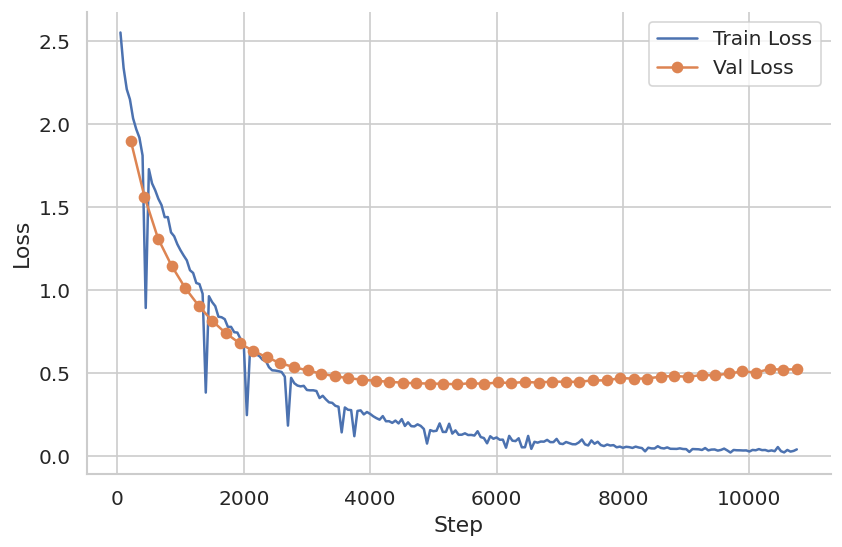

In [30]:
train_loss = ea.Scalars("train_total_loss")
val_loss   = ea.Scalars("val_total_loss")

train_steps = [x.step for x in train_loss]
train_vals  = [x.value for x in train_loss]

val_steps = [x.step for x in val_loss]
val_vals  = [x.value for x in val_loss]

plt.figure(figsize=(8,5))
plt.plot(train_steps, train_vals, label="Train Loss")
plt.plot(val_steps, val_vals, label="Val Loss", marker="o")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import glob, os

def load_tb_scalars(events_file, tags):
    ea = EventAccumulator(events_file, size_guidance={'scalars': 0})
    ea.Reload()
    available = ea.Tags()['scalars']
    result = {}
    for tag in tags:
        if tag in available:
            events = ea.Scalars(tag)
            result[tag] = pd.DataFrame({'step': [e.step for e in events],
                                        'value': [e.value for e in events]})
    return result

def load_all_tb(root, exp_name, dataset='Complete_Concept_FMNIST', tags=None):
    """Load TensorBoard scalars for ALL seeds of one experiment, any dataset."""
    if tags is None:
        tags = ['train_task_loss', 'train_concept_loss', 'train_total_loss',
                'val_task_loss', 'val_total_loss']
    exp_dir = root / dataset / 'train_cbm' / 'mCREAM_GraphEnsemble' / exp_name
    if not exp_dir.exists():
        print(f'Not found: {exp_dir}'); return {}
    all_data = {}
    for seed_dir in sorted(exp_dir.glob('seed_*')):
        seed = int(seed_dir.name.split('_')[1])
        for version_dir in sorted(seed_dir.glob('lightning_logs/version_*')):
            for ef in sorted(version_dir.glob('events.out.tfevents.*')):
                try:
                    data = load_tb_scalars(str(ef), tags)
                    if any('train' in k for k in data):
                        all_data[seed] = data
                        break
                except: pass
    print(f'{dataset}/{exp_name}: loaded {len(all_data)} seeds')
    return all_data


def plot_tb_loss(all_data, title, fname,
                 tags=('train_task_loss', 'train_concept_loss', 'train_total_loss')):
    if not all_data: print('No TensorBoard data'); return
    avail = [t for t in tags if any(t in d for d in all_data.values())]
    if not avail: return

    LOSS_COLOR = {'train_task_loss':    '#e74c3c',
                  'train_concept_loss': '#3498db',
                  'train_total_loss':   '#2c3e50',
                  'val_task_loss':      '#e67e22',
                  'val_total_loss':     '#8e44ad'}

    fig, axes = plt.subplots(1, len(avail), figsize=(5*len(avail), 4), sharey=False)
    if len(avail) == 1: axes = [axes]
    fig.suptitle(f'{title}\n(mean Â± std across {len(all_data)} seeds, faint = individual seeds)',
                 fontsize=10, fontweight='bold')

    for ax, tag in zip(axes, avail):
        col = LOSS_COLOR.get(tag, '#555555')
        seed_dfs = []
        for seed, data in all_data.items():
            if tag not in data: continue
            df = data[tag].rename(columns={'value': seed})
            seed_dfs.append(df.set_index('step'))
            ax.plot(df['step'], df[seed], color=col, lw=0.7, alpha=0.3)
        if seed_dfs:
            combined = pd.concat(seed_dfs, axis=1)
            mean = combined.mean(axis=1); std = combined.std(axis=1)
            ax.plot(mean.index, mean.values, color=col, lw=2.5)
            ax.fill_between(mean.index, mean-std, mean+std, alpha=0.2, color=col)
        ax.set_title(tag.replace('train_','').replace('_loss','').replace('_',' '), fontsize=9)
        ax.set_xlabel('Step'); ax.set_ylabel('Loss'); ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig(f'{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()


# â”€â”€ Exp2: cfmnist edge count â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
show_counts = [12, 15, 17, 19, 22]
for count in show_counts:
    exp_name = f'gensemble_edge_count_u2c_{count}edges'
    tb_data  = load_all_tb(EXPERIMENTS_ROOT, exp_name, dataset='Complete_Concept_FMNIST')
    if tb_data:
        plot_tb_loss(tb_data,
                     title=f'Exp2 cfmnist: Training loss â€” {count} u2c edges{"  (GT)" if count==17 else ""}',
                     fname=f'tb_lc_exp2_{count}edges')

# â”€â”€ Exp4: Consensus static â€” all datasets Ã— all levels â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
for ds in list(DATASET_CONFIG.keys()):
    for level in LEVELS:
        exp_name = f'graph_ensemble_consensus_{level}'
        tb_data  = load_all_tb(EXPERIMENTS_ROOT, exp_name, dataset=ds)
        if tb_data:
            plot_tb_loss(tb_data,
                         title=f'Exp4 (static) {ds}: Training loss â€” consensus {level}',
                         fname=f'tb_lc_exp4_{ds.replace(" ","_")}_{level}')

# â”€â”€ Exp5: Dynamic consensus â€” all datasets Ã— all levels â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
for ds in list(DATASET_CONFIG.keys()):
    for level in LEVELS:
        exp_name = f'graph_ensemble_consensus_dynamic_{level}'
        tb_data  = load_all_tb(EXPERIMENTS_ROOT, exp_name, dataset=ds)
        if tb_data:
            plot_tb_loss(tb_data,
                         title=f'Exp5 (dynamic) {ds}: Training loss â€” consensus {level}',
                         fname=f'tb_lc_exp5_{ds.replace(" ","_")}_{level}')

# â”€â”€ Exp4 vs Exp5 overlaid: static (dashed) vs dynamic (solid) per level â”€â”€â”€â”€â”€â”€
for ds in list(DATASET_CONFIG.keys()):
    for level in LEVELS:
        tb4 = load_all_tb(EXPERIMENTS_ROOT, f'graph_ensemble_consensus_{level}', dataset=ds)
        tb5 = load_all_tb(EXPERIMENTS_ROOT, f'graph_ensemble_consensus_dynamic_{level}', dataset=ds)
        if not tb4 and not tb5: continue

        tags = ['train_total_loss', 'val_total_loss']
        LOSS_COLOR = {'train_total_loss': '#2c3e50', 'val_total_loss': '#8e44ad'}

        fig, axes = plt.subplots(1, len(tags), figsize=(5*len(tags), 4))
        if not hasattr(axes, '__len__'): axes = [axes]
        fig.suptitle(f'Exp4 vs Exp5 â€” {ds} / {level} noise\n'
                     f'dashed = static (Exp4)   solid = dynamic (Exp5)',
                     fontsize=10, fontweight='bold')

        for ax, tag in zip(axes, tags):
            col = LOSS_COLOR.get(tag, '#555555')
            for tb_data, ls, label_suffix in [(tb4, '--', 'static'), (tb5, '-', 'dynamic')]:
                seed_dfs = []
                for seed, data in tb_data.items():
                    if tag not in data: continue
                    df = data[tag].set_index('step').rename(columns={'value': seed})
                    seed_dfs.append(df)
                    ax.plot(df.index, df[seed], color=col, lw=0.5, alpha=0.2, ls=ls)
                if seed_dfs:
                    combined = pd.concat(seed_dfs, axis=1)
                    mean = combined.mean(axis=1); std = combined.std(axis=1)
                    ax.plot(mean.index, mean.values, color=col, lw=2.5, ls=ls, label=f'{label_suffix}')
                    ax.fill_between(mean.index, mean-std, mean+std, alpha=0.12, color=col)
            ax.set_title(tag.replace('_loss','').replace('_',' '), fontsize=9)
            ax.set_xlabel('Step'); ax.set_ylabel('Loss'); ax.legend(fontsize=8)
            ax.tick_params(labelsize=8)

        plt.tight_layout()
        plt.savefig(f'tb_lc_exp4v5_{ds.replace(" ","_")}_{level}.png', dpi=150, bbox_inches='tight')
        plt.show()

In [19]:
# â”€â”€ Exp2: all edge counts overlaid on one plot per loss â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
if len(lc_exp2) == 0:
    print('No Exp2 learning curves yet.')
else:
    lc_exp2['edge_count'] = lc_exp2['exp_name'].apply(
        lambda x: int(_re.search(r'(\d+)edges', x).group(1)) if _re.search(r'(\d+)edges', x) else None)
    lc_exp2 = lc_exp2.dropna(subset=['edge_count', 'epoch'])
    lc_exp2['edge_count'] = lc_exp2['edge_count'].astype(int)

    avail = [c for c in LOSS_COLS if c in lc_exp2.columns]
    if avail:
        all_counts = sorted(lc_exp2['edge_count'].unique())
        show_counts = [c for c in [12, 15, 17, 19, 22] if c in all_counts] or all_counts
        cmap = plt.cm.RdYlGn

        fig, axes = plt.subplots(1, len(avail), figsize=(5*len(avail), 4.5), sharey=False)
        if len(avail) == 1: axes = [axes]
        fig.suptitle('Exp2: Learning Curves per Edge Count\n'
                     f'(GT=17, each line = mean across seeds)',
                     fontsize=11, fontweight='bold')

        for ax, loss in zip(axes, avail):
            for count in show_counts:
                sub = lc_exp2[lc_exp2['edge_count'] == count].dropna(subset=[loss])
                if sub.empty: continue
                agg = sub.groupby('epoch')[loss].agg(['mean','std']).reset_index()
                norm = all_counts.index(count) / max(len(all_counts)-1, 1)
                col  = cmap(norm)
                lw   = 3 if count == 17 else 1.5
                ls   = '-' if count == 17 else '--'
                ax.plot(agg['epoch'], agg['mean'], color=col, lw=lw, ls=ls,
                        label=f'{count}{"(GT)" if count==17 else ""}')
                ax.fill_between(agg['epoch'], agg['mean']-agg['std'], agg['mean']+agg['std'],
                                alpha=0.08, color=col)
            ax.set_title(loss.replace('train_','').replace('_loss','').replace('_',' '), fontsize=9)
            ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.tick_params(labelsize=8)
            ax.legend(fontsize=7, ncol=2)

        plt.tight_layout()
        plt.savefig('lc_exp2_edge_count.png', dpi=150, bbox_inches='tight')
        plt.show()

KeyError: ['epoch']

---
# Cross-Experiment Comparison

Direct comparison of all three experiments.


In [ ]:
# Collect one row per experiment type with key metrics, including CCI and PFI
summary_rows = []
SUMMARY_METRICS = {
    'task_acc': 'test_task_accuracy',
    'concept_acc': 'test_concept_accuracy',
    'CCI': 'CCI',
    'PFI_concept': 'PFI_concept_importance',
    'PFI_side': 'PFI_side_importance',
}

def _metric_mean(grp, col):
    return grp[col].mean() if col in grp.columns else float('nan')

def _summary_row(experiment, grp, action='?', level='?', dataset=None, variant=None, exp_type=None):
    row = {'experiment': experiment, 'action': action, 'level': level}
    if dataset is not None:
        row['dataset'] = dataset
    if variant is not None:
        row['variant'] = variant
    if exp_type is not None:
        row['exp_type'] = exp_type
    for out_col, src_col in SUMMARY_METRICS.items():
        row[out_col] = _metric_mean(grp, src_col)
    return row

if len(exp1_df)>0 and 'test_task_accuracy' in exp1_df.columns:
    for (action,level),grp in exp1_df.groupby(['action','noise_level']):
        summary_rows.append(_summary_row('Noisy DAG', grp, action=action, level=level))

if len(exp3_df)>0 and 'test_task_accuracy' in exp3_df.columns:
    for action,grp in exp3_df.groupby('action'):
        summary_rows.append(_summary_row('Mixed Levels', grp, action=action, level='mixed'))

if 'exp4_df' in globals() and len(exp4_df)>0 and 'test_task_accuracy' in exp4_df.columns:
    for (ds,level),grp in exp4_df.groupby(['dataset','noise_level']):
        summary_rows.append(_summary_row('Static Consensus Alpha', grp, level=level, dataset=ds, exp_type='static'))

if 'exp5_df' in globals() and len(exp5_df)>0 and 'test_task_accuracy' in exp5_df.columns:
    for (ds,level),grp in exp5_df.groupby(['dataset','noise_level']):
        summary_rows.append(_summary_row('Dynamic Consensus Alpha', grp, level=level, dataset=ds, exp_type='dynamic'))

if 'exp6_df' in globals() and len(exp6_df)>0 and 'test_task_accuracy' in exp6_df.columns:
    for (ds,exp_type,variant,level),grp in exp6_df.groupby(['dataset','exp_type','variant','noise_level']):
        summary_rows.append(_summary_row('Uniform vs Learned Lambda', grp, level=level, dataset=ds, variant=variant, exp_type=exp_type))

if 'exp7_df' in globals() and len(exp7_df)>0 and 'test_task_accuracy' in exp7_df.columns:
    for (ds,level,expert),grp in exp7_df.groupby(['dataset','noise_level','expert']):
        summary_rows.append(_summary_row('CREAM Noisy Expert', grp, action=f'expert_{expert}', level=level, dataset=ds))

if len(gt_df)>0:
    summary_rows.append(_summary_row('GT CREAM', gt_df))

if summary_rows:
    print('=== Cross-experiment summary: accuracy + CCI + PFI ===')
    summary_df = pd.DataFrame(summary_rows).round(4)
    preferred = ['experiment','dataset','exp_type','variant','action','level',
                 'task_acc','concept_acc','CCI','PFI_concept','PFI_side']
    display(summary_df[[c for c in preferred if c in summary_df.columns]])


Loaded alpha for 3 experiments, seeds: [1, 7, 42, 89, 134]


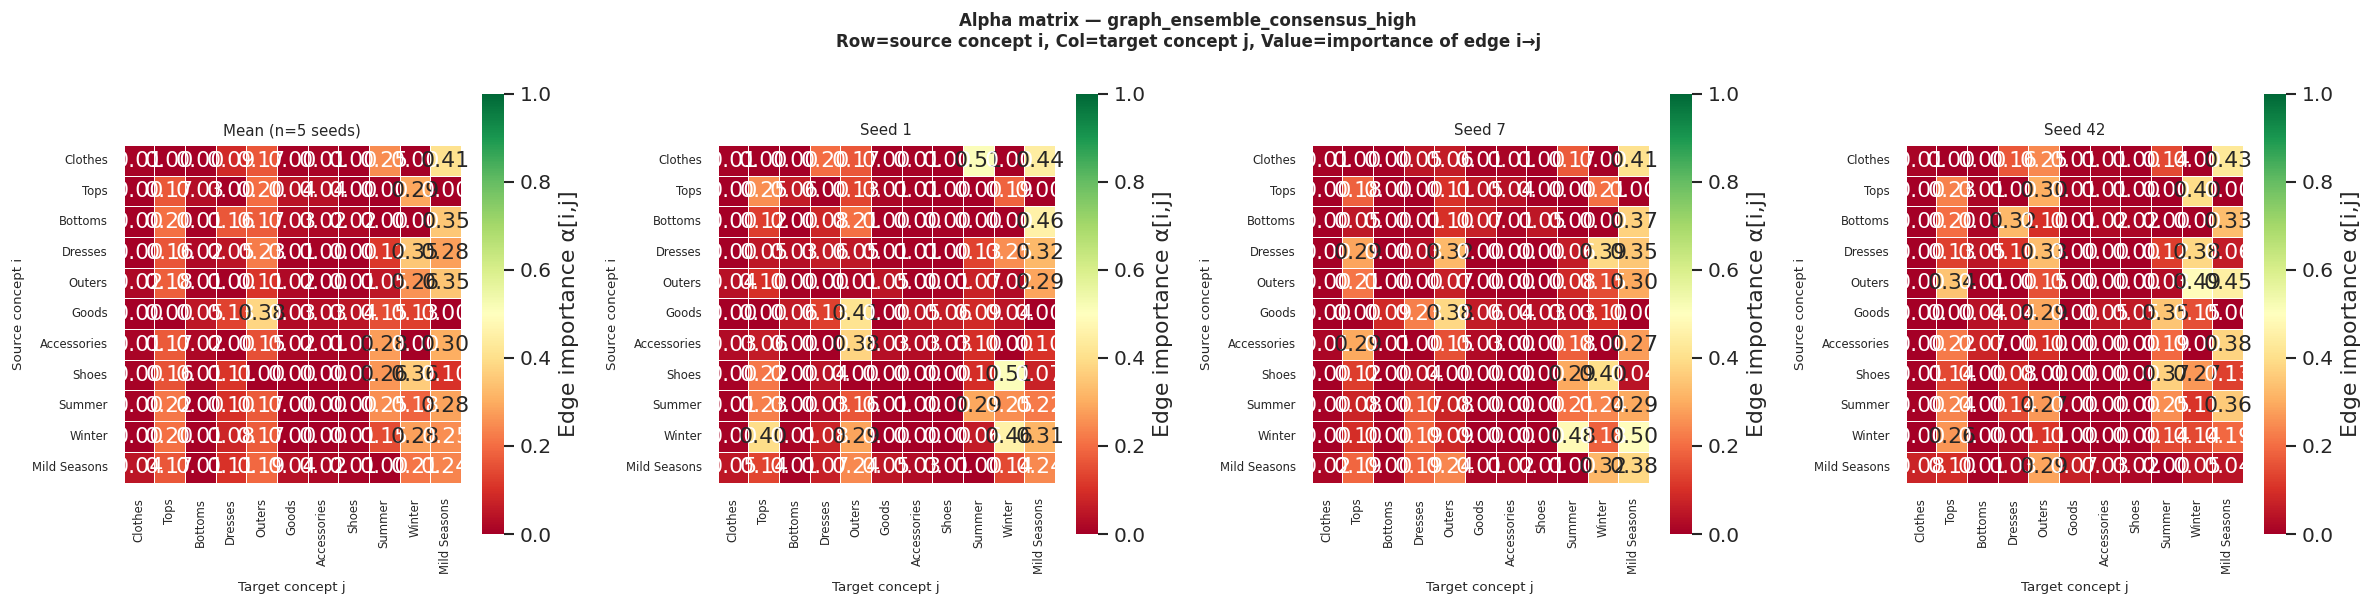


--- graph_ensemble_consensus_high: Top 5 most important edges (mean Î±) ---
  Clothes â†’ Mild Seasons: Î±=0.408 Â± 0.066
  Goods â†’ Outers: Î±=0.383 Â± 0.048
  Shoes â†’ Winter: Î±=0.363 Â± 0.087
  Bottoms â†’ Mild Seasons: Î±=0.351 Â± 0.073
  Dresses â†’ Winter: Î±=0.348 Â± 0.050

--- Bottom 5 (suppressed by L1) ---
  Goods â†’ Mild Seasons: Î±=0.003
  Goods â†’ Clothes: Î±=0.003
  Dresses â†’ Clothes: Î±=0.003
  Outers â†’ Dresses: Î±=0.003
  Summer â†’ Bottoms: Î±=0.002


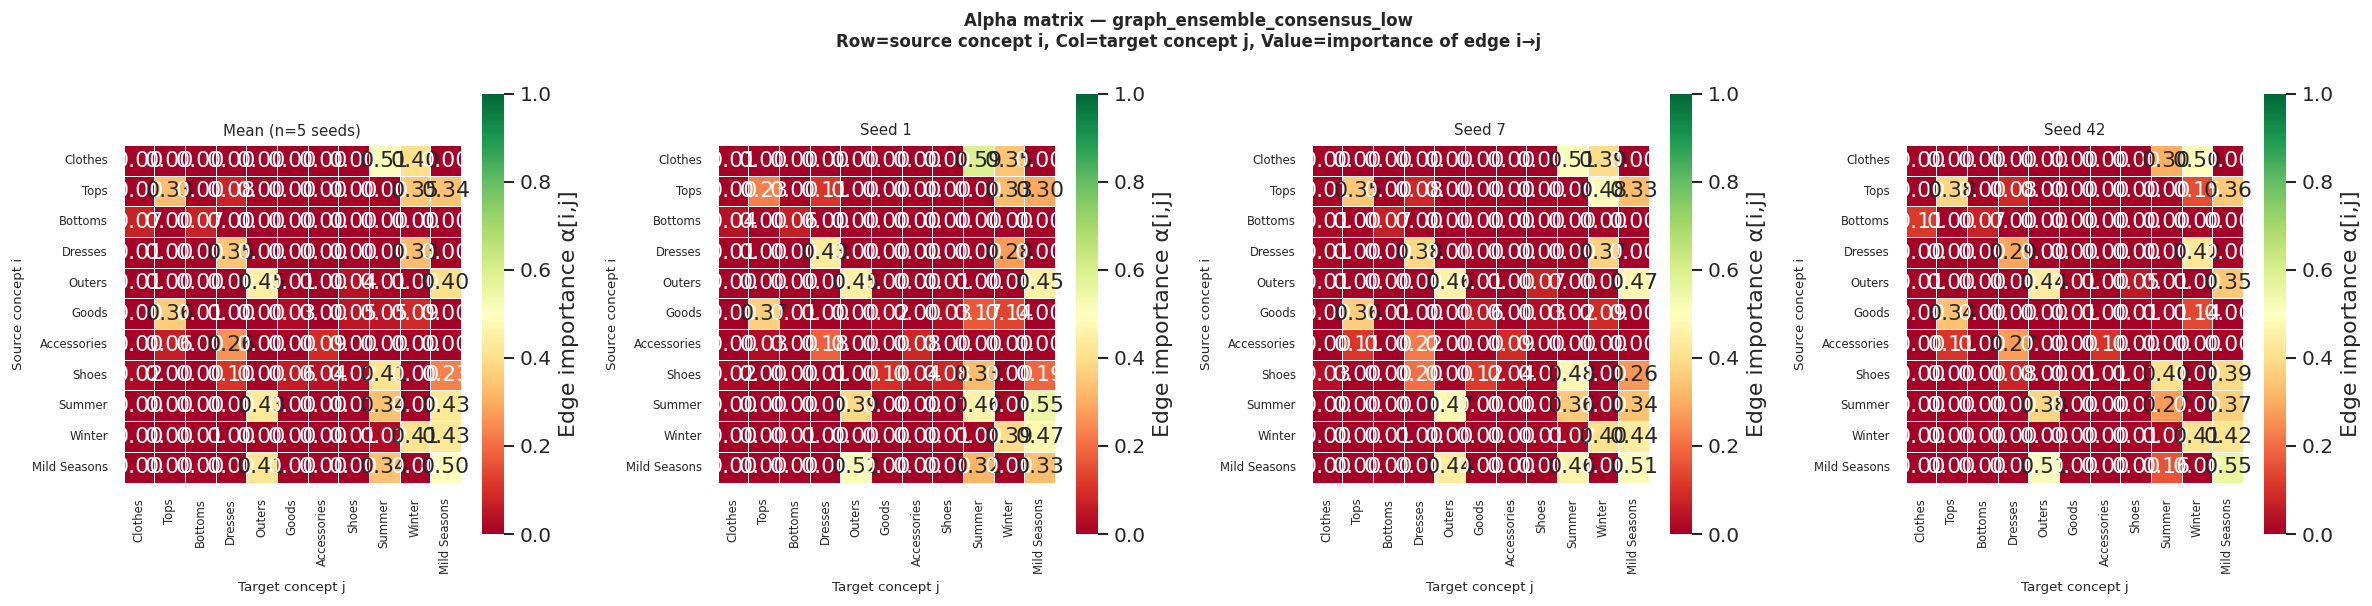


--- graph_ensemble_consensus_low: Top 5 most important edges (mean Î±) ---
  Clothes â†’ Summer: Î±=0.511 Â± 0.108
  Mild Seasons â†’ Mild Seasons: Î±=0.503 Â± 0.092
  Outers â†’ Outers: Î±=0.447 Â± 0.032
  Summer â†’ Outers: Î±=0.431 Â± 0.038
  Winter â†’ Mild Seasons: Î±=0.428 Â± 0.027

--- Bottom 5 (suppressed by L1) ---
  Accessories â†’ Bottoms: Î±=0.003
  Summer â†’ Bottoms: Î±=0.003
  Clothes â†’ Goods: Î±=0.002
  Accessories â†’ Clothes: Î±=0.002
  Winter â†’ Accessories: Î±=0.002


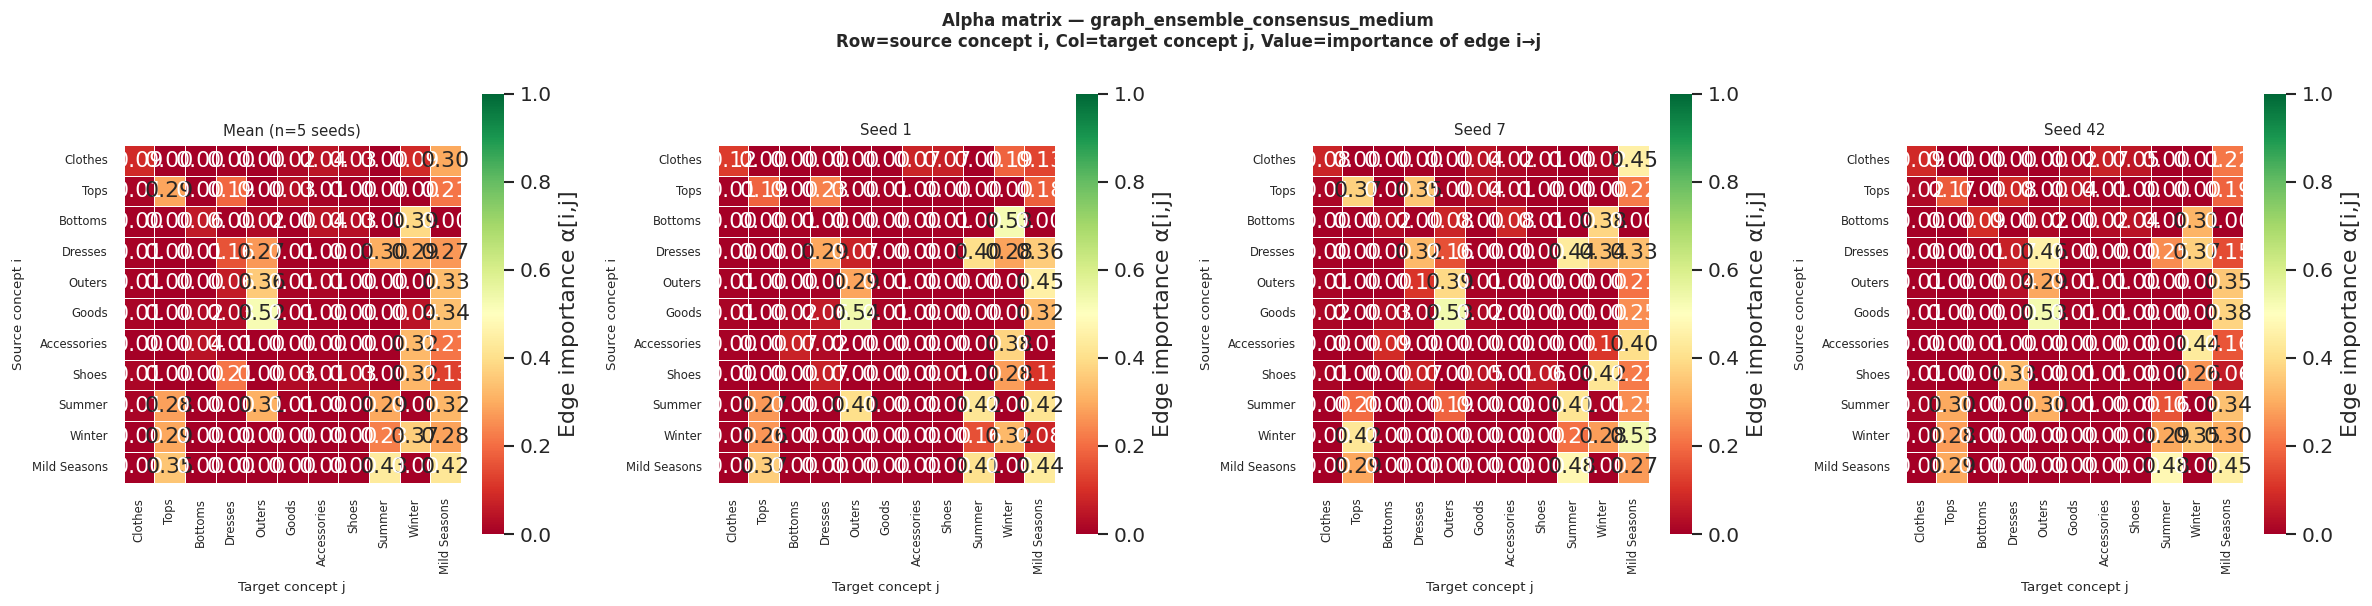


--- graph_ensemble_consensus_medium: Top 5 most important edges (mean Î±) ---
  Goods â†’ Outers: Î±=0.523 Â± 0.013
  Mild Seasons â†’ Summer: Î±=0.435 Â± 0.051
  Mild Seasons â†’ Mild Seasons: Î±=0.424 Â± 0.082
  Bottoms â†’ Winter: Î±=0.390 Â± 0.093
  Winter â†’ Winter: Î±=0.366 Â± 0.073

--- Bottom 5 (suppressed by L1) ---
  Shoes â†’ Bottoms: Î±=0.003
  Tops â†’ Shoes: Î±=0.003
  Shoes â†’ Outers: Î±=0.003
  Shoes â†’ Summer: Î±=0.003
  Tops â†’ Summer: Î±=0.003


---
# Experiment 6 â€” Uniform Î» vs Learned Î» (mCREAM)

Compare mCREAM with fixed equal weights (Î»_m = 1/M = 0.2) vs learned Î»_m.
Both use same expert graphs (consensus 90%).
- **Uniform**: Î» fixed, no gradient on _lambda_logits
- **Learned**: Î» trained end-to-end (standard mCREAM)

Results saved in `uniform_lambda_graph_ensemble_consensus_*` folders.

In [2]:
import re as _re6

def load_uniform_vs_learned(root):
    rows = []
    for ds in list(DATASET_CONFIG.keys()):
        ens_dir = root / ds / 'train_cbm' / 'mCREAM_GraphEnsemble'
        if not ens_dir.exists(): continue
        for exp_dir in sorted(ens_dir.iterdir()):
            name = exp_dir.name
            # match both static and dynamic, learned and uniform
            m = _re6.search(r'(uniform_lambda_)?graph_ensemble_consensus_(dynamic_)?(low|medium|high)$', name)
            if not m: continue
            is_uniform = m.group(1) is not None
            is_dynamic = m.group(2) is not None
            level = m.group(3)
            variant = 'uniform' if is_uniform else 'learned'
            exp_type = 'dynamic' if is_dynamic else 'static'
            for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
                seed = int(seed_dir.parent.parent.name.split('_')[1])
                for csv_f in sorted(seed_dir.glob('*.csv')):
                    if any(x in csv_f.name for x in ['perc_','_set_','intervention','exogenous','alpha']): continue
                    try:
                        df = pd.read_csv(csv_f)
                        df['dataset'] = ds; df['noise_level'] = level
                        df['variant'] = variant; df['exp_type'] = exp_type
                        df['seed'] = seed; df['exp_name'] = name
                        rows.append(df)
                    except: pass
    if not rows: print('No Exp6 data yet.'); return pd.DataFrame()
    df = pd.concat(rows, ignore_index=True)
    print(f'Exp6 loaded: {len(df)} rows | variants={sorted(df.variant.unique())} | types={sorted(df.exp_type.unique())} | levels={sorted(df.noise_level.unique())}')
    return df

exp6_df = load_uniform_vs_learned(EXPERIMENTS_ROOT)

# Load interventions for all consensus experiments (both static and dynamic, both variants)
exp6_interv = load_interventions(
    EXPERIMENTS_ROOT,
    exp_name_filter=['graph_ensemble_consensus'],
    datasets=list(DATASET_CONFIG.keys())
)
if len(exp6_interv) > 0:
    # tag each row with variant and exp_type
    exp6_interv['is_uniform']  = exp6_interv['exp_name'].str.startswith('uniform_lambda_')
    exp6_interv['is_dynamic']  = exp6_interv['exp_name'].str.contains('dynamic')
    exp6_interv['variant']     = exp6_interv['is_uniform'].map({True:'uniform', False:'learned'})
    exp6_interv['exp_type']    = exp6_interv['is_dynamic'].map({True:'dynamic', False:'static'})
    exp6_interv['noise_level'] = exp6_interv['exp_name'].str.extract(r'(low|medium|high)$')
    print(f'Exp6 interventions: {len(exp6_interv)} rows | variants={sorted(exp6_interv.variant.unique())} | types={sorted(exp6_interv.exp_type.unique())}')

Exp6 loaded: 180 rows | variants=['learned', 'uniform'] | types=['dynamic', 'static'] | levels=['high', 'low', 'medium']
Exp6 interventions: 13967 rows | variants=['learned', 'uniform'] | types=['dynamic', 'static']


=== Exp6 (dynamic): CUB â€” Uniform vs Learned Î» ===


test_task_accuracy test_concept_accuracy              CCI
variant noise_level                                                          
learned high           0.7157 Â± 0.0035       0.8371 Â± 0.0023  0.9415 Â± 0.0022
        low            0.7273 Â± 0.0047       0.8431 Â± 0.0019  0.9483 Â± 0.0027
        medium         0.7245 Â± 0.0059       0.8409 Â± 0.0013  0.9457 Â± 0.0024
uniform high           0.7168 Â± 0.0030       0.8377 Â± 0.0008  0.9411 Â± 0.0023
        low            0.7271 Â± 0.0048       0.8434 Â± 0.0012  0.9483 Â± 0.0023
        medium         0.7246 Â± 0.0033       0.8417 Â± 0.0012  0.9463 Â± 0.0022

=== Exp6 (dynamic): CelebA â€” Uniform vs Learned Î» ===


test_task_accuracy test_concept_accuracy              CCI
variant noise_level                                                          
learned high           0.7877 Â± 0.0371       0.7956 Â± 0.0204  0.9358 Â± 0.1641
        low            0.7958 Â± 0.0229       0.8103 Â± 0.0044  0.9362 Â± 0.1655
        medium         0.8072 Â± 0.0291       0.8151 Â± 0.0055  0.9170 Â± 0.1402
uniform high           0.8011 Â± 0.0124       0.8037 Â± 0.0028  0.9209 Â± 0.1435
        low            0.8073 Â± 0.0182       0.8086 Â± 0.0075  0.9084 Â± 0.1363
        medium         0.8042 Â± 0.0235       0.8011 Â± 0.0044  0.9210 Â± 0.1418

=== Exp6 (dynamic): Complete_Concept_FMNIST â€” Uniform vs Learned Î» ===


test_task_accuracy test_concept_accuracy              CCI
variant noise_level                                                          
learned high           0.9197 Â± 0.0022       0.9747 Â± 0.0030  0.9916 Â± 0.0013
        low            0.9229 Â± 0.0009       0.9771 Â± 0.0040  0.9918 Â± 0.0026
        medium         0.9191 Â± 0.0057       0.9783 Â± 0.0043  0.9909 Â± 0.0025
uniform high           0.9212 Â± 0.0031       0.9735 Â± 0.0022  0.9909 Â± 0.0022
        low            0.9236 Â± 0.0009       0.9784 Â± 0.0033  0.9910 Â± 0.0012
        medium         0.9235 Â± 0.0014       0.9786 Â± 0.0037  0.9917 Â± 0.0022

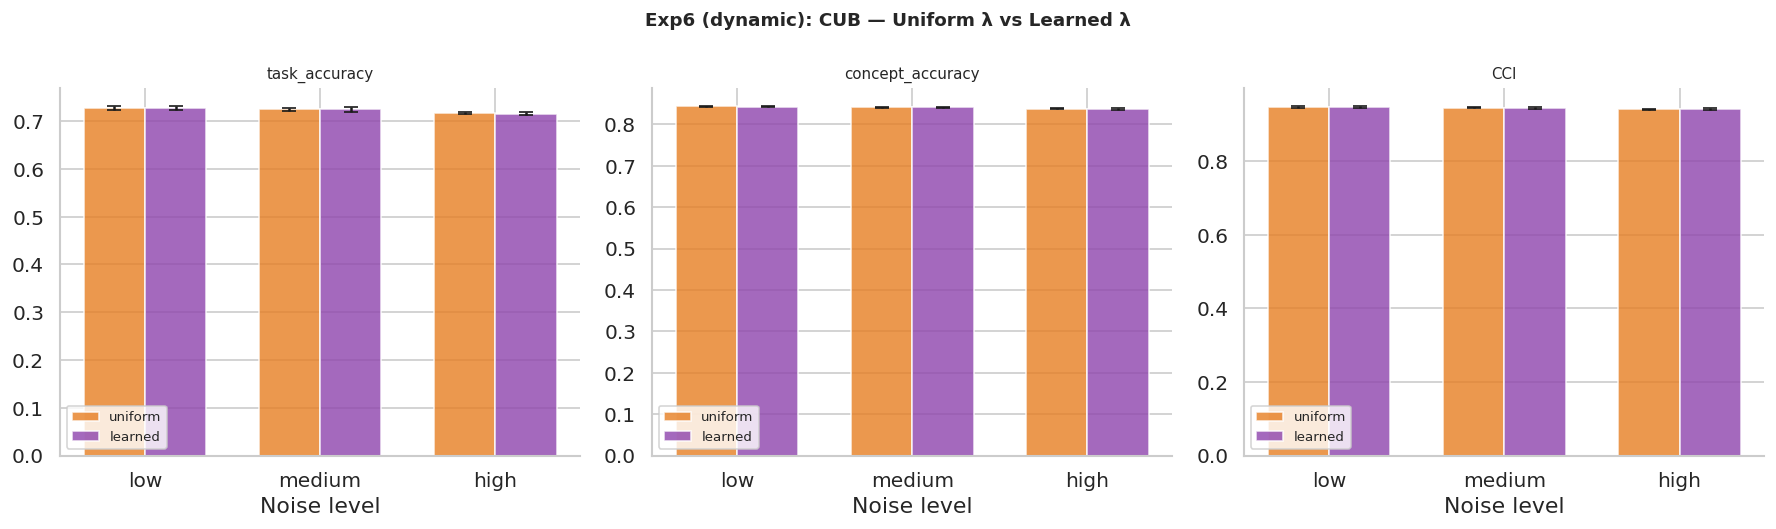

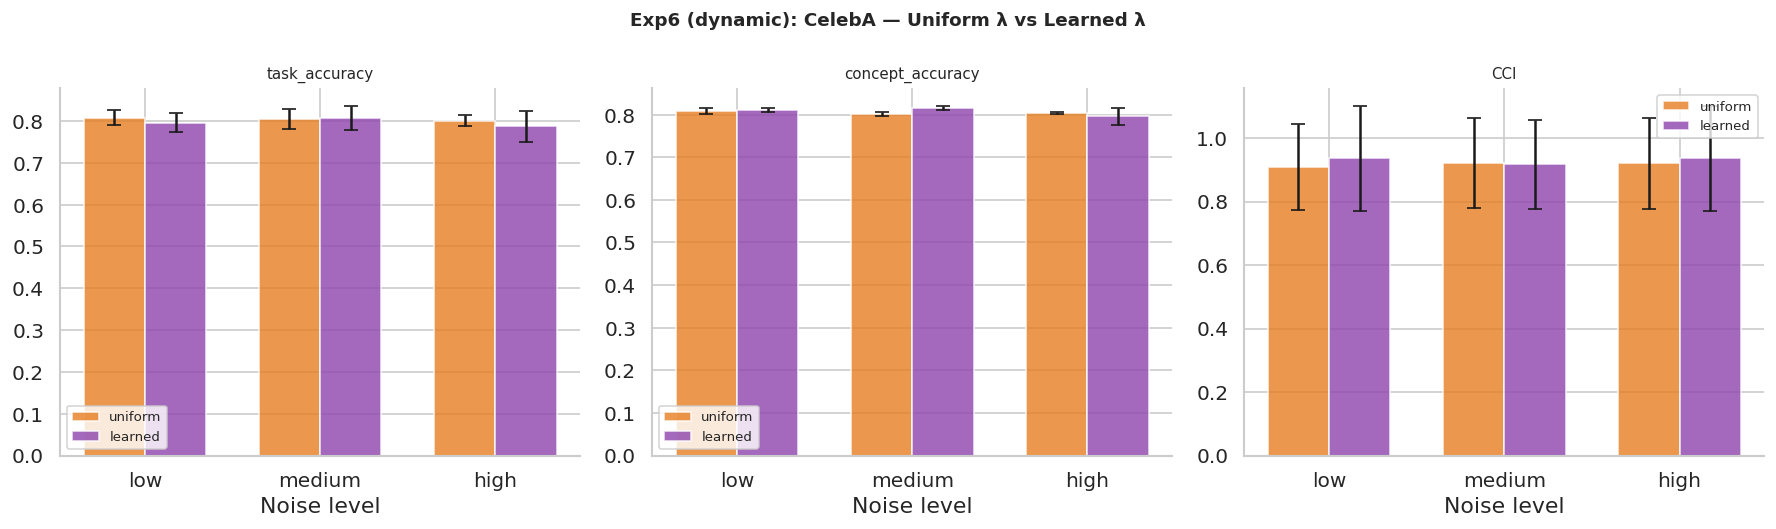

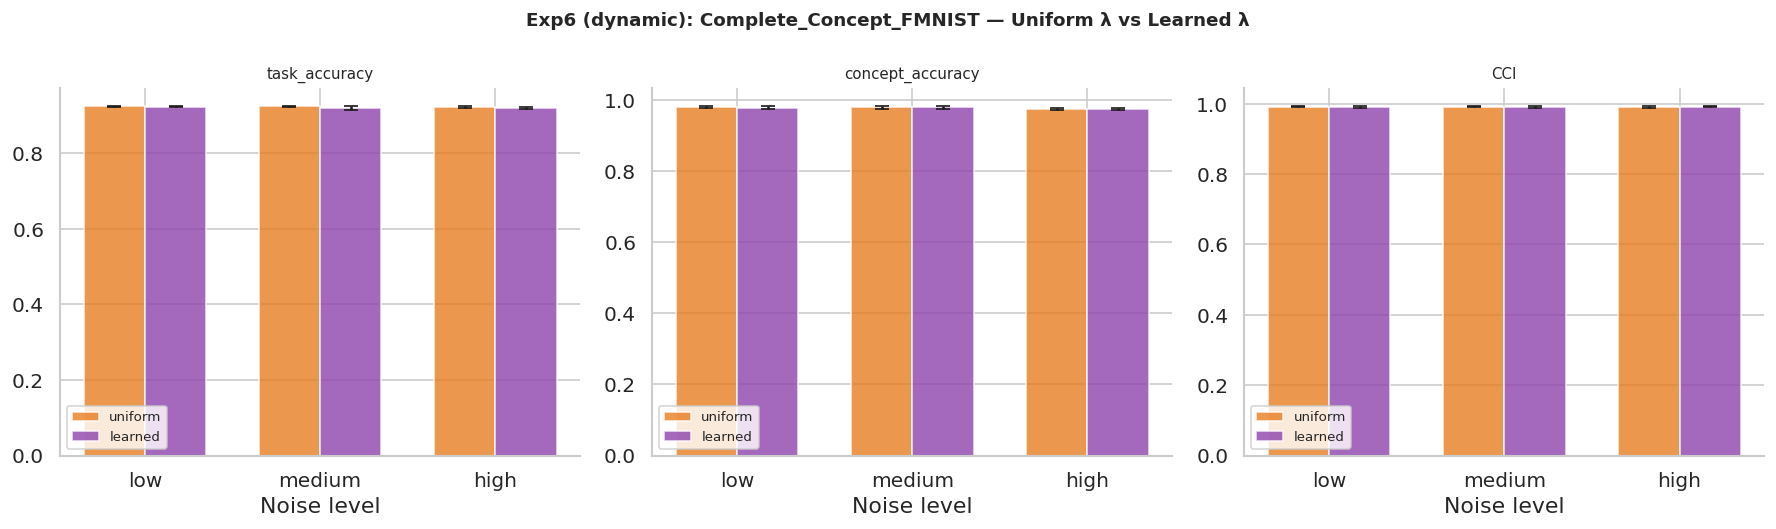

=== Exp6 (static): CUB â€” Uniform vs Learned Î» ===


test_task_accuracy test_concept_accuracy              CCI
variant noise_level                                                          
learned high           0.7353 Â± 0.0017       0.8479 Â± 0.0006  0.9518 Â± 0.0031
        low            0.7354 Â± 0.0020       0.8483 Â± 0.0005  0.9516 Â± 0.0028
        medium         0.7363 Â± 0.0018       0.8484 Â± 0.0008  0.9517 Â± 0.0029

=== Exp6 (static): CelebA â€” Uniform vs Learned Î» ===


test_task_accuracy test_concept_accuracy              CCI
variant noise_level                                                          
learned high           0.7931 Â± 0.0108       0.8051 Â± 0.0054  0.9256 Â± 0.1495
        low            0.8018 Â± 0.0118       0.8070 Â± 0.0086  0.9186 Â± 0.1395
        medium         0.8018 Â± 0.0198       0.8015 Â± 0.0070  0.9181 Â± 0.1456

=== Exp6 (static): Complete_Concept_FMNIST â€” Uniform vs Learned Î» ===


test_task_accuracy test_concept_accuracy              CCI
variant noise_level                                                          
learned high           0.9247 Â± 0.0007       0.9814 Â± 0.0004  0.9914 Â± 0.0018
        low            0.9240 Â± 0.0010       0.9813 Â± 0.0003  0.9913 Â± 0.0011
        medium         0.9246 Â± 0.0007       0.9815 Â± 0.0002  0.9904 Â± 0.0026

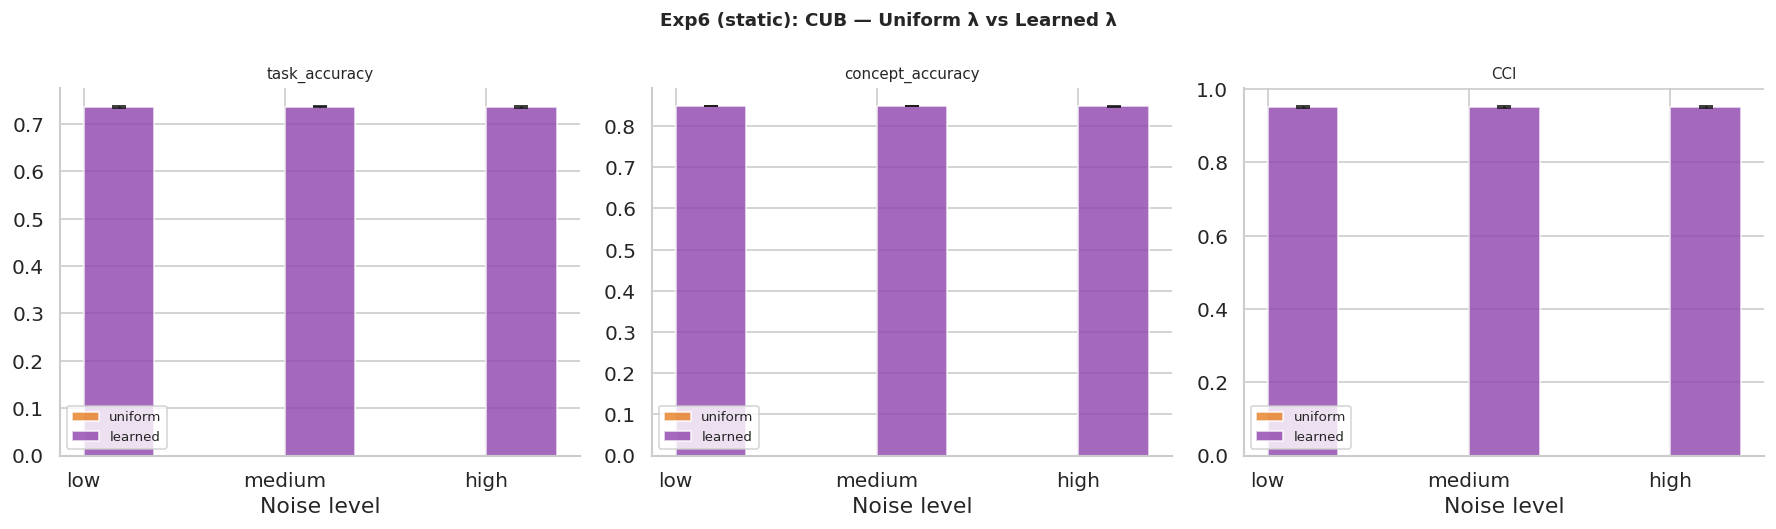

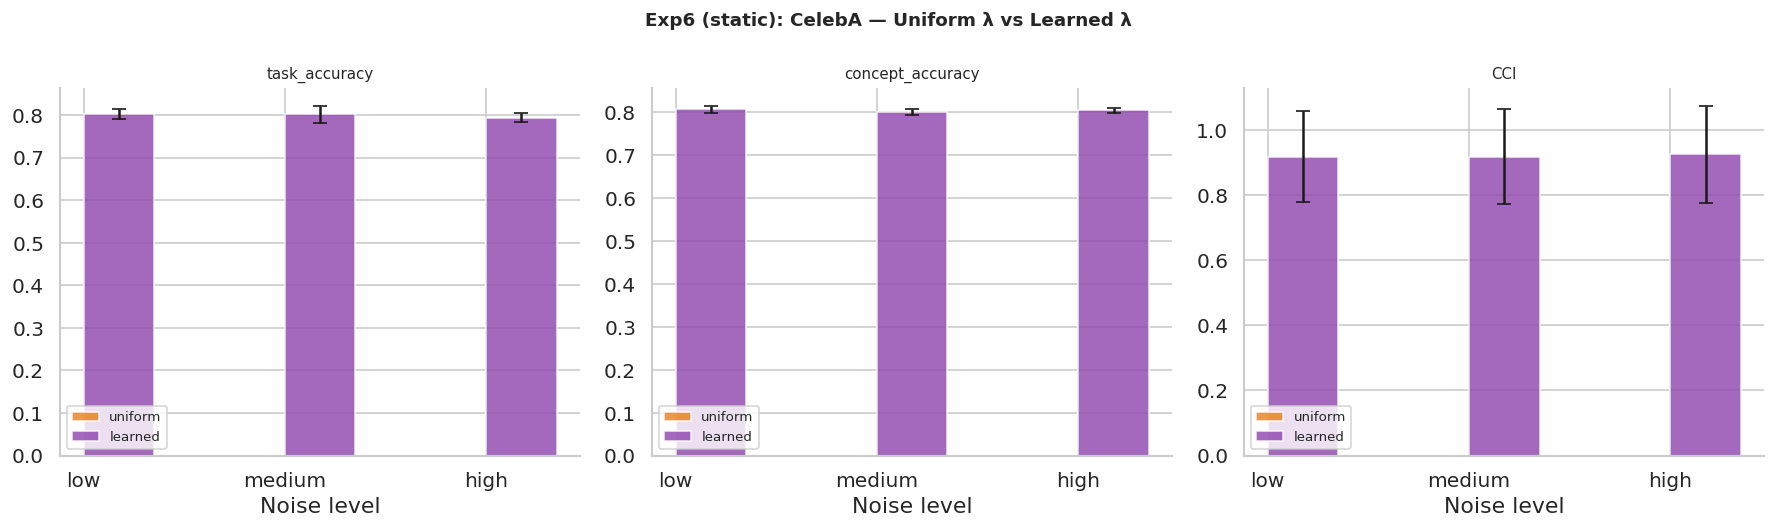

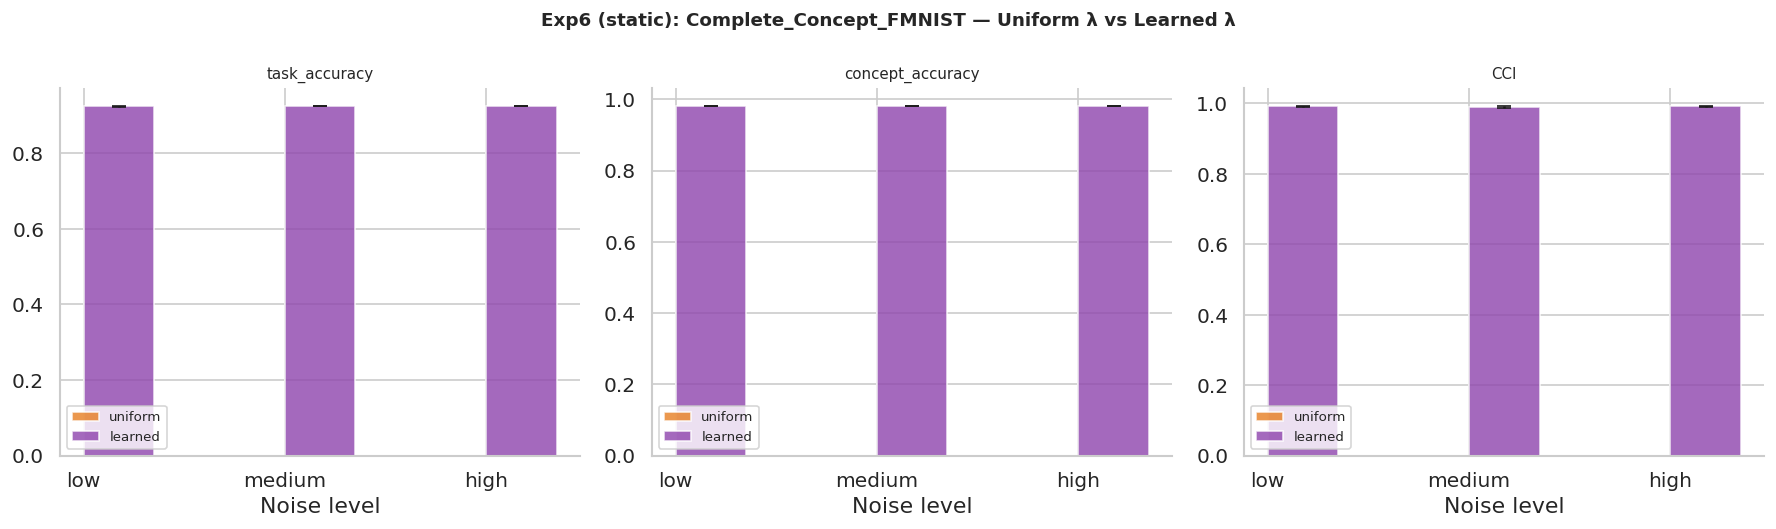

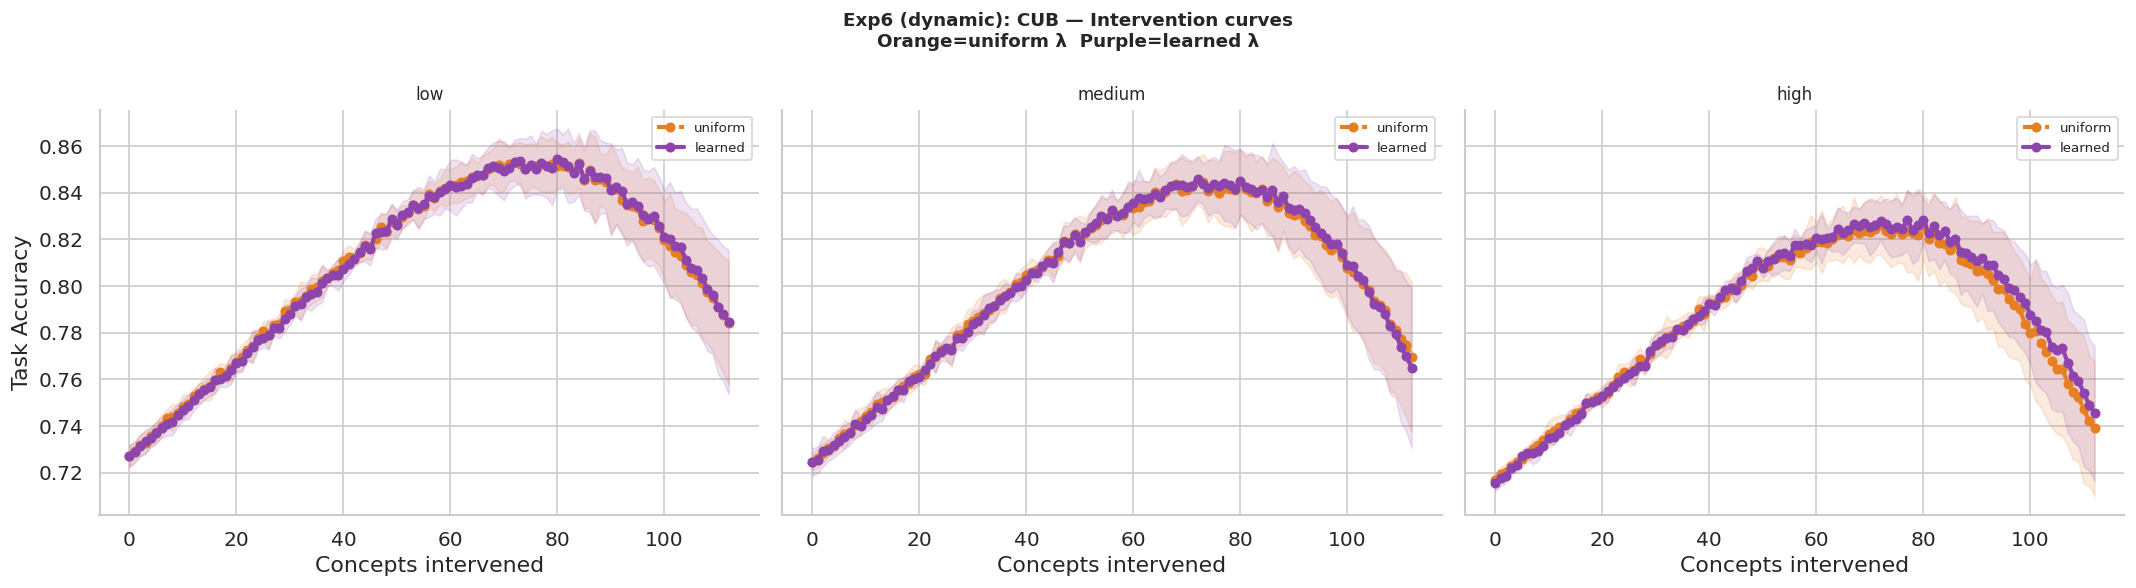

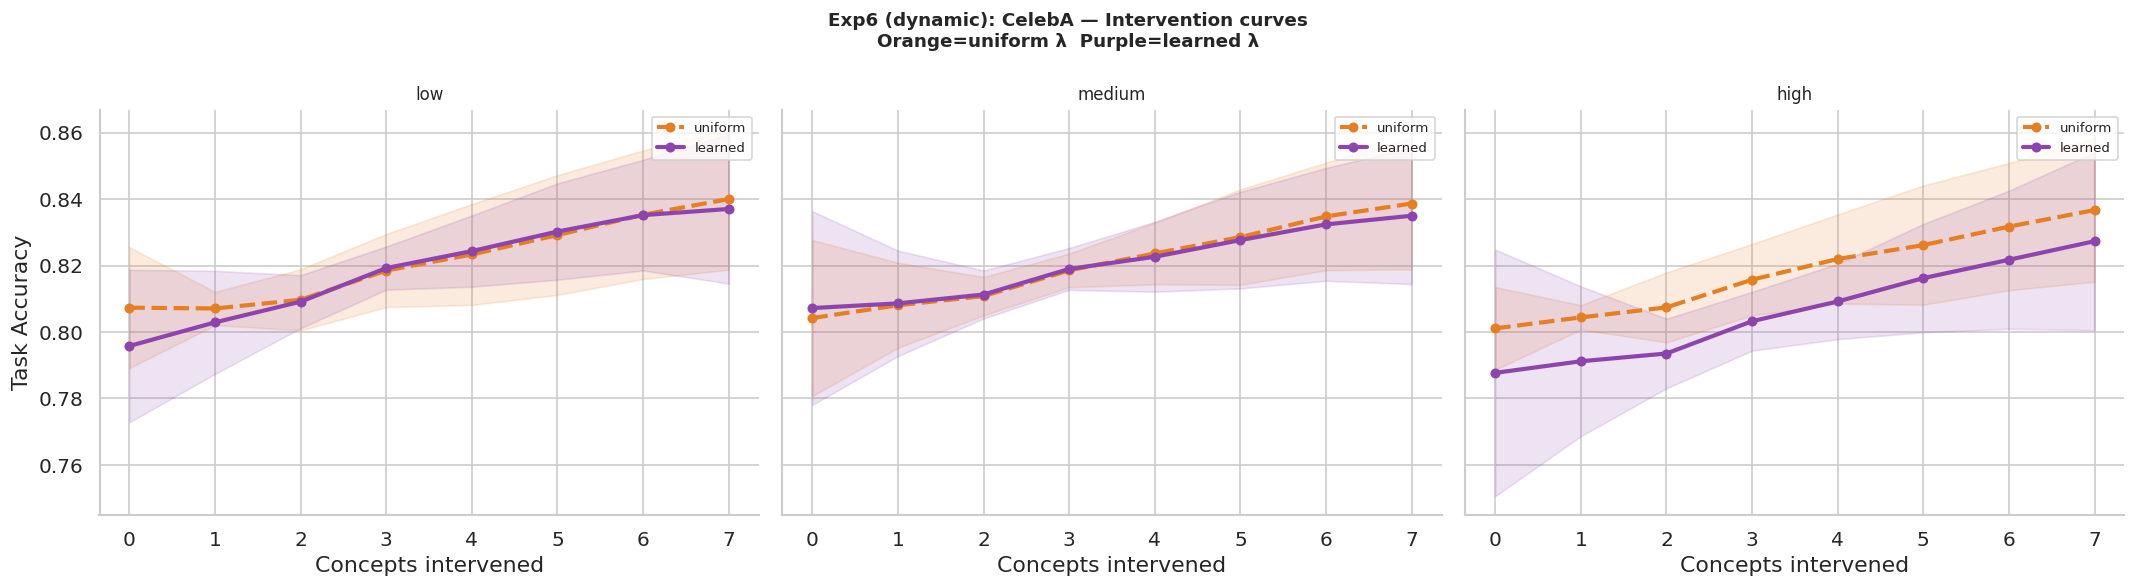

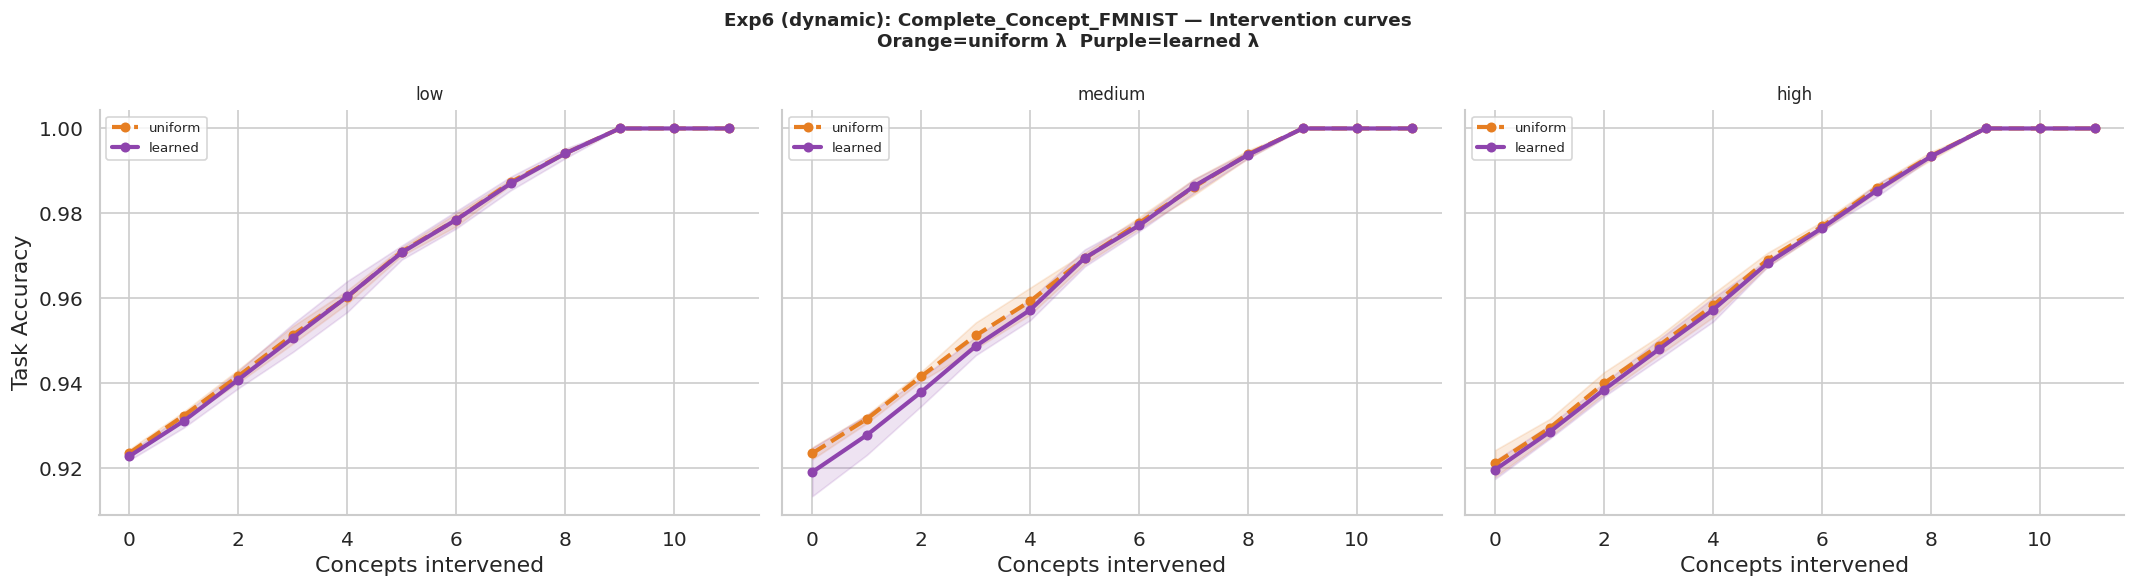

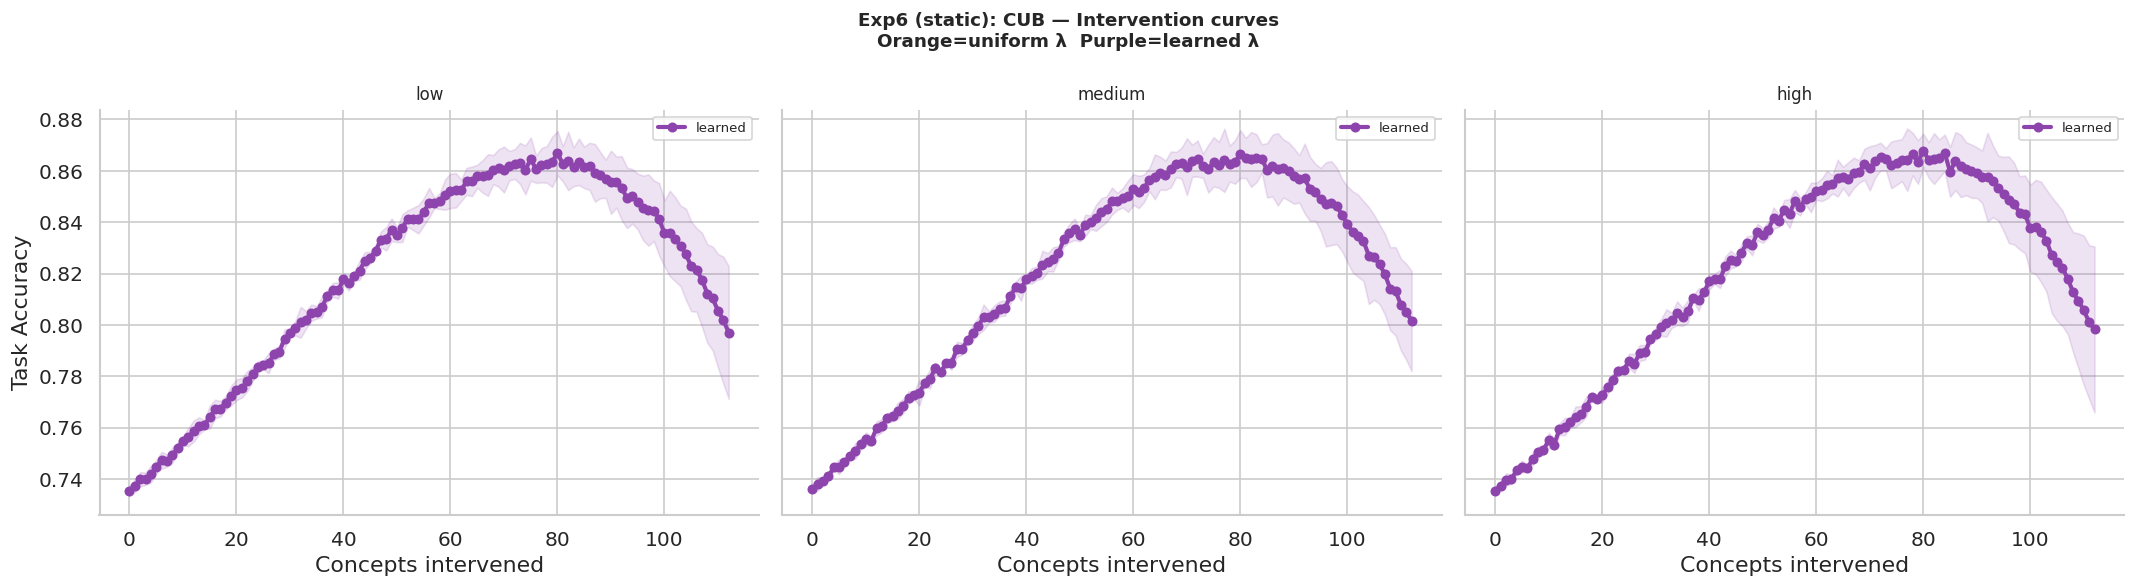

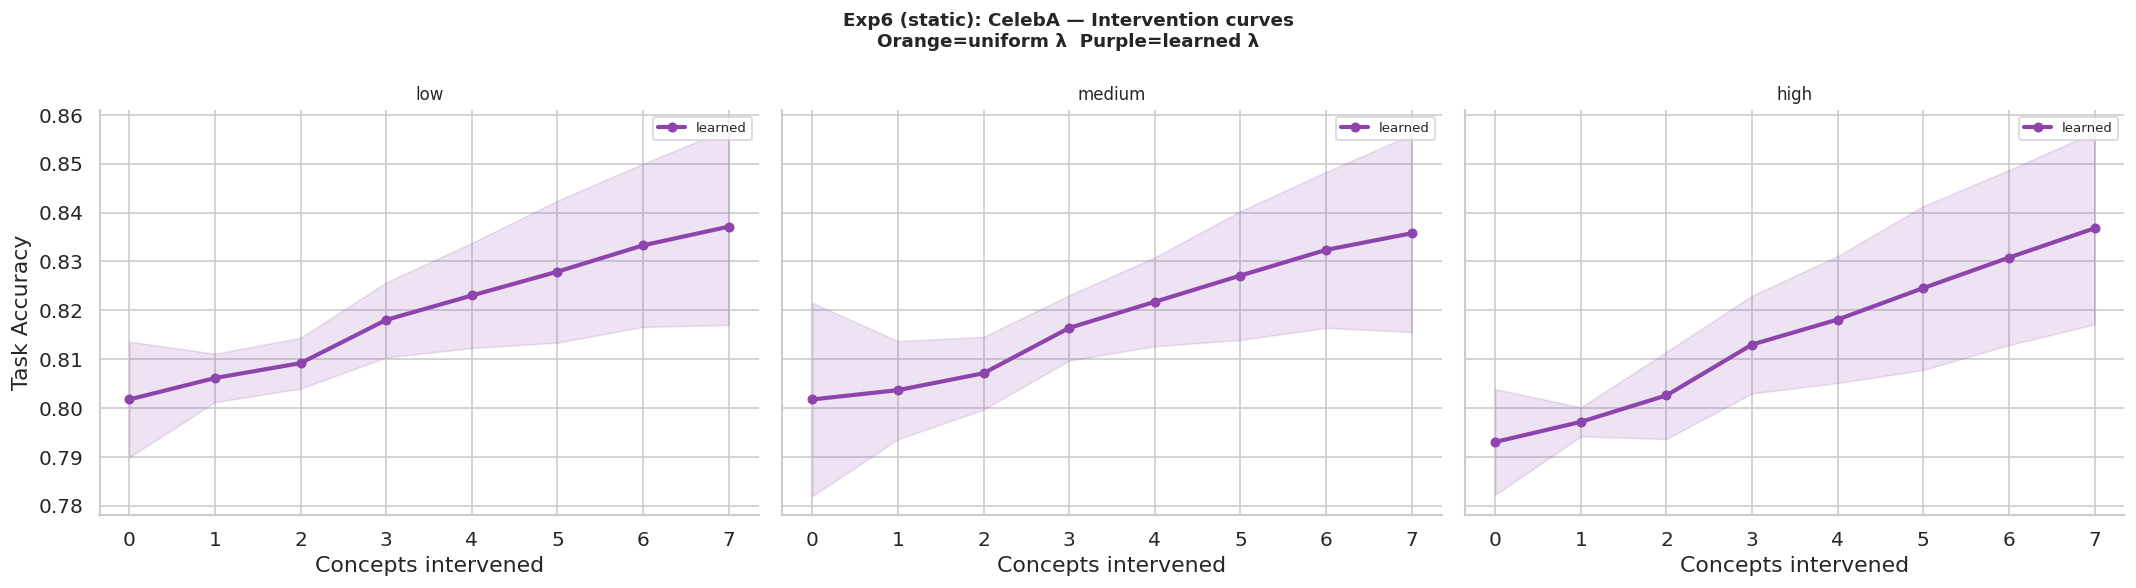

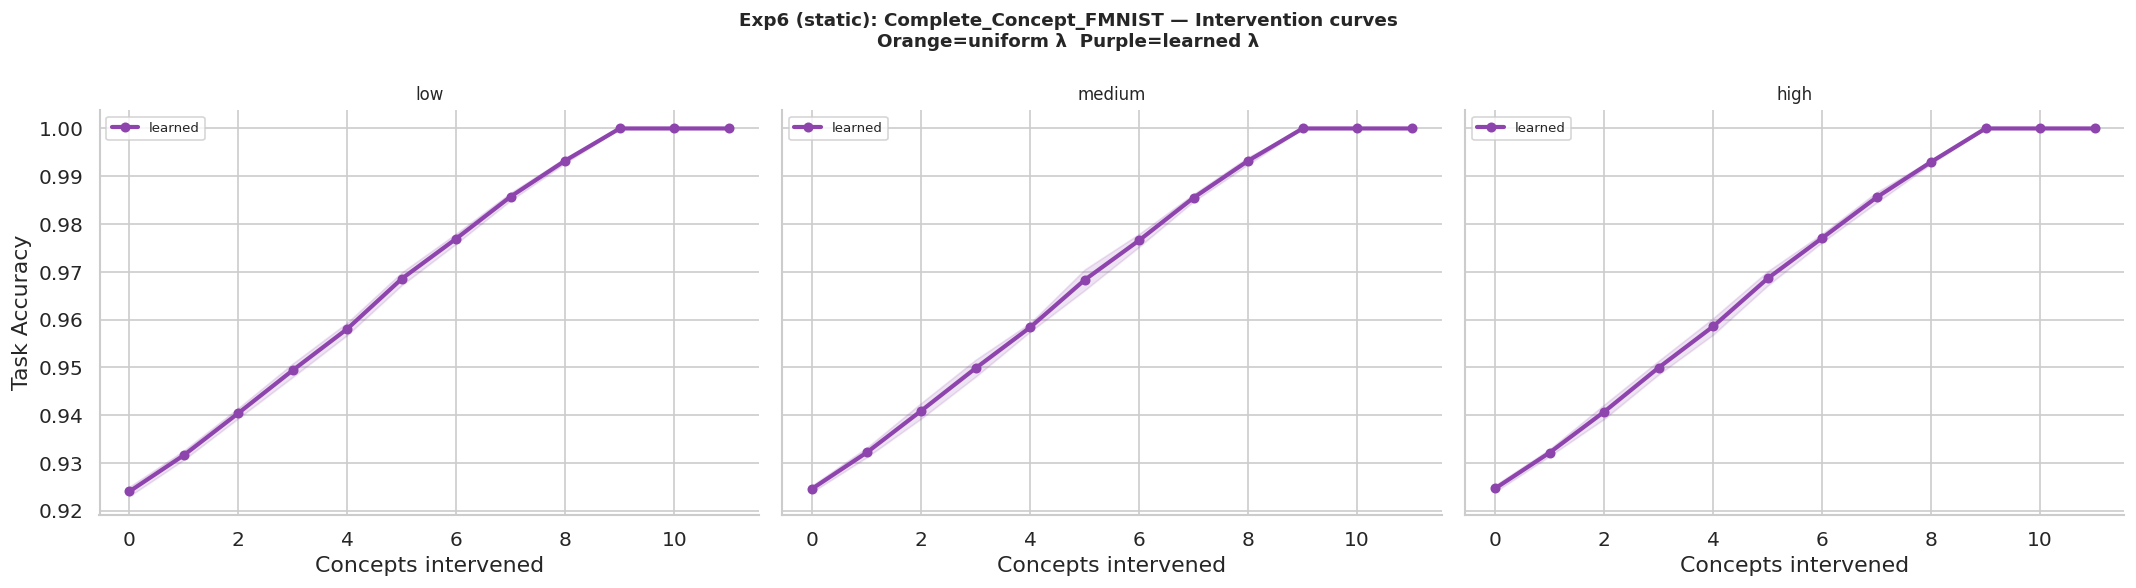

In [3]:
if len(exp6_df) == 0:
    print('No Exp6 data yet. Submit: ./submit_graph_ensemble_consensus.sh --uniform-lambda --dataset all')
else:
    lnum = {'low': 0.15, 'medium': 0.25, 'high': 0.50}
    KEY  = ['test_task_accuracy', 'test_concept_accuracy', 'CCI', 'PFI_concept_importance', 'PFI_side_importance']
    av   = [c for c in KEY if c in exp6_df.columns]
    VARIANT_COLOR = {'uniform': '#e67e22', 'learned': '#8e44ad'}

    for exp_type in sorted(exp6_df['exp_type'].unique()):
        sub_type = exp6_df[exp6_df['exp_type'] == exp_type]

        # â”€â”€ Summary table per dataset â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        for ds in sorted(sub_type['dataset'].unique()):
            sub = sub_type[sub_type['dataset'] == ds]
            means = sub.groupby(['variant', 'noise_level'])[av].mean()
            stds  = sub.groupby(['variant', 'noise_level'])[av].std()
            sm = pd.DataFrame({c: means[c].map('{:.4f}'.format) + ' Â± ' + stds[c].map('{:.4f}'.format) for c in av})
            print(f'=== Exp6 ({exp_type}): {ds} â€” Uniform vs Learned Î» ===')
            display(sm)

        # â”€â”€ Bar chart per dataset â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        for ds in sorted(sub_type['dataset'].unique()):
            sub = sub_type[sub_type['dataset'] == ds]
            fig, axes = plt.subplots(1, len(av), figsize=(5*len(av), 4.5))
            if len(av) == 1: axes = [axes]
            fig.suptitle(f'Exp6 ({exp_type}): {ds} â€” Uniform Î» vs Learned Î»', fontsize=11, fontweight='bold')
            x = np.arange(len(LEVELS)); w = 0.35
            for ax, metric in zip(axes, av):
                for i, (variant, col) in enumerate(VARIANT_COLOR.items()):
                    means, stds = [], []
                    for level in LEVELS:
                        g = sub[(sub['variant']==variant) & (sub['noise_level']==level)]
                        means.append(g[metric].mean() if not g.empty else np.nan)
                        stds.append(g[metric].std()   if not g.empty else 0)
                    ax.bar(x + (i-0.5)*w, means, w, yerr=stds, capsize=4,
                           color=col, alpha=0.8, label=variant)
                ax.set_title(metric.replace('test_',''), fontsize=9)
                ax.set_xticks(x); ax.set_xticklabels(LEVELS)
                ax.set_xlabel('Noise level'); ax.legend(fontsize=8)
            plt.tight_layout()
            plt.savefig(f'exp6_{exp_type}_uniform_vs_learned_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
            plt.show()

    # â”€â”€ Intervention curves: uniform vs learned overlaid â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    if len(exp6_interv) > 0:
        has_g = 'group_interventions' in exp6_interv.columns
        for exp_type in sorted(exp6_interv['exp_type'].unique()):
            for ds in sorted(exp6_interv['dataset'].unique()):
                ds_iv = exp6_interv[(exp6_interv['dataset']==ds) & (exp6_interv['exp_type']==exp_type)]
                sub_indiv = ds_iv[ds_iv['group_interventions']==False] if has_g else ds_iv
                if sub_indiv.empty: continue

                fig, axes = plt.subplots(1, len(LEVELS), figsize=(6*len(LEVELS), 5), sharey=True)
                fig.suptitle(f'Exp6 ({exp_type}): {ds} â€” Intervention curves\nOrange=uniform Î»  Purple=learned Î»',
                             fontsize=11, fontweight='bold')
                for ax, level in zip(axes, LEVELS):
                    for variant, col, ls in [('uniform','#e67e22','--'), ('learned','#8e44ad','-')]:
                        lv = sub_indiv[(sub_indiv['variant']==variant) & (sub_indiv['noise_level']==level)]
                        if lv.empty:
                            continue
                        agg = lv.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                        ax.plot(agg['num_interventions'], agg['mean'], color=col, lw=2.5, ls=ls,
                                marker='o', markersize=5, label=variant)
                        ax.fill_between(agg['num_interventions'], agg['mean']-agg['std'], agg['mean']+agg['std'],
                                        alpha=0.15, color=col)
                    ax.set_title(level, fontsize=10)
                    ax.set_xlabel('Concepts intervened')
                    ax.set_ylabel('Task Accuracy' if ax is axes[0] else '')
                    ax.legend(fontsize=8)
                plt.tight_layout()
                plt.savefig(f'exp6_interv_{exp_type}_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
                plt.show()
    else:
        print('No intervention data for Exp6 yet.')

    # â”€â”€ Learned Î» values â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    lambda_cols = [c for c in exp6_df.columns if c.startswith('lambda_expert_')]
    if lambda_cols:
        learned = exp6_df[exp6_df['variant'] == 'learned']
        print('\n=== Learned Î» weights per expert (mean across seeds) ===')
        for exp_type in sorted(learned['exp_type'].unique()):
            for ds in sorted(learned['dataset'].unique()):
                for level in LEVELS:
                    g = learned[(learned['dataset']==ds) & (learned['noise_level']==level) & (learned['exp_type']==exp_type)]
                    if g.empty: continue
                    vals = g[lambda_cols].mean().values
                    print(f'  {exp_type} / {ds} / {level}: {[f"{v:.3f}" for v in vals]}')

In [3]:
import pandas as pd
from pathlib import Path
import re

def load_learned_lambdas(root):
    rows = []

    for ds in DATASET_CONFIG.keys():
        ens_dir = root / ds / 'train_cbm' / 'mCREAM_GraphEnsemble'
        if not ens_dir.exists():
            continue

        for exp_dir in sorted(ens_dir.iterdir()):
            name = exp_dir.name

            # learned dynamic consensus only
            m = re.search(
                r'^graph_ensemble_consensus_dynamic_(low|medium|high)$',
                name
            )
            if not m:
                continue

            noise_level = m.group(1)

            for seed_dir in sorted(
                exp_dir.glob('seed_*/lightning_logs/version_*')
            ):
                try:
                    seed = int(seed_dir.parent.parent.name.split('_')[1])
                except:
                    seed = None

                # find the main results csv containing lambda columns
                for csv_f in sorted(seed_dir.glob('*.csv')):

                    if any(x in csv_f.name for x in [
                        'perc_',
                        '_set_',
                        'intervention',
                        'exogenous',
                        'alpha'
                    ]):
                        continue

                    try:
                        df = pd.read_csv(csv_f)
                    except:
                        continue

                    lambda_cols = [
                        c for c in df.columns
                        if c.startswith('lambda_')
                    ]

                    if not lambda_cols:
                        continue

                    # usually one row; if multiple rows, take last
                    r = df.iloc[-1]

                    out = {
                        'dataset': ds,
                        'noise_level': noise_level,
                        'seed': seed,
                        'exp_name': name,
                    }

                    for c in lambda_cols:
                        out[c] = r[c]

                    rows.append(out)
                    break

    if not rows:
        print("No learned lambda files found.")
        return pd.DataFrame()

    lambda_df = pd.DataFrame(rows)

    print(
        f"Loaded {len(lambda_df)} learned-lambda rows | "
        f"datasets={sorted(lambda_df.dataset.unique())} | "
        f"levels={sorted(lambda_df.noise_level.unique())}"
    )

    return lambda_df


lambda_df = load_learned_lambdas(EXPERIMENTS_ROOT)

display(lambda_df)

Loaded 45 learned-lambda rows | datasets=['CUB', 'CelebA', 'Complete_Concept_FMNIST'] | levels=['high', 'low', 'medium']


,dataset,noise_level,seed,exp_name,lambda_0,lambda_1,lambda_2,lambda_3,lambda_4
0,Complete_Concept_FMNIST,high,1,graph_ensemble_consensus_dynamic_high,0.354197,0.195858,0.354664,0.036179,0.059102
1,Complete_Concept_FMNIST,high,134,graph_ensemble_consensus_dynamic_high,0.042799,0.035472,0.029200,0.150015,0.742515
2,Complete_Concept_FMNIST,high,42,graph_ensemble_consensus_dynamic_high,0.084914,0.043300,0.098760,0.061429,0.711597
3,Complete_Concept_FMNIST,high,7,graph_ensemble_consensus_dynamic_high,0.125307,0.070239,0.568508,0.184953,0.050993
4,Complete_Concept_FMNIST,high,89,graph_ensemble_consensus_dynamic_high,0.223169,0.037287,0.323457,0.386603,0.029485
5,Complete_Concept_FMNIST,low,1,graph_ensemble_consensus_dynamic_low,0.056902,0.231774,0.284894,0.023076,0.403353
6,Complete_Concept_FMNIST,low,134,graph_ensemble_consensus_dynamic_low,0.018564,0.633689,0.014863,0.194658,0.138226
7,Complete_Concept_FMNIST,low,42,graph_ensemble_consensus_dynamic_low,0.005784,0.013048,0.484766,0.020979,0.475424
8,Complete_Concept_FMNIST,low,7,graph_ensemble_consensus_dynamic_low,0.958254,0.021521,0.007890,0.004658,0.007677
9,Complete_Concept_FMNIST,low,89,graph_ensemble_consensus_dynamic_low,0.934478,0.011451,0.019550,0.007149,0.027372


In [4]:
lambda_cols = [
    c for c in lambda_df.columns
    if c.startswith('lambda_')
]

lambda_summary = (
    lambda_df
    .groupby(['dataset', 'noise_level'])[lambda_cols]
    .agg(['mean', 'std'])
)

display(lambda_summary)

lambda_0            lambda_1            \
                                         mean       std      mean       std   
dataset                 noise_level                                           
CUB                     high         0.242251  0.167904  0.170772  0.122962   
                        low          0.245199  0.160017  0.202774  0.139813   
                        medium       0.237694  0.154643  0.188723  0.143167   
CelebA                  high         0.250024  0.359357  0.051924  0.053846   
                        low          0.142336  0.293264  0.154929  0.309792   
                        medium       0.221880  0.295263  0.280819  0.397099   
Complete_Concept_FMNIST high         0.166077  0.124595  0.076431  0.068207   
                        low          0.394796  0.503933  0.182297  0.269205   
                        medium       0.301407  0.385581  0.244311  0.335900   

                                     lambda_2            lambda_3            \
                                         mean       std      mean       std   
dataset                 noise_level                                           
CUB                     high         0.166099  0.131235  0.131646  0.112046   
                        low          0.150436  0.119122  0.127581  0.091056   
                        medium       0.159060  0.120974  0.139307  0.104726   
CelebA                  high         0.199565  0.399118  0.138749  0.246288   
                        low          0.402109  0.469123  0.260179  0.403006   
                        medium       0.038758  0.031182  0.431862  0.481987   
Complete_Concept_FMNIST high         0.274918  0.215824  0.163836  0.138785   
                        low          0.162393  0.215041  0.050104  0.081217   
                        medium       0.202067  0.356451  0.051385  0.044116   

                                     lambda_4            
                                         mean       std  
dataset                 noise_level                      
CUB                     high         0.289232  0.150619  
                        low          0.274009  0.131831  
                        medium       0.275216  0.146050  
CelebA                  high         0.359738  0.483330  
                        low          0.040448  0.074571  
                        medium       0.026680  0.032743  
Complete_Concept_FMNIST high         0.318738  0.373059  
                        low          0.210410  0.216375  
                        medium       0.200831  0.327847

# STATIC

In [5]:
import pandas as pd
from pathlib import Path
import re

def load_learned_lambdas(root):
    rows = []

    for ds in DATASET_CONFIG.keys():
        ens_dir = root / ds / 'train_cbm' / 'mCREAM_GraphEnsemble'
        if not ens_dir.exists():
            continue

        for exp_dir in sorted(ens_dir.iterdir()):
            name = exp_dir.name

            # learned dynamic consensus only
            m = re.search(
                r'^graph_ensemble_consensus_(low|medium|high)$',
                name
            )
            if not m:
                continue

            noise_level = m.group(1)

            for seed_dir in sorted(
                exp_dir.glob('seed_*/lightning_logs/version_*')
            ):
                try:
                    seed = int(seed_dir.parent.parent.name.split('_')[1])
                except:
                    seed = None

                # find the main results csv containing lambda columns
                for csv_f in sorted(seed_dir.glob('*.csv')):

                    if any(x in csv_f.name for x in [
                        'perc_',
                        '_set_',
                        'intervention',
                        'exogenous',
                        'alpha'
                    ]):
                        continue

                    try:
                        df = pd.read_csv(csv_f)
                    except:
                        continue

                    lambda_cols = [
                        c for c in df.columns
                        if c.startswith('lambda_')
                    ]

                    if not lambda_cols:
                        continue

                    # usually one row; if multiple rows, take last
                    r = df.iloc[-1]

                    out = {
                        'dataset': ds,
                        'noise_level': noise_level,
                        'seed': seed,
                        'exp_name': name,
                    }

                    for c in lambda_cols:
                        out[c] = r[c]

                    rows.append(out)
                    break

    if not rows:
        print("No learned lambda files found.")
        return pd.DataFrame()

    lambda_df = pd.DataFrame(rows)

    print(
        f"Loaded {len(lambda_df)} learned-lambda rows | "
        f"datasets={sorted(lambda_df.dataset.unique())} | "
        f"levels={sorted(lambda_df.noise_level.unique())}"
    )

    return lambda_df


lambda_df = load_learned_lambdas(EXPERIMENTS_ROOT)

display(lambda_df)

Loaded 45 learned-lambda rows | datasets=['CUB', 'CelebA', 'Complete_Concept_FMNIST'] | levels=['high', 'low', 'medium']


,dataset,noise_level,seed,exp_name,lambda_0,lambda_1,lambda_2,lambda_3,lambda_4
0,Complete_Concept_FMNIST,high,1,graph_ensemble_consensus_high,0.097521,0.126184,0.712088,0.045081,0.019126
1,Complete_Concept_FMNIST,high,134,graph_ensemble_consensus_high,0.021314,0.014924,0.127426,0.267949,0.568387
2,Complete_Concept_FMNIST,high,42,graph_ensemble_consensus_high,0.059208,0.026067,0.311802,0.153373,0.449549
3,Complete_Concept_FMNIST,high,7,graph_ensemble_consensus_high,0.970212,0.009929,0.007506,0.006468,0.005885
4,Complete_Concept_FMNIST,high,89,graph_ensemble_consensus_high,0.417193,0.013501,0.547899,0.010053,0.011354
5,Complete_Concept_FMNIST,low,1,graph_ensemble_consensus_low,0.001042,0.981005,0.015374,0.001235,0.001345
6,Complete_Concept_FMNIST,low,134,graph_ensemble_consensus_low,0.310936,0.317747,0.063263,0.133763,0.174290
7,Complete_Concept_FMNIST,low,42,graph_ensemble_consensus_low,0.000748,0.001387,0.987952,0.001737,0.008177
8,Complete_Concept_FMNIST,low,7,graph_ensemble_consensus_low,0.052467,0.894305,0.036681,0.001976,0.014571
9,Complete_Concept_FMNIST,low,89,graph_ensemble_consensus_low,0.024772,0.014940,0.951352,0.002335,0.006601


In [6]:
lambda_cols = [
    c for c in lambda_df.columns
    if c.startswith('lambda_')
]

lambda_summary = (
    lambda_df
    .groupby(['dataset', 'noise_level'])[lambda_cols]
    .agg(['mean', 'std'])
)

display(lambda_summary)

lambda_0            lambda_1            \
                                         mean       std      mean       std   
dataset                 noise_level                                           
CUB                     high         0.310179  0.274315  0.128365  0.151774   
                        low          0.291467  0.225095  0.209034  0.207579   
                        medium       0.301394  0.253082  0.171886  0.188044   
CelebA                  high         0.190243  0.272681  0.091945  0.109944   
                        low          0.161997  0.266310  0.016706  0.015708   
                        medium       0.076282  0.137796  0.219586  0.376705   
Complete_Concept_FMNIST high         0.313090  0.399596  0.038121  0.049597   
                        low          0.077993  0.131942  0.441877  0.470921   
                        medium       0.051156  0.061594  0.190683  0.280772   

                                     lambda_2            lambda_3            \
                                         mean       std      mean       std   
dataset                 noise_level                                           
CUB                     high         0.132202  0.146616  0.108556  0.139909   
                        low          0.125008  0.166307  0.098636  0.115161   
                        medium       0.124073  0.168895  0.110916  0.136386   
CelebA                  high         0.365158  0.388261  0.172126  0.217188   
                        low          0.404384  0.411371  0.414252  0.330711   
                        medium       0.338411  0.402225  0.364960  0.418844   
Complete_Concept_FMNIST high         0.341344  0.290774  0.096585  0.112752   
                        low          0.410924  0.510492  0.028209  0.059008   
                        medium       0.341651  0.358895  0.076346  0.150211   

                                     lambda_4            
                                         mean       std  
dataset                 noise_level                      
CUB                     high         0.320699  0.202421  
                        low          0.275856  0.193326  
                        medium       0.291732  0.208749  
CelebA                  high         0.180528  0.389871  
                        low          0.002661  0.003163  
                        medium       0.000761  0.000626  
Complete_Concept_FMNIST high         0.210860  0.275399  
                        low          0.040997  0.074663  
                        medium       0.340164  0.437199

---
# Experiment 7 â€” CREAM on Individual Noisy Expert Graphs

Single CREAM model trained on each expert's noisy DAG separately (not an ensemble).
5 experts Ã— 3 noise levels Ã— all datasets.

Shows: how much does the quality of a single expert graph matter?
Compare to mCREAM ensemble â€” does ensembling improve over the best/average single expert?

Results in `experiments/{dataset}/train_cbm/{model}/CREAM/cream_with_consensus_noisy_expert_{level}_expert{N}/`

In [3]:
import re as _re7

DATASET_MODEL_MAP = {
    'Complete_Concept_FMNIST': 'Standard_FashionMNIST',
    'CelebA':                  'Standard_CelebA',
    'CUB':                     'Standard_CUB',
    'AWA2':                    'Standard_AWA2_resnet101',
}

def load_cream_noisy_expert(root):
    rows = []
    for ds, model_name in DATASET_MODEL_MAP.items():
        cream_dir = root / ds / 'train_cbm' / model_name / 'cream_noisy_expert'
        if not cream_dir.exists(): continue
        for exp_dir in sorted(cream_dir.iterdir()):
            name = exp_dir.name
            m = _re7.match(r'cream_with_consensus_noisy_expert_(low|medium|high)_expert(\d+)$', name)
            if not m: continue
            level = m.group(1); expert = int(m.group(2))
            lm_dir = exp_dir / 'last_metrics'
            if not lm_dir.exists(): continue
            for csv_f in sorted(lm_dir.glob('*.csv')):
                try:
                    df = pd.read_csv(csv_f)
                    df['dataset'] = ds; df['noise_level'] = level
                    df['expert'] = expert; df['exp_name'] = name
                    rows.append(df)
                except: pass
    if not rows: print('No Exp7 data yet.'); return pd.DataFrame()
    df = pd.concat(rows, ignore_index=True)
    print(f'Exp7 loaded: {len(df)} rows | datasets={sorted(df.dataset.unique())} | levels={sorted(df.noise_level.unique())}')
    return df

def load_cream_noisy_expert_interventions(root):
    rows = []
    for ds, model_name in DATASET_MODEL_MAP.items():
        # interventions saved inside cream_noisy_expert/{exp_name}/lightning_logs/version_0/
        cream_dir = root / ds / 'train_cbm' / model_name / 'cream_noisy_expert'
        if not cream_dir.exists(): continue
        for exp_dir in sorted(cream_dir.iterdir()):
            name = exp_dir.name
            m = _re7.match(r'cream_with_consensus_noisy_expert_(low|medium|high)_expert(\d+)$', name)
            if not m: continue
            level = m.group(1); expert = int(m.group(2))
            for csv_f in exp_dir.rglob('intervention_results.csv'):
                try:
                    df = pd.read_csv(csv_f)
                    df['dataset'] = ds; df['noise_level'] = level
                    df['expert'] = expert; df['exp_name'] = name
                    rows.append(df)
                except: pass
    if not rows: return pd.DataFrame()
    df = pd.concat(rows, ignore_index=True)
    print(f'Exp7 interventions loaded: {len(df)} rows | datasets={sorted(df.dataset.unique())}')
    return df

exp7_df     = load_cream_noisy_expert(EXPERIMENTS_ROOT)
exp7_interv = load_cream_noisy_expert_interventions(EXPERIMENTS_ROOT)


Exp7 loaded: 45 rows | datasets=['CUB', 'CelebA', 'Complete_Concept_FMNIST'] | levels=['high', 'low', 'medium']



=== Exp7: CUB â€” CREAM per noisy expert ===

test_task_accuracy:


value                                            \
expert                  0             1             2             3   
noise_level                                                           
high         0.7214 Â± nan  0.7239 Â± nan  0.7271 Â± nan  0.7264 Â± nan   
low          0.7268 Â± nan  0.7258 Â± nan  0.7297 Â± nan  0.7233 Â± nan   
medium       0.7252 Â± nan  0.7282 Â± nan  0.7290 Â± nan  0.7240 Â± nan   

                           
expert                  4  
noise_level                
high         0.7258 Â± nan  
low          0.7237 Â± nan  
medium       0.7258 Â± nan


test_concept_accuracy:


value                                            \
expert                  0             1             2             3   
noise_level                                                           
high         0.8683 Â± nan  0.8682 Â± nan  0.8688 Â± nan  0.8687 Â± nan   
low          0.8682 Â± nan  0.8681 Â± nan  0.8683 Â± nan  0.8679 Â± nan   
medium       0.8681 Â± nan  0.8683 Â± nan  0.8682 Â± nan  0.8677 Â± nan   

                           
expert                  4  
noise_level                
high         0.8683 Â± nan  
low          0.8678 Â± nan  
medium       0.8681 Â± nan


CCI:


value                                            
expert               0          1          2          3          4
noise_level                                                       
high         nan Â± nan  nan Â± nan  nan Â± nan  nan Â± nan  nan Â± nan
low          nan Â± nan  nan Â± nan  nan Â± nan  nan Â± nan  nan Â± nan
medium       nan Â± nan  nan Â± nan  nan Â± nan  nan Â± nan  nan Â± nan

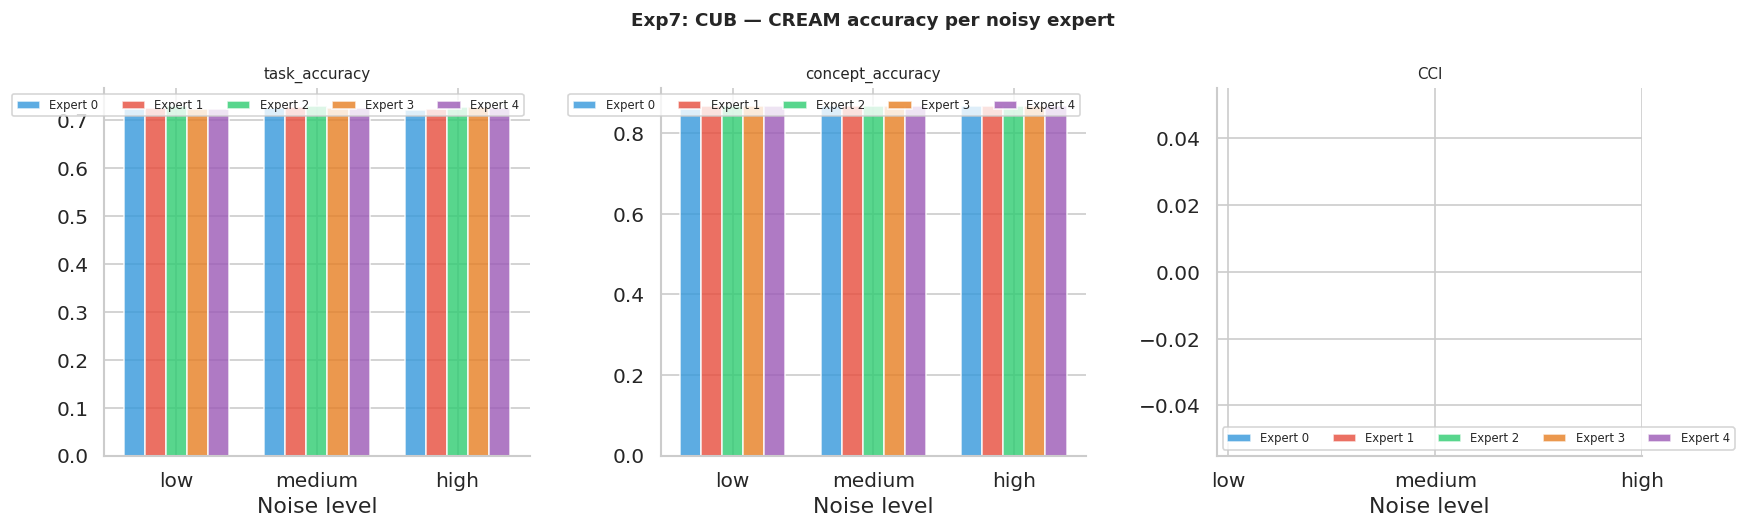


CUB â€” spread across experts (std of mean per level):
  low: expert means=[0.7268, 0.7258, 0.7297, 0.7233, 0.7237]  spread_std=0.0026
  medium: expert means=[0.7252, 0.7282, 0.729, 0.724, 0.7258]  spread_std=0.0021
  high: expert means=[0.7214, 0.7239, 0.7271, 0.7264, 0.7258]  spread_std=0.0023

=== Exp7: CelebA â€” CREAM per noisy expert ===

test_task_accuracy:


value                                            \
expert                  0             1             2             3   
noise_level                                                           
high         0.8195 Â± nan  0.8102 Â± nan  0.8022 Â± nan  0.8160 Â± nan   
low          0.8222 Â± nan  0.8256 Â± nan  0.8230 Â± nan  0.8250 Â± nan   
medium       0.8216 Â± nan  0.8230 Â± nan  0.8140 Â± nan  0.8213 Â± nan   

                           
expert                  4  
noise_level                
high         0.8068 Â± nan  
low          0.8012 Â± nan  
medium       0.8171 Â± nan


test_concept_accuracy:


value                                            \
expert                  0             1             2             3   
noise_level                                                           
high         0.8092 Â± nan  0.7972 Â± nan  0.7961 Â± nan  0.8082 Â± nan   
low          0.8018 Â± nan  0.8081 Â± nan  0.7951 Â± nan  0.8034 Â± nan   
medium       0.8006 Â± nan  0.7961 Â± nan  0.7969 Â± nan  0.8041 Â± nan   

                           
expert                  4  
noise_level                
high         0.7964 Â± nan  
low          0.8051 Â± nan  
medium       0.7980 Â± nan


CCI:


value                                            
expert               0          1          2          3          4
noise_level                                                       
high         nan Â± nan  nan Â± nan  nan Â± nan  nan Â± nan  nan Â± nan
low          nan Â± nan  nan Â± nan  nan Â± nan  nan Â± nan  nan Â± nan
medium       nan Â± nan  nan Â± nan  nan Â± nan  nan Â± nan  nan Â± nan

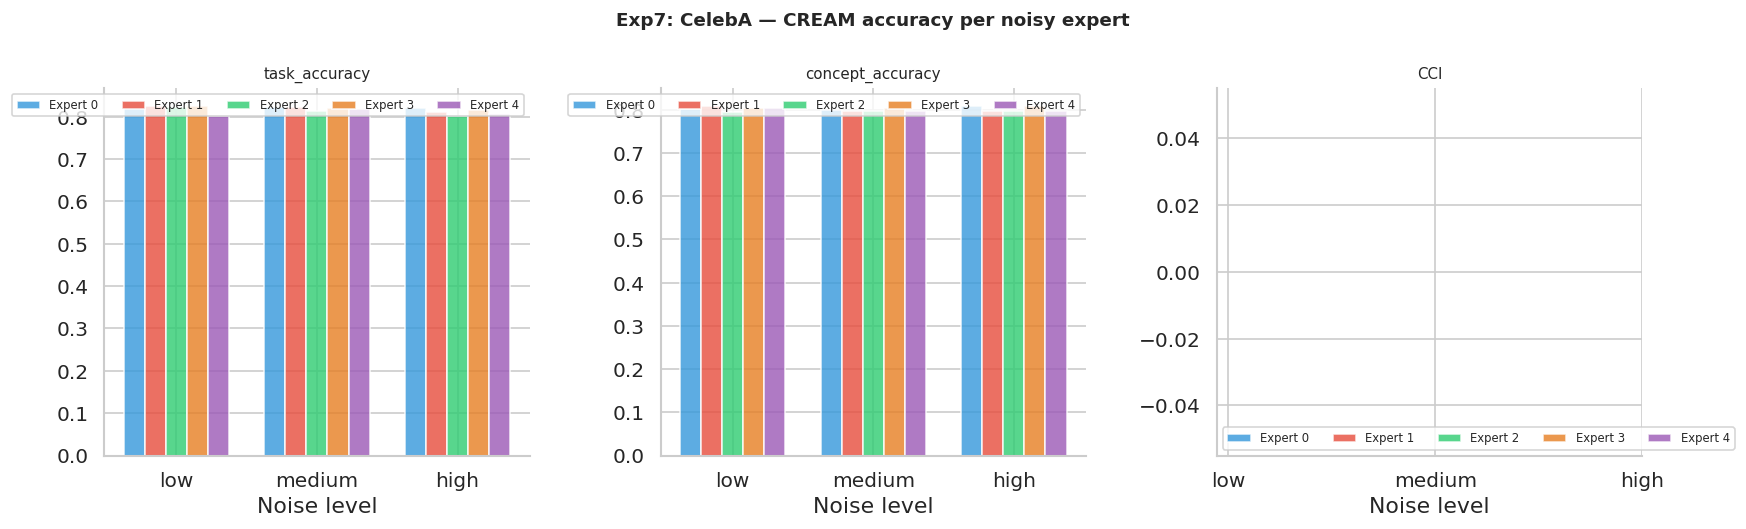


CelebA â€” spread across experts (std of mean per level):
  low: expert means=[0.8222, 0.8256, 0.823, 0.825, 0.8012]  spread_std=0.0103
  medium: expert means=[0.8216, 0.823, 0.814, 0.8213, 0.8171]  spread_std=0.0037
  high: expert means=[0.8195, 0.8102, 0.8022, 0.816, 0.8068]  spread_std=0.0069

=== Exp7: Complete_Concept_FMNIST â€” CREAM per noisy expert ===

test_task_accuracy:


value                                            \
expert                  0             1             2             3   
noise_level                                                           
high         0.9262 Â± nan  0.9247 Â± nan  0.9251 Â± nan  0.9227 Â± nan   
low          0.9250 Â± nan  0.9249 Â± nan  0.9241 Â± nan  0.9242 Â± nan   
medium       0.9244 Â± nan  0.9271 Â± nan  0.9256 Â± nan  0.9261 Â± nan   

                           
expert                  4  
noise_level                
high         0.9242 Â± nan  
low          0.9224 Â± nan  
medium       0.9239 Â± nan


test_concept_accuracy:


value                                            \
expert                  0             1             2             3   
noise_level                                                           
high         0.9817 Â± nan  0.9812 Â± nan  0.9815 Â± nan  0.9810 Â± nan   
low          0.9813 Â± nan  0.9813 Â± nan  0.9813 Â± nan  0.9816 Â± nan   
medium       0.9815 Â± nan  0.9816 Â± nan  0.9815 Â± nan  0.9819 Â± nan   

                           
expert                  4  
noise_level                
high         0.9813 Â± nan  
low          0.9807 Â± nan  
medium       0.9812 Â± nan


CCI:


value                                            \
expert                  0             1             2             3   
noise_level                                                           
high         1.0000 Â± nan  1.0000 Â± nan  1.0000 Â± nan  1.0000 Â± nan   
low          1.0000 Â± nan  1.0000 Â± nan  1.0000 Â± nan  1.0000 Â± nan   
medium       1.0000 Â± nan  1.0000 Â± nan  1.0000 Â± nan  1.0000 Â± nan   

                           
expert                  4  
noise_level                
high         1.0000 Â± nan  
low          1.0000 Â± nan  
medium       1.0000 Â± nan

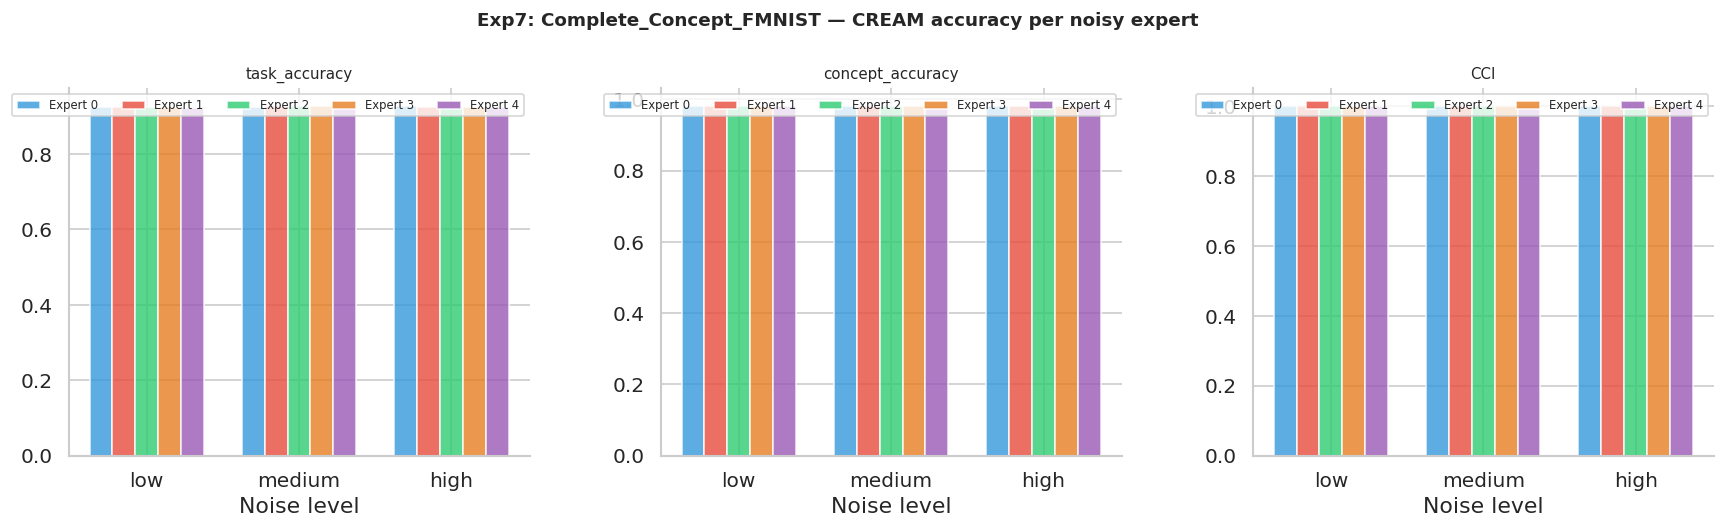


Complete_Concept_FMNIST â€” spread across experts (std of mean per level):
  low: expert means=[0.925, 0.9249, 0.9241, 0.9242, 0.9224]  spread_std=0.0010
  medium: expert means=[0.9244, 0.9271, 0.9256, 0.9261, 0.9239]  spread_std=0.0013
  high: expert means=[0.9262, 0.9247, 0.9251, 0.9227, 0.9242]  spread_std=0.0013
No intervention results for Exp7 yet.


In [4]:
if len(exp7_df) == 0:
    print('No Exp7 data yet. Submit: bash server_scripts/cream_experiment/submit_cream_noisy_expert.sh --dataset all')
else:
    KEY = ['test_task_accuracy', 'test_concept_accuracy', 'CCI', 'PFI_concept_importance', 'PFI_side_importance']
    av  = [c for c in KEY if c in exp7_df.columns]
    EXPERT_COLORS = ['#3498db','#e74c3c','#2ecc71','#e67e22','#9b59b6']

    for ds in sorted(exp7_df['dataset'].unique()):
        sub = exp7_df[exp7_df['dataset'] == ds]

        # â”€â”€ Accuracy table: mean Â± std per expert per level â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        print(f'\n=== Exp7: {ds} â€” CREAM per noisy expert ===')
        for metric in av:
            if metric not in sub.columns: continue
            tbl = sub.groupby(['noise_level','expert'])[metric].agg(['mean','std']).round(4)
            tbl['value'] = tbl['mean'].map('{:.4f}'.format) + ' Â± ' + tbl['std'].map('{:.4f}'.format)
            print(f'\n{metric}:')
            display(tbl[['value']].unstack('expert'))

        # â”€â”€ Bar chart: all 5 experts per noise level â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        fig, axes = plt.subplots(1, len(av), figsize=(5*len(av), 4.5))
        if len(av) == 1: axes = [axes]
        fig.suptitle(f'Exp7: {ds} â€” CREAM accuracy per noisy expert', fontsize=11, fontweight='bold')
        x = np.arange(len(LEVELS)); w = 0.15
        for ax, metric in zip(axes, av):
            for ei in range(5):
                means, stds = [], []
                for level in LEVELS:
                    g = sub[(sub['expert']==ei) & (sub['noise_level']==level)]
                    means.append(g[metric].mean() if len(g) > 0 else np.nan)
                    stds.append(g[metric].std()   if len(g) > 0 else 0)
                ax.bar(x + (ei-2)*w, means, w, yerr=stds, capsize=3,
                       color=EXPERT_COLORS[ei], alpha=0.8, label=f'Expert {ei}')
            ax.set_title(metric.replace('test_',''), fontsize=9)
            ax.set_xticks(x); ax.set_xticklabels(LEVELS)
            ax.set_xlabel('Noise level'); ax.legend(fontsize=7, ncol=5)
        plt.tight_layout()
        plt.savefig(f'exp7_acc_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
        plt.show()

        # â”€â”€ Variance across experts (spread) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        print(f'\n{ds} â€” spread across experts (std of mean per level):')
        for level in LEVELS:
            g = sub[sub['noise_level'] == level]
            if g.empty or 'test_task_accuracy' not in g.columns: continue
            expert_means = g.groupby('expert')['test_task_accuracy'].mean()
            print(f'  {level}: expert means={expert_means.round(4).tolist()}  '
                  f'spread_std={expert_means.std():.4f}')

# â”€â”€ Intervention curves per expert per level â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
if len(exp7_interv) > 0:
    has_g = 'group_interventions' in exp7_interv.columns
    for ds in sorted(exp7_interv['dataset'].unique()):
        ds_iv = exp7_interv[exp7_interv['dataset'] == ds]
        sub_indiv = ds_iv[ds_iv['group_interventions']==False] if has_g else ds_iv

        for level in LEVELS:
            lv = sub_indiv[sub_indiv['noise_level'] == level]
            if lv.empty: continue
            fig, ax = plt.subplots(figsize=(8, 5))
            fig.suptitle(f'Exp7: {ds} / {level} â€” CREAM intervention curves per expert\n'
                         f'(each line = one expert graph)',
                         fontsize=11, fontweight='bold')
            for ei in range(5):
                ev = lv[lv['expert'] == ei]
                if ev.empty: continue
                agg = ev.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                ax.plot(agg['num_interventions'], agg['mean'],
                        color=EXPERT_COLORS[ei], lw=2, marker='o', markersize=4,
                        label=f'Expert {ei}')
                ax.fill_between(agg['num_interventions'], agg['mean']-agg['std'], agg['mean']+agg['std'],
                                alpha=0.1, color=EXPERT_COLORS[ei])
            ax.set_xlabel('Concepts intervened'); ax.set_ylabel('Task Accuracy')
            ax.legend(fontsize=9); ax.tick_params(labelsize=8)
            plt.tight_layout()
            plt.savefig(f'exp7_interv_{ds.replace(" ","_")}_{level}.png', dpi=150, bbox_inches='tight')
            plt.show()
else:
    print('No intervention results for Exp7 yet.')